debug code

In [1]:
import torch
# from torch import nn
# from PIL import Image
# from torchvision.models.detection.ssd import SSD300_VGG16_Weights
# from torchvision.models.detection.faster_rcnn import FasterRCNN_ResNet50_FPN_V2_Weights, FasterRCNN_ResNet50_FPN_Weights

from pathlib import Path

# import shutil
import numpy as np
import matplotlib.lines as mlines
import cv2
import pandas as pd
import matplotlib.pyplot as plt
# from scipy.optimize import linear_sum_assignment
# from sklearn import metrics
import matplotlib.patches as patches
# from copy import deepcopy
import skimage
# from skimage.io import imread
import scipy
# import basicpy
from tqdm import tqdm
import geopandas as gpd
# import torchmetrics
# import torchmetrics.detection

# # import models.image_datamodule
# # import models.embeddings_datamodule
from samos.util.box_ops_numpy import mask_to_boxes, cxcywh_to_xyxy, xyxy_to_cxcywh, plot_boxes
from samos.util import dataloading as dl
# from samos.util import postprocessing as pp
# # # from util.cellsam import CellSAM
# # from util.umamba import Umamba
# # # from SSD_model import SSD
# # # from util.samos import SAMOS
# # # from util.ssd import SSDPredictor
# # # from util.FasterRCNN import FasterRCNNPredictor
# # # from util.cellpose import Cellpose
# # from util.orgasegment import PredictorFromMasks
# # from util.gt_sam import GroundTruthSAM
from samos.util.pred_with_sam import PredictionSAM

%load_ext autoreload
%autoreload 2

## Copy checkpoints

In [ ]:
# checkpoint_path = list(Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained_miccai/DETR_own_implementation_SAM_large_MultiOrg_train_normal_MultiOrg_train_macros_OrgaSegment_train_Tellu_train_OrgaQuant_train_detr_own_sam1_small_head_finetuning_long_True_16_400_2026').glob('DETR_own_implementation_SAM_large_MultiOrg_train_normal_MultiOrg_train_macros_OrgaSegment_train_Tellu_train_OrgaQuant_train_detr_own_sam1_small_head_finetuning_long_True_16_400_2026-last.ckpt'))[0]
# print(checkpoint_path)

# new_checkpoint_path = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained_miccai/DETR_own_implementation_SAM_large_MultiOrg_train_normal_MultiOrg_train_macros_OrgaSegment_train_Tellu_train_OrgaQuant_train_detr_own_sam1_small_head_finetuning_long_version_2_True_16_400_2026/DETR_own_implementation_SAM_large_MultiOrg_train_normal_MultiOrg_train_macros_OrgaSegment_train_Tellu_train_OrgaQuant_train_detr_own_sam1_small_head_finetuning_long_version_2_True_16_400_2026-last.ckpt')
# print(new_checkpoint_path)
# # new_checkpoint_path.parent.mkdir()
# # shutil.copy(checkpoint_path, new_checkpoint_path)

/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained_miccai/DETR_own_implementation_SAM_large_MultiOrg_train_normal_MultiOrg_train_macros_OrgaSegment_train_Tellu_train_OrgaQuant_train_detr_own_sam1_small_head_finetuning_long_True_16_400_2026/DETR_own_implementation_SAM_large_MultiOrg_train_normal_MultiOrg_train_macros_OrgaSegment_train_Tellu_train_OrgaQuant_train_detr_own_sam1_small_head_finetuning_long_True_16_400_2026-last.ckpt
/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained_miccai/DETR_own_implementation_SAM_large_MultiOrg_train_normal_MultiOrg_train_macros_OrgaSegment_train_Tellu_train_OrgaQuant_train_detr_own_sam1_small_head_finetuning_long_version_2_True_16_400_2026/DETR_own_implementation_SAM_large_MultiOrg_train_normal_MultiOrg_train_macros_OrgaSegment_train_Tellu_train_OrgaQuant_train_detr_own_sam1_small_head_finetuning_long_version_2_True_16_400_2026-last.ckpt


PosixPath('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained_miccai/DETR_own_implementation_SAM_large_MultiOrg_train_normal_MultiOrg_train_macros_OrgaSegment_train_Tellu_train_OrgaQuant_train_detr_own_sam1_small_head_finetuning_long_version_2_True_16_400_2026/DETR_own_implementation_SAM_large_MultiOrg_train_normal_MultiOrg_train_macros_OrgaSegment_train_Tellu_train_OrgaQuant_train_detr_own_sam1_small_head_finetuning_long_version_2_True_16_400_2026-last.ckpt')

## Paper figures

In [47]:
base_datadir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/original_data/')
results_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results')


def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   
    
def show_box(box, ax, color='red'):
    y_min, x_min, y_max, x_max = box
    
    # Calculate width and height of the box
    width = x_max - x_min
    height = y_max - y_min

    ax.add_patch(plt.Rectangle((x_min, y_min), width, height, edgecolor=color, facecolor=(0,0,0,0), lw=2))

def show_mask(contour, ax, random_color=False):
    if random_color:
        color = np.random.random(3)
    else:
        color = np.array([30/255, 184/255, 255/255])
    edgecolor = np.concatenate([color, np.array([1.0])], axis=0)
    facecolor = np.concatenate([color, np.array([0.4])], axis=0)

    contour = gpd.GeoSeries(contour)
    contour.plot(edgecolor=edgecolor, facecolor=facecolor, ax=ax)

def visualize(im, contours, boxes, random_color=True, box_color='red', format='yxyx_px', ax=None, **fig_kwargs):
    # Format boxes
    H, W = im.shape[:2]

    if format=='cycxhw_01':
        # boxes are in cycxhw format normalized by the longest image side. Converts to min/max coordinates in pixels.
        original_boxes = cxcywh_to_xyxy(boxes) * max(H, W)
    elif format=='cycxhw_px':
        # boxes are in cycxhw format in pixels. Converts to min/max coordinates in pixels.
        original_boxes = cxcywh_to_xyxy(boxes)
    elif format=='yxyx_01':
        # boxes are in min/max coordinates normalized by the longest image side. Converts to min/max coordinates in pixels.
        original_boxes = boxes * max(H, W)
    elif format=='yxyx_px':
        # boxes are in min/max coordinates in pixels. No conversion necessary.
        original_boxes = boxes
    else:
        raise ValueError(format)

    if ax is None:
        fig, ax = plt.subplots(1, 1, **fig_kwargs)
    
    ax.imshow(im)
    ax.axis(False)
    for i in range(original_boxes.shape[0]):
        show_mask(contours[i], ax, random_color=random_color)
        show_box(original_boxes[i], ax, color=box_color)

In [3]:
results_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results_paper')
results_dir.mkdir(exist_ok=True)

In [69]:
import matplotlib as mpl

width = 6  # inches
mpl.rcParams['figure.dpi'] = 200
# mpl.rcParams['lines.linewidth'] = 2
# mpl.rcParams['lines.linestyle'] = '--'

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
# i = 10
# plot_boxes(im, gt_boxes[i:i+1], format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes_cellpose, format='yxyx_px', ax=ax, show_image=False, color='red')

# Plot mask predictions
for i in range(boxes_cellpose.shape[0]):
    show_mask(contours_cellpose[i], ax, random_color=True)

# show_mask(contours_cellpose[i], ax, random_color=True)

# Define custom line handles
line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
line_c = mlines.Line2D([], [], color='red', label='SSD', linewidth=2)

# Add legend with custom handles
plt.legend(handles=[line_a, line_c])

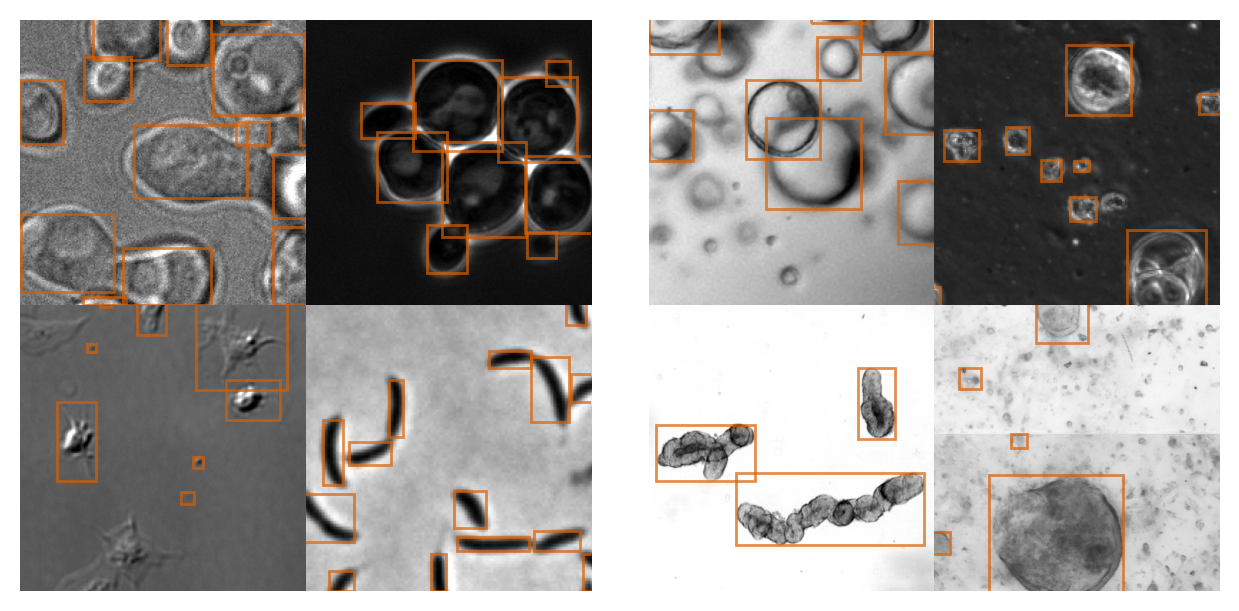

In [297]:
fig, ax = plt.subplots(2, 4, figsize=(width, 2/4.2 * width))

ds = dl.NeurIPSCellSeg('train')

im, gt_mask, gt_boxes, im_path, im_ID = ds[321]  # 300, 321, 420, 521, 527
im, flatfield = dl.normalize(im, correct_bg=False)

color = '#d95f02'

plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax[0, 0], color=color, show_image=True, linewidth=1)
ax[0, 0].set_xlim(0, 200)
ax[0, 0].set_ylim(0, 200)
ax[0, 0].axis('off')
ax[0, 0].set_position((0, 0.5, 5/21, 0.5))

im, gt_mask, gt_boxes, im_path, im_ID = ds[420]  # 300, 321, 420, 521, 527
im, flatfield = dl.normalize(im, correct_bg=False)

plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax[1, 0], color=color, show_image=True, linewidth=1)
ax[1, 0].set_xlim(250, 450)
ax[1, 0].set_ylim(220, 420)
ax[1, 0].axis('off')
ax[1, 0].set_position((0, 0, 5/21, 0.5))

im, gt_mask, gt_boxes, im_path, im_ID = ds[521]
im, flatfield = dl.normalize(im, correct_bg=False)

plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax[0, 1], color=color, show_image=True, linewidth=1)
ax[0, 1].set_xlim(450, 700)
ax[0, 1].set_ylim(20, 270)
ax[0, 1].axis('off')
ax[0, 1].set_position((5/21, 0.5, 5/21, 0.5))

im, gt_mask, gt_boxes, im_path, im_ID = ds[527]
im, flatfield = dl.normalize(im, correct_bg=False)

plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax[1, 1], color=color, show_image=True, linewidth=1)
ax[1, 1].set_xlim(50, 150)
ax[1, 1].set_ylim(0, 100)
ax[1, 1].axis('off')
ax[1, 1].set_position((5/21, 0, 5/21, 0.5))


ds = dl.OrgaQuant('test')

im, gt_mask, gt_boxes, im_path, im_ID = ds[34]
im, flatfield = dl.normalize(im, correct_bg=False)

plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax[0, 2], color=color, show_image=True, linewidth=1)
ax[0, 2].set_xlim(0, 250)
ax[0, 2].set_ylim(50, 300)
ax[0, 2].axis('off')
ax[0, 2].set_position((11/21, 0.5, 5/21, 0.5))

ds = dl.OrganoID('test_only_mouse')

im, gt_mask, gt_boxes, im_path, im_ID = ds[0]
im, flatfield = dl.normalize(im, correct_bg=False)

plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax[1, 2], color=color, show_image=True, linewidth=1)
ax[1, 2].set_xlim(700, 1700)
ax[1, 2].set_ylim(600, 1600)
ax[1, 2].axis('off')
ax[1, 2].set_position((11/21, 0, 5/21, 0.5))



ds = dl.OrganoID('test')
# ds = dl.NewData('all')

im, gt_mask, gt_boxes, im_path, im_ID = ds[0]  # 2, 5, 
im, flatfield = dl.normalize(im, correct_bg=False)

plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax[0, 3], color=color, show_image=True, linewidth=1)
ax[0, 3].set_xlim(500, 700)
ax[0, 3].set_ylim(450, 650)
ax[0, 3].axis('off')
ax[0, 3].set_position((16/21, 0.5, 5/21, 0.5))

ds = dl.MultiOrg('test_macros')

im, gt_mask, gt_boxes, im_path, im_ID = ds[5]
im, flatfield = dl.normalize(im, correct_bg=False)

plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax[1, 3], color=color, show_image=True, linewidth=1)
ax[1, 3].set_xlim(3000, 3800)
ax[1, 3].set_ylim(600, 1400)
ax[1, 3].axis('off')
ax[1, 3].set_position((16/21, 0, 5/21, 0.5))

plt.savefig(results_dir / 'distribution_shift.png', dpi=400)
plt.savefig(results_dir / 'distribution_shift.pdf', dpi=400)

## Ground truth SAM evaluations

##### copy filenames to correct locations

In [3]:
# cellpose_models = [
#     # 'cellpose_diam_[None]',
#     # 'cellpose_diam_[30]',
#     # 'cellpose_diam_[100]',
#     # 'cellpose_diam_[300]',
#     # 'cellpose_diam_[100,300]',
#     'SSD_objects_2024_sam1',
#     'SSD_objects_2025_sam1',
# ]
# for model_name in cellpose_models:
#     (results_dir / model_name).mkdir(exist_ok=True)

# for file in (results_dir).glob('*.csv'):
#     print(file)

#     # Get current model name
#     curr_model_name = None
#     for model_name in cellpose_models:
#         if file.name.startswith(model_name):
#             curr_model_name = model_name
#             break

#     # Define output file patch
#     outfile = results_dir / curr_model_name / file.name.replace(f'{curr_model_name}_', '', 1)
#     print(outfile)
#     assert not outfile.exists(), outfile
#     # shutil.move(file, outfile)


##### Evaluate SAM & SAM2 segmentation performance depending on the box noise  

/tmp/ipykernel_36656/3475335262.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend()


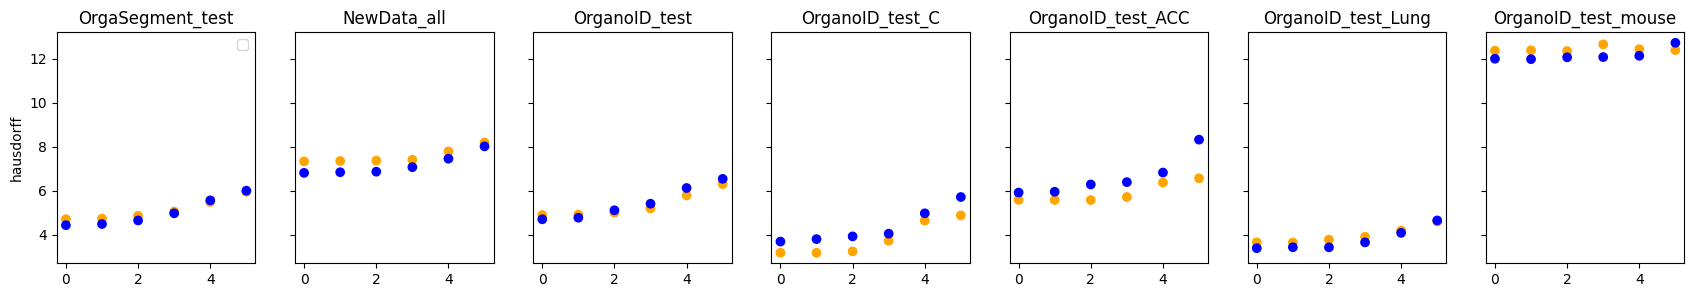

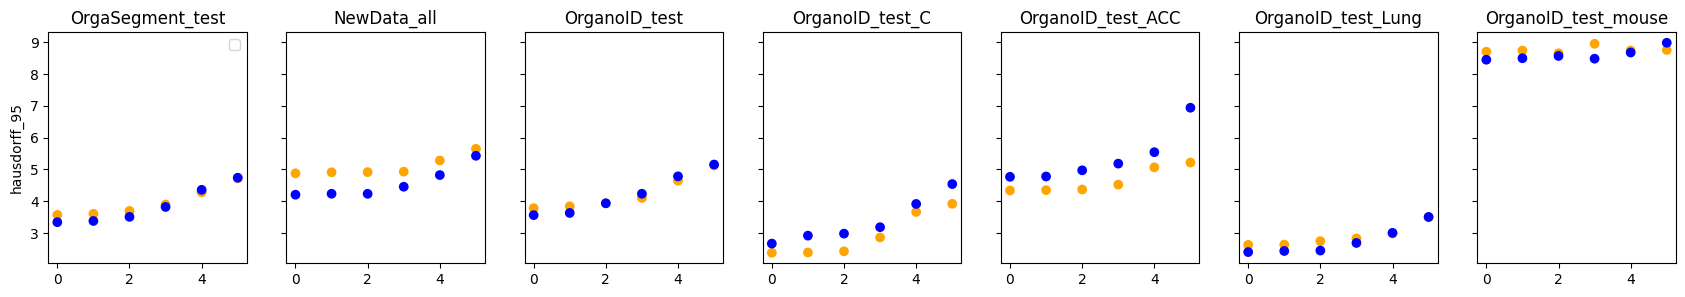

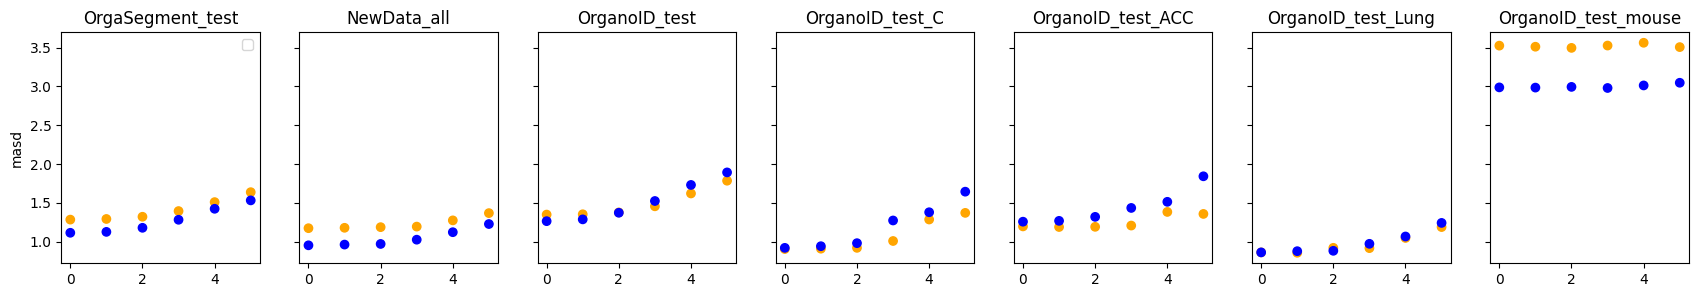

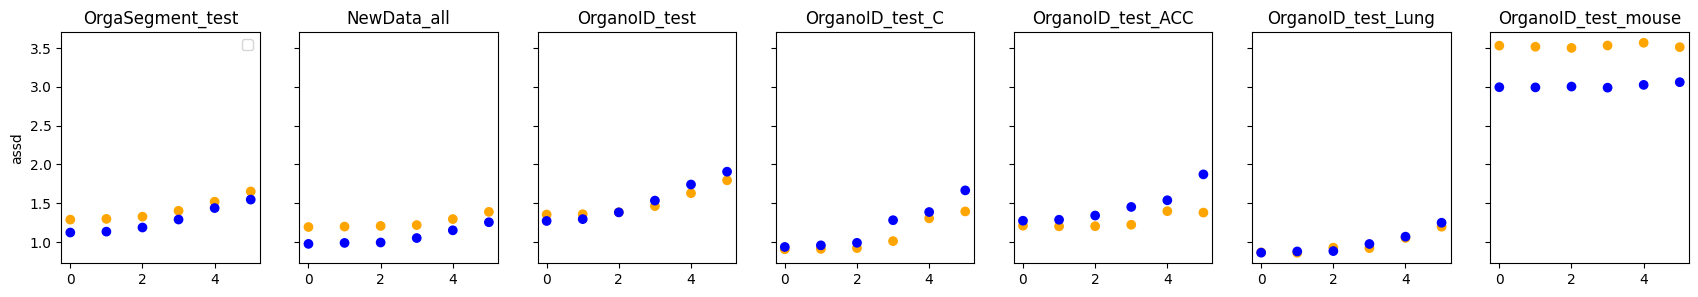

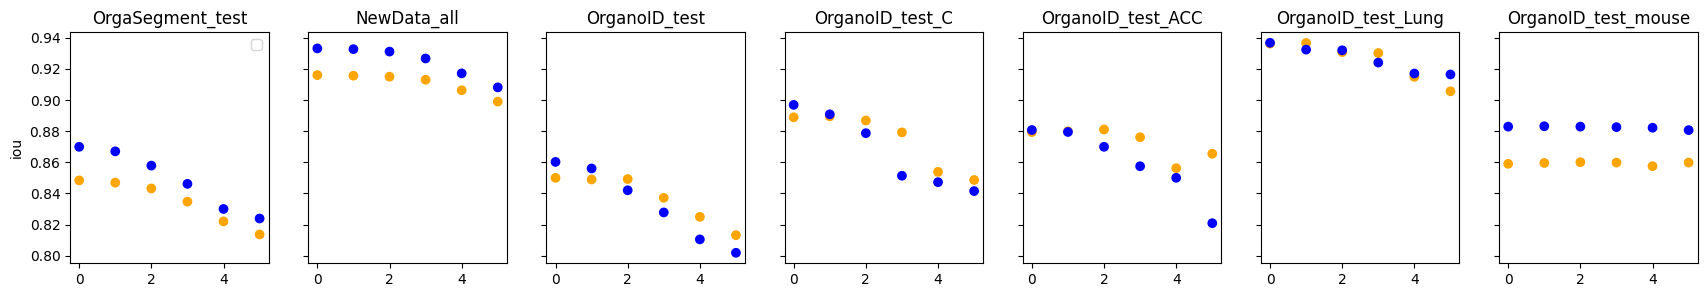

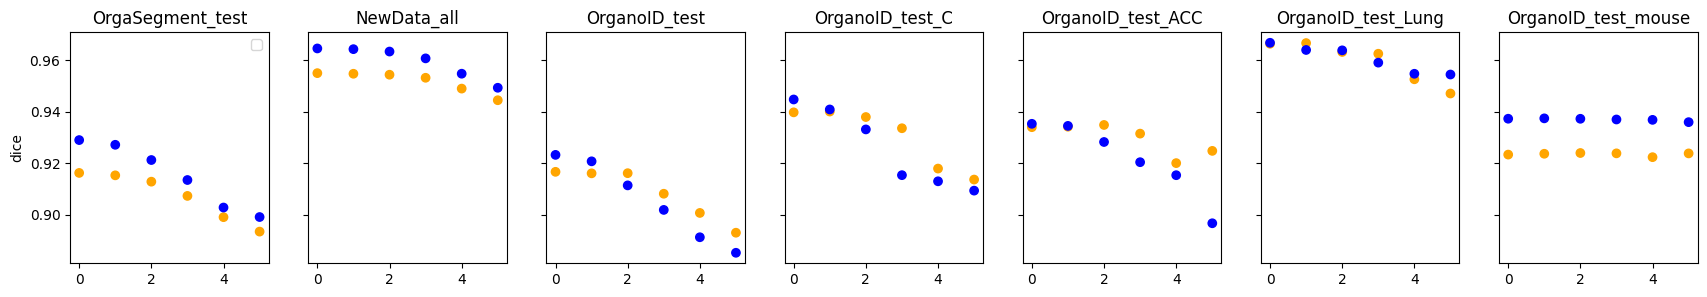

In [ ]:
# Segmentation metrics: MASD, ASSD, hausdorff, hausdorff95, IoU, dice
# sam_version = 'sam1'
iou_thres = 0.5

datasets = ["OrgaSegment_test", "NewData_all", "OrganoID_test", "OrganoID_test_C", "OrganoID_test_ACC", "OrganoID_test_Lung", "OrganoID_test_mouse"]
metrics = [
    ('hausdorff_scores', 'hausdorff'), 
    ('hausdorff_95_scores', 'hausdorff_95'), 
    ('masd_scores', 'masd'), 
    ('assd_scores', 'assd'), 
    ('iou_scores_no_thres', 'iou'), 
    ('dice_scores_no_thres', 'dice')
]


results = []
columns = ['dataset', 'sd', 'bias', 'color'] + [name for m, name in metrics]
for j, dataset in enumerate(datasets):
    # ax[0, j].set_title(dataset)
    for std in [0, 1, 2, 3, 4, 5]:
        bias = False
        for color, sam_version in zip(['orange', 'blue'], ['sam1', 'sam2']):
            metrics_df = pd.read_csv(results_dir / f'gt_{sam_version}_sd_{std}_bias_{std if bias else 0}' / f'mean_segmentation_AP_{dataset}.csv')

            data = [dataset, std, bias, color]
            for i, (metric, metric_name) in enumerate(metrics):
                v = metrics_df[metrics_df['iou_thres']==iou_thres][metric].item()
                data.append(v)
            results.append(data)

results = pd.DataFrame(data=results, columns=columns)

for _, metric_name in metrics:
    fig, ax = plt.subplots(1, len(datasets), 
                           sharey=True,
                           figsize=(3*len(datasets), 3), 
                           dpi=100)
    ax[0].set_ylabel(metric_name)

    for i, dataset in enumerate(datasets):
        df = results[results.dataset==dataset]
        ax[i].set_title(dataset)
        ax[i].scatter(df['sd'].values.flatten(), 
                      df[metric_name].values.flatten(), 
                      c=df['color'].values.flatten())

        if i==0:
            ax[i].legend()


##### Evaluate match different box noise patterns with detection metrics on different datasets  

## Zeroshot baseline evaluation

##### Compare segmentation performance of zeroshot methods + SAM with different noise levels 

(which noise level outperforms the best zeroshot method?) 

In [3]:
results_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results')

/tmp/ipykernel_4153853/4203424950.py:155: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend()


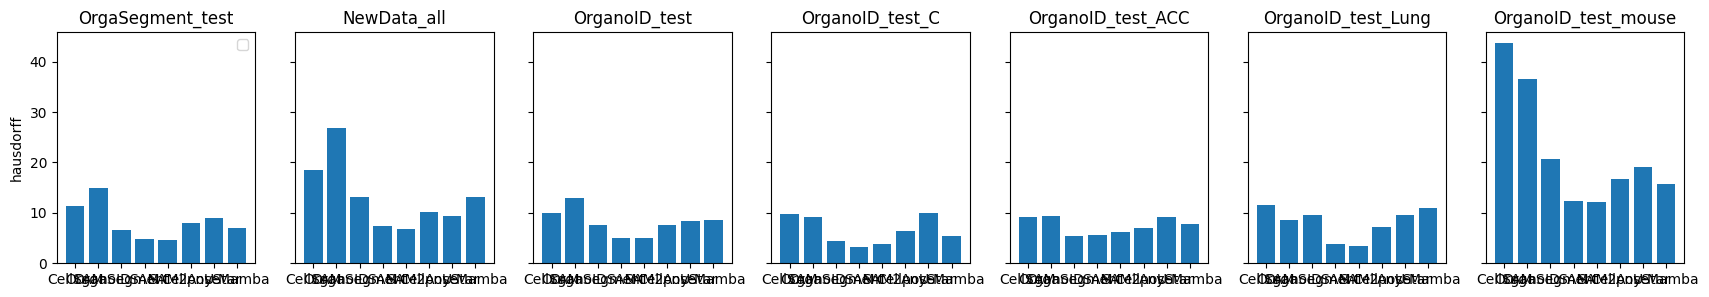

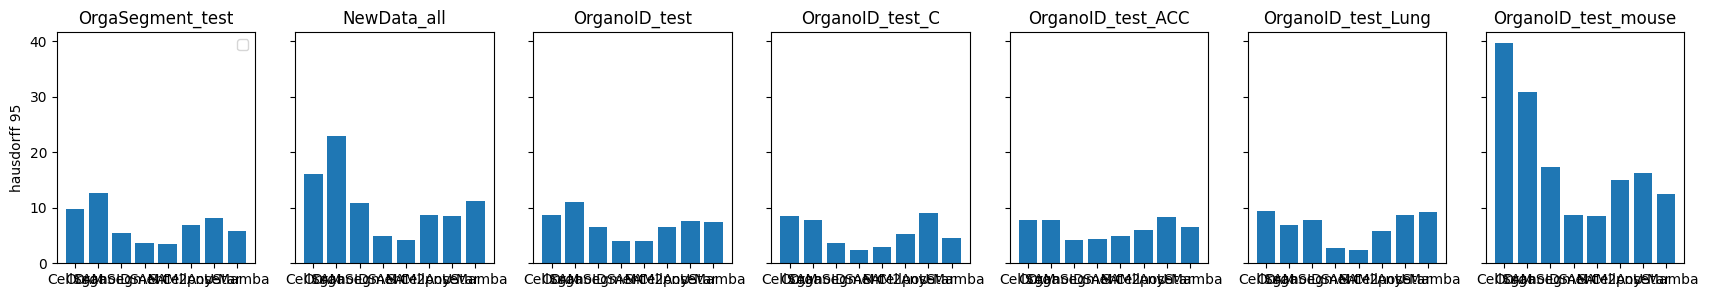

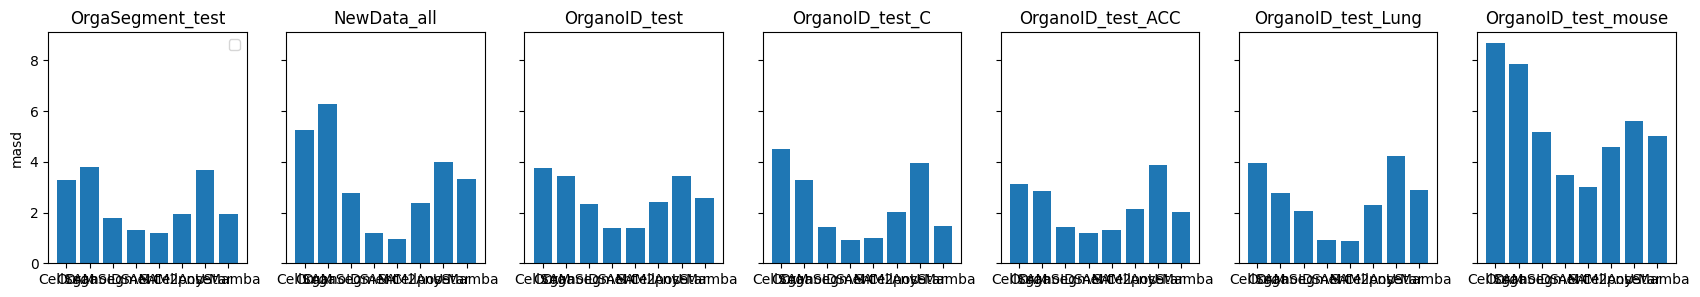

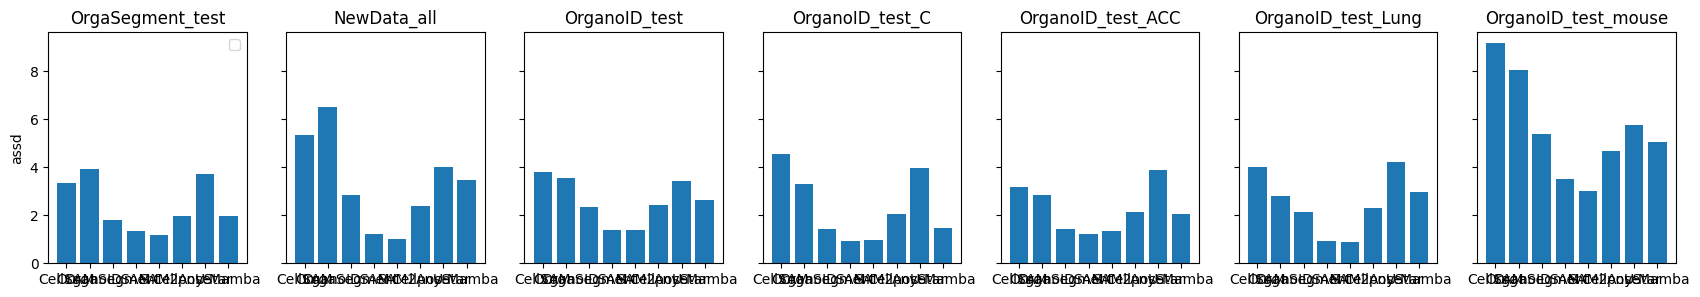

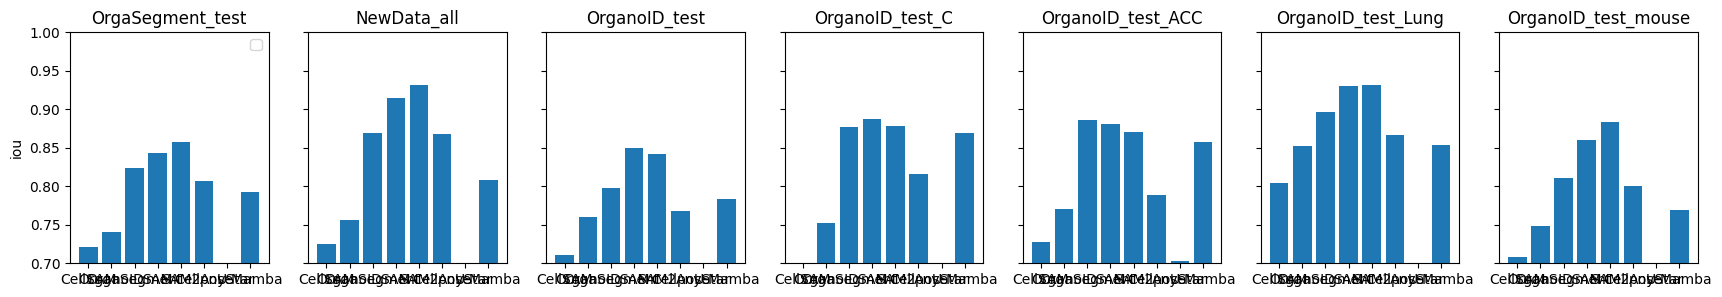

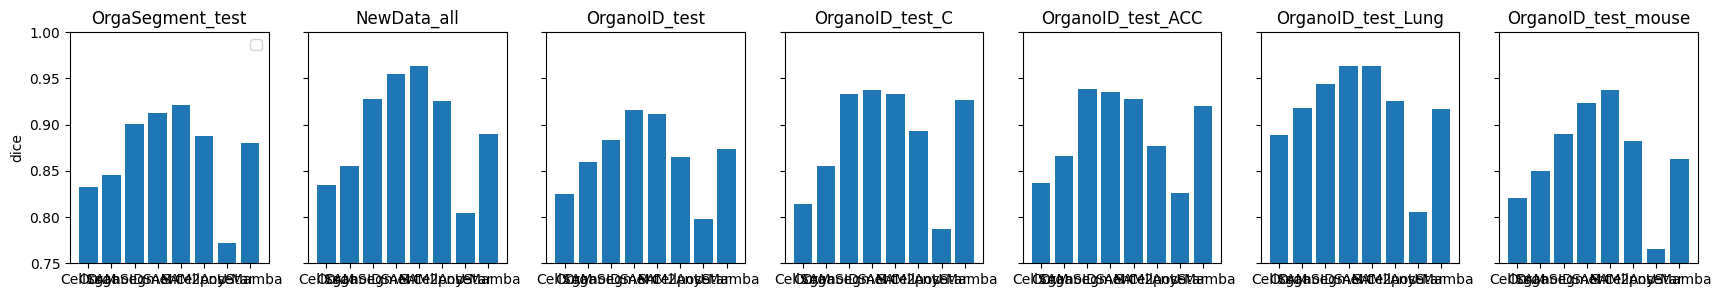

In [45]:
# Segmentation metrics: MASD, ASSD, hausdorff, hausdorff95, IoU, dice
iou_thres = 0.5


datasets = [
    "OrgaSegment_test", 
    "NewData_all", 
    "OrganoID_test", 
    "OrganoID_test_C", 
    "OrganoID_test_ACC", 
    "OrganoID_test_Lung", 
    "OrganoID_test_mouse"
]

ds2name = {
    "OrgaSegment_test": "OrgaSegment", 
    "NewData_all": "Ours", 
    "OrganoID_test": "PDAC", 
    "OrganoID_test_C": "Colon", 
    "OrganoID_test_ACC": "ACC", 
    "OrganoID_test_Lung": "Lung", 
    "OrganoID_test_mouse": "Mouse"
}


metrics = [
    ('hausdorff_scores', 'hausdorff'), 
    ('hausdorff_95_scores', 'hausdorff 95'), 
    ('masd_scores', 'masd'), 
    ('assd_scores', 'assd'), 
    ('iou_scores_no_thres', 'iou'), 
    ('dice_scores_no_thres', 'dice')
]


results = []
columns = ['dataset', 'model'] + [name for m, name in metrics]
for j, dataset in enumerate(datasets):
    # ax[0, j].set_title(dataset)
    for model in [# 'gt_sam1_sd_0_bias_0',
                #   'gt_sam2_sd_0_bias_0',
                  'AnyStar_20',
                  'AnyStar_10',
                  'AnyStar_5',
                  'AnyStar_all',
                  'cellsam',
                  'umamba_bot',
                  'umamba_enc',
                  'OrganoID',
                  'OrgaSegment',
                  'gt_sam1_sd_2_bias_0',
                  'gt_sam2_sd_2_bias_0',
                  'cellpose_diam_[None]',
                  'cellpose_diam_[30]',
                  'cellpose_diam_[100]',
                  'cellpose_diam_[300]',
                  'cellpose_diam_[100,300]',]:
        metrics_df = pd.read_csv(results_dir / model / f'mean_segmentation_AP_{dataset}.csv')

        data = [dataset, model.replace('gt_sam1_sd_2_bias_0', 'SAM').replace('gt_sam2_sd_2_bias_0', 'SAM2').replace('cellsam', 'CellSAM').replace('_', ' ').replace('[', '').replace(']', '').replace(',', ' \& ')]
        for i, (metric, metric_name) in enumerate(metrics):
            v = metrics_df[metrics_df['iou_thres']==iou_thres][metric].item()
            data.append(v)
        results.append(data)

results = pd.DataFrame(data=results, columns=columns)

# Summarize best cellpose
cellpose_df = results[results.model.apply(lambda x: x.startswith('cellpose'))]
not_cellpose_df = results[results.model.apply(lambda x: not x.startswith('cellpose'))]
# print(type(cellpose_df))

cellpose_best = cellpose_df.groupby('dataset', as_index=False).aggregate(
    hausdorff = pd.NamedAgg('hausdorff', 'min'),
    hausdorff_95 = pd.NamedAgg('hausdorff 95', 'min'),
    masd = pd.NamedAgg('masd', 'min'),
    assd = pd.NamedAgg('assd', 'min'),
    iou = pd.NamedAgg('iou', 'max'),
    dice = pd.NamedAgg('dice', 'max'),
).rename(columns={'hausdorff_95': 'hausdorff 95'})
cellpose_best['model'] = 'Cellpose'  #  (best)'

results = pd.concat([
    not_cellpose_df,
    cellpose_best,
], axis=0, ignore_index=True)



# Summarize best AnyStar
cellpose_df = results[results.model.apply(lambda x: x.startswith('AnyStar'))]
not_cellpose_df = results[results.model.apply(lambda x: not x.startswith('AnyStar'))]
# print(type(cellpose_df))

cellpose_best = cellpose_df.groupby('dataset', as_index=False).aggregate(
    hausdorff = pd.NamedAgg('hausdorff', 'min'),
    hausdorff_95 = pd.NamedAgg('hausdorff 95', 'min'),
    masd = pd.NamedAgg('masd', 'min'),
    assd = pd.NamedAgg('assd', 'min'),
    iou = pd.NamedAgg('iou', 'max'),
    dice = pd.NamedAgg('dice', 'max'),
).rename(columns={'hausdorff_95': 'hausdorff 95'})
cellpose_best['model'] = 'AnyStar'  #  (best)'

results = pd.concat([
    not_cellpose_df,
    cellpose_best,
], axis=0, ignore_index=True)




# Summarize best umamba
cellpose_df = results[results.model.apply(lambda x: x.startswith('umamba'))]
not_cellpose_df = results[results.model.apply(lambda x: not x.startswith('umamba'))]
# print(type(cellpose_df))

cellpose_best = cellpose_df.groupby('dataset', as_index=False).aggregate(
    hausdorff = pd.NamedAgg('hausdorff', 'min'),
    hausdorff_95 = pd.NamedAgg('hausdorff 95', 'min'),
    masd = pd.NamedAgg('masd', 'min'),
    assd = pd.NamedAgg('assd', 'min'),
    iou = pd.NamedAgg('iou', 'max'),
    dice = pd.NamedAgg('dice', 'max'),
).rename(columns={'hausdorff_95': 'hausdorff 95'})
cellpose_best['model'] = 'U-Mamba'  #  (best)'

results = pd.concat([
    not_cellpose_df,
    cellpose_best,
], axis=0, ignore_index=True)


for _, metric_name in metrics:
    fig, ax = plt.subplots(1, len(datasets), 
                           sharey=True,
                           figsize=(3*len(datasets), 3), 
                           dpi=100)
    ax[0].set_ylabel(metric_name)

    for i, dataset in enumerate(datasets):
        df = results[results.dataset==dataset]
        # df = df[df.model.apply(lambda x: x.startswith('cellpose'))]
        ax[i].set_title(dataset)
        ax[i].bar(df['model'].values.flatten(), 
                  df[metric_name].values.flatten(),
                #   c=df['model'].values.flatten(),
                  )
        
        if metric_name in ['iou']:
            ax[i].set_ylim(0.7, 1)
        if metric_name in ['dice']:
            ax[i].set_ylim(0.75, 1)
        if i==0:
            ax[i].legend()

In [46]:
results.replace(ds2name).pivot(
    index='model', columns='dataset', values='hausdorff'
).loc[:, ['Ours', 'OrgaSegment', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', ]].round(2)

dataset,Ours,OrgaSegment,Mouse,ACC,Colon,Lung,PDAC
model,,,,,,,
AnyStar,9.38,9.06,19.03,9.19,9.97,9.57,8.47
CellSAM,18.55,11.26,43.63,9.20,9.75,11.55,10.00
Cellpose,10.18,8.04,16.67,7.04,6.31,7.19,7.52
OrgaSegment,13.08,6.70,20.68,5.39,4.46,9.61,7.62
OrganoID,26.86,14.85,36.47,9.29,9.19,8.59,12.95
SAM,7.37,4.85,12.36,5.57,3.23,3.77,5.00
SAM2,6.86,4.64,12.07,6.28,3.91,3.42,5.10
U-Mamba,13.12,6.97,15.63,7.86,5.38,10.87,8.64


In [47]:
results.replace(ds2name).pivot(
    index='model', columns='dataset', values='iou'
).loc[:, ['Ours', 'OrgaSegment', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', ]].round(2)

dataset,Ours,OrgaSegment,Mouse,ACC,Colon,Lung,PDAC
model,,,,,,,
AnyStar,0.68,0.63,0.62,0.70,0.65,0.68,0.67
CellSAM,0.72,0.72,0.71,0.73,0.69,0.80,0.71
Cellpose,0.87,0.81,0.80,0.79,0.82,0.87,0.77
OrgaSegment,0.87,0.82,0.81,0.89,0.88,0.90,0.80
OrganoID,0.76,0.74,0.75,0.77,0.75,0.85,0.76
SAM,0.92,0.84,0.86,0.88,0.89,0.93,0.85
SAM2,0.93,0.86,0.88,0.87,0.88,0.93,0.84
U-Mamba,0.81,0.79,0.77,0.86,0.87,0.85,0.78


In [48]:
print(results.replace(ds2name).pivot(
    index='model', columns='dataset', values='hausdorff'
).loc[:, ['Ours', 'OrgaSegment', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', ]].to_latex(float_format="%.2f"))
# results.set_index(['dataset', 'model']).sort_index()

\begin{tabular}{lrrrrrrr}
\toprule
dataset & Ours & OrgaSegment & Mouse & ACC & Colon & Lung & PDAC \\
model &  &  &  &  &  &  &  \\
\midrule
AnyStar & 9.38 & 9.06 & 19.03 & 9.19 & 9.97 & 9.57 & 8.47 \\
CellSAM & 18.55 & 11.26 & 43.63 & 9.20 & 9.75 & 11.55 & 10.00 \\
Cellpose & 10.18 & 8.04 & 16.67 & 7.04 & 6.31 & 7.19 & 7.52 \\
OrgaSegment & 13.08 & 6.70 & 20.68 & 5.39 & 4.46 & 9.61 & 7.62 \\
OrganoID & 26.86 & 14.85 & 36.47 & 9.29 & 9.19 & 8.59 & 12.95 \\
SAM & 7.37 & 4.85 & 12.36 & 5.57 & 3.23 & 3.77 & 5.00 \\
SAM2 & 6.86 & 4.64 & 12.07 & 6.28 & 3.91 & 3.42 & 5.10 \\
U-Mamba & 13.12 & 6.97 & 15.63 & 7.86 & 5.38 & 10.87 & 8.64 \\
\bottomrule
\end{tabular}



In [49]:
print(results.replace(ds2name).pivot(
    index='model', columns='dataset', values='masd'
).loc[:, ['Ours', 'OrgaSegment', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', ]].round(2).to_latex(float_format="%.2f"))
# results.set_index(['dataset', 'model']).sort_index()

\begin{tabular}{lrrrrrrr}
\toprule
dataset & Ours & OrgaSegment & Mouse & ACC & Colon & Lung & PDAC \\
model &  &  &  &  &  &  &  \\
\midrule
AnyStar & 4.00 & 3.66 & 5.60 & 3.87 & 3.94 & 4.21 & 3.43 \\
CellSAM & 5.26 & 3.27 & 8.68 & 3.14 & 4.51 & 3.97 & 3.76 \\
Cellpose & 2.36 & 1.93 & 4.59 & 2.12 & 2.02 & 2.29 & 2.42 \\
OrgaSegment & 2.78 & 1.80 & 5.19 & 1.43 & 1.44 & 2.07 & 2.33 \\
OrganoID & 6.30 & 3.81 & 7.86 & 2.83 & 3.28 & 2.79 & 3.46 \\
SAM & 1.19 & 1.32 & 3.50 & 1.19 & 0.92 & 0.92 & 1.38 \\
SAM2 & 0.97 & 1.18 & 2.99 & 1.32 & 0.98 & 0.88 & 1.37 \\
U-Mamba & 3.31 & 1.95 & 5.04 & 2.04 & 1.45 & 2.91 & 2.58 \\
\bottomrule
\end{tabular}



In [50]:
print(results.replace(ds2name).pivot(
    index='model', columns='dataset', values='iou'
).loc[:, ['Ours', 'OrgaSegment', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', ]].round(2).to_latex(float_format="%.2f"))

\begin{tabular}{lrrrrrrr}
\toprule
dataset & Ours & OrgaSegment & Mouse & ACC & Colon & Lung & PDAC \\
model &  &  &  &  &  &  &  \\
\midrule
AnyStar & 0.68 & 0.63 & 0.62 & 0.70 & 0.65 & 0.68 & 0.67 \\
CellSAM & 0.72 & 0.72 & 0.71 & 0.73 & 0.69 & 0.80 & 0.71 \\
Cellpose & 0.87 & 0.81 & 0.80 & 0.79 & 0.82 & 0.87 & 0.77 \\
OrgaSegment & 0.87 & 0.82 & 0.81 & 0.89 & 0.88 & 0.90 & 0.80 \\
OrganoID & 0.76 & 0.74 & 0.75 & 0.77 & 0.75 & 0.85 & 0.76 \\
SAM & 0.92 & 0.84 & 0.86 & 0.88 & 0.89 & 0.93 & 0.85 \\
SAM2 & 0.93 & 0.86 & 0.88 & 0.87 & 0.88 & 0.93 & 0.84 \\
U-Mamba & 0.81 & 0.79 & 0.77 & 0.86 & 0.87 & 0.85 & 0.78 \\
\bottomrule
\end{tabular}



##### Compare detection performance of zeroshot methods

gt_sam1_sd_2_bias_0 8
AnyStar_20 8
AnyStar_10 10
AnyStar_5 10
AnyStar_all 10
cellsam 8
umamba_bot 10
umamba_enc 8
OrganoID 10
OrgaSegment 8
cellpose_diam_[None] 8
cellpose_diam_[30] 8
cellpose_diam_[100] 8
cellpose_diam_[300] 8
cellpose_diam_[100,300] 8
gt_sam1_sd_2_bias_0 8
AnyStar_20 8
AnyStar_10 10
AnyStar_5 10
AnyStar_all 10
cellsam 8
umamba_bot 10
umamba_enc 8
OrganoID 10
OrgaSegment 8
cellpose_diam_[None] 8
cellpose_diam_[30] 8
cellpose_diam_[100] 8
cellpose_diam_[300] 8
cellpose_diam_[100,300] 8
gt_sam1_sd_2_bias_0 8
AnyStar_20 8
AnyStar_10 10
AnyStar_5 10
AnyStar_all 10
cellsam 8
umamba_bot 10
umamba_enc 8
OrganoID 8
OrgaSegment 8
cellpose_diam_[None] 8
cellpose_diam_[30] 8
cellpose_diam_[100] 8
cellpose_diam_[300] 8
cellpose_diam_[100,300] 8
gt_sam1_sd_2_bias_0 8
AnyStar_20 8
AnyStar_10 10
AnyStar_5 10
AnyStar_all 10
cellsam 8
umamba_bot 10
umamba_enc 8
OrganoID 8
OrgaSegment 8
cellpose_diam_[None] 8
cellpose_diam_[30] 8
cellpose_diam_[100] 8
cellpose_diam_[300] 8
cellpose_dia

/tmp/ipykernel_4153853/377936605.py:228: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend()


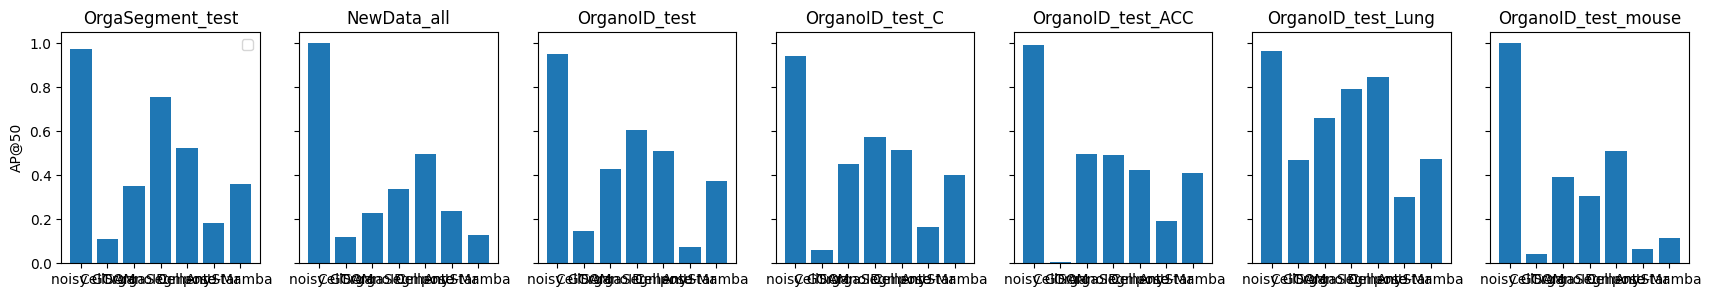

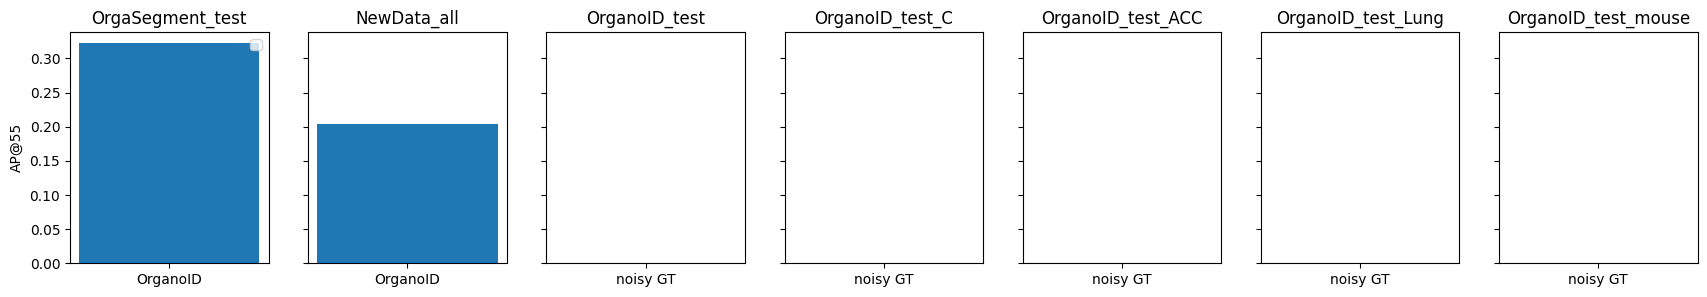

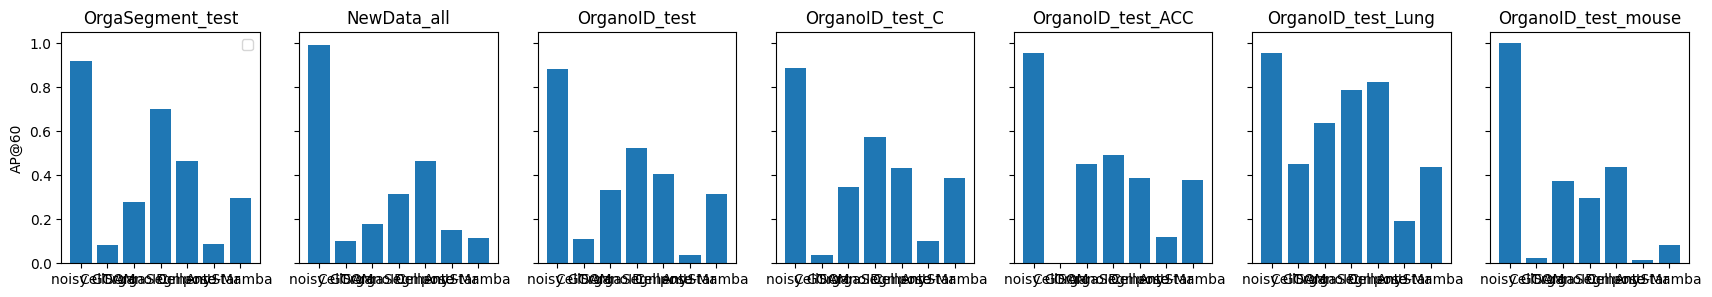

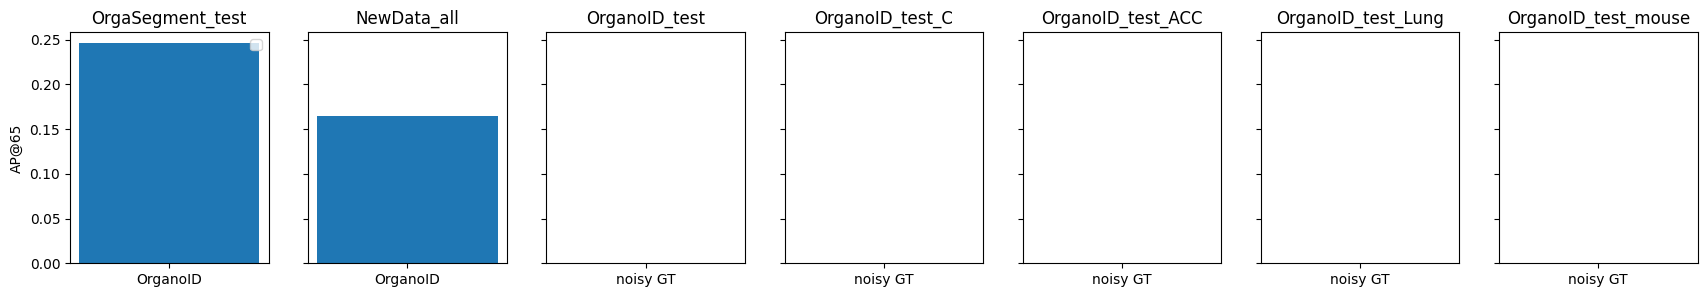

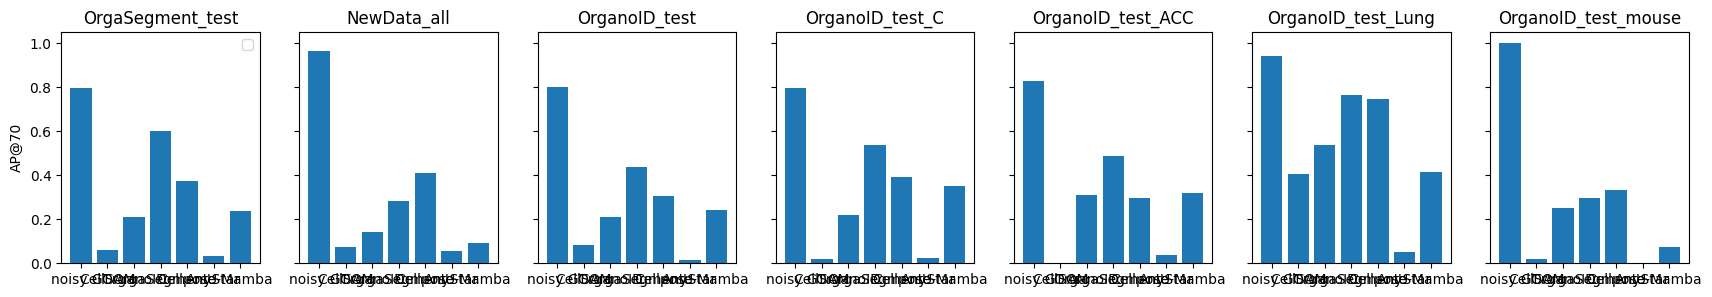

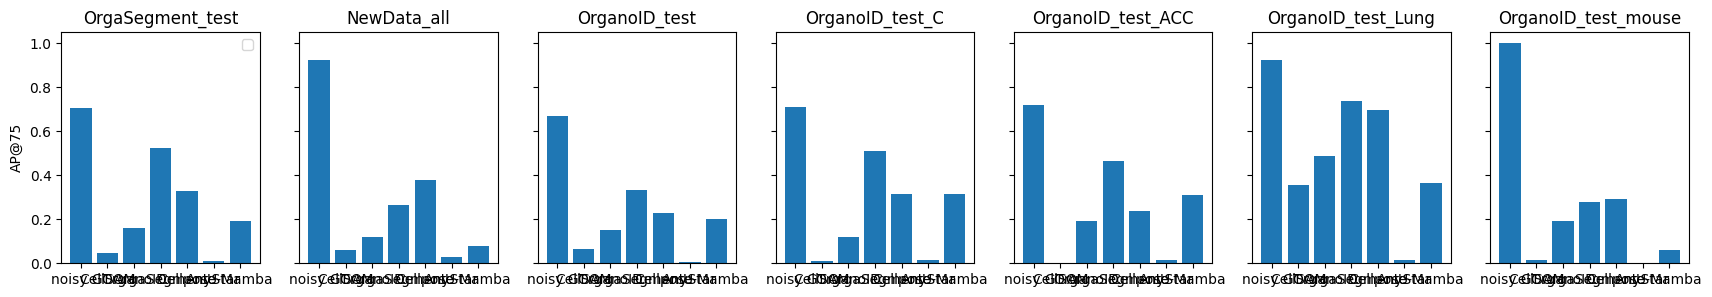

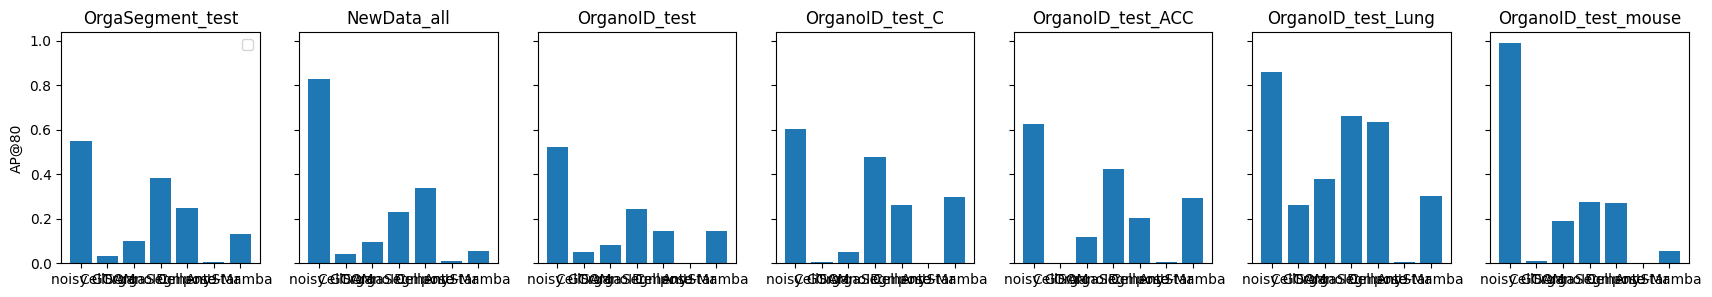

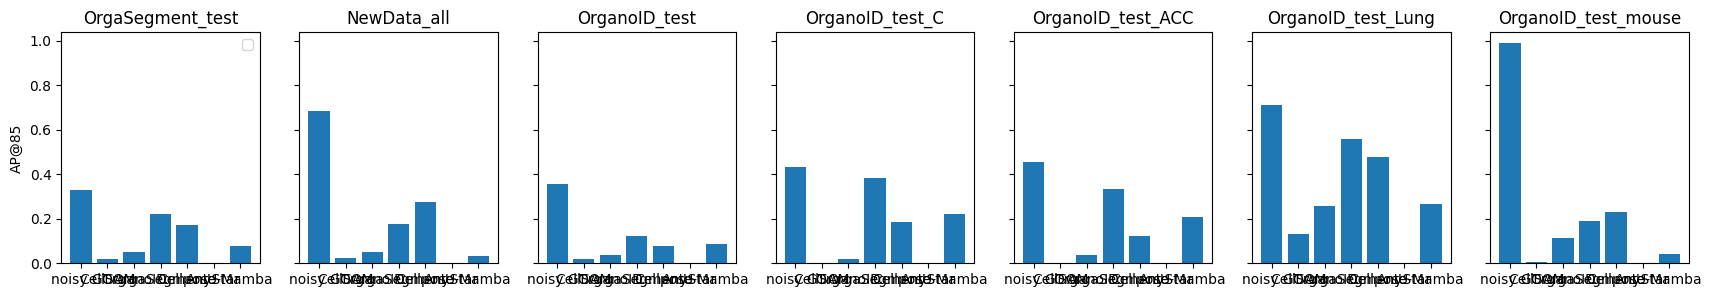

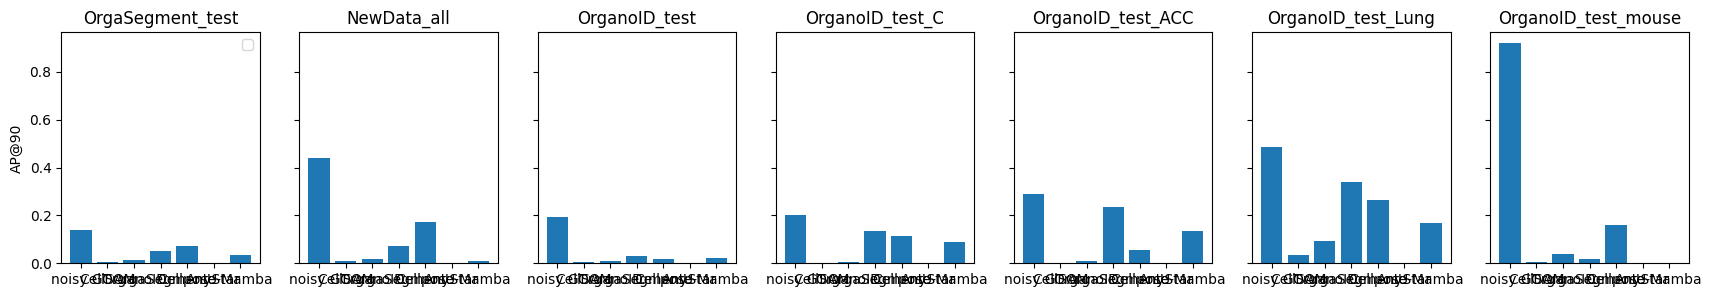

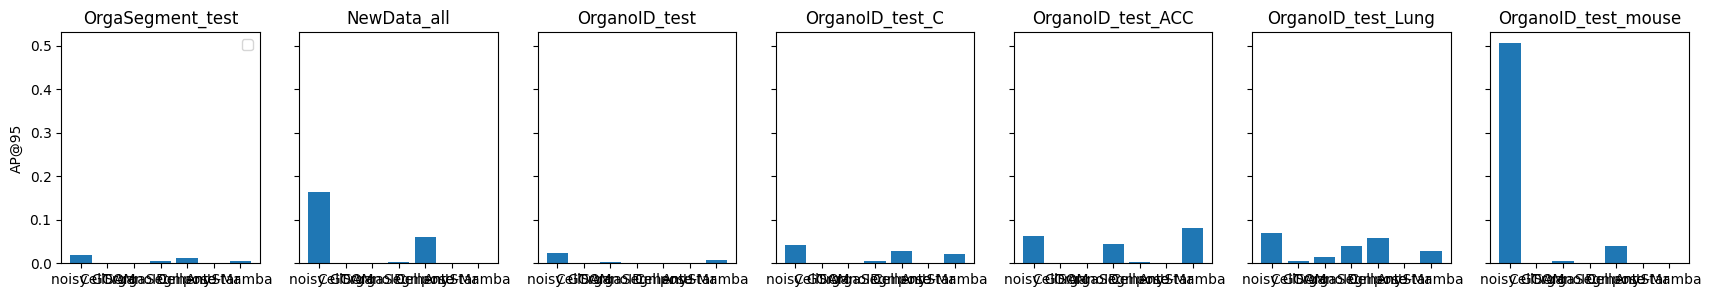

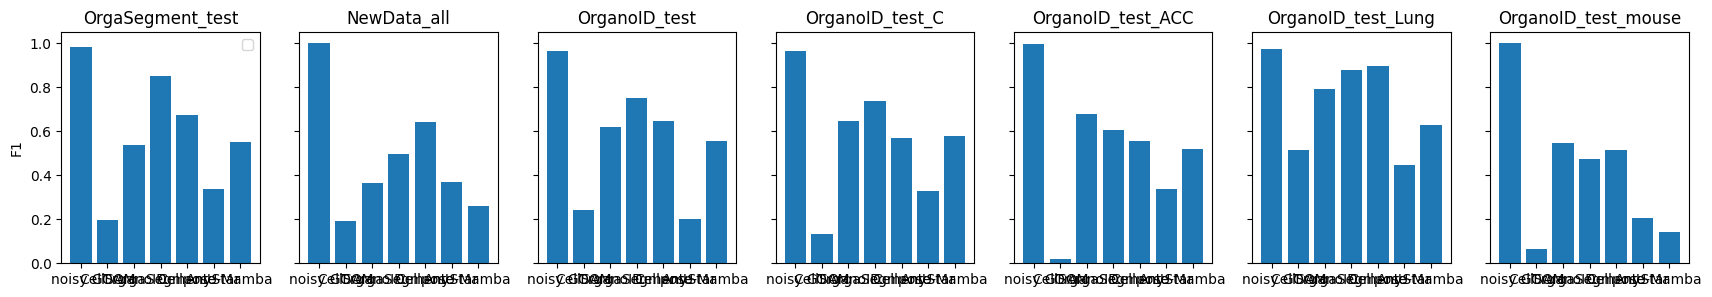

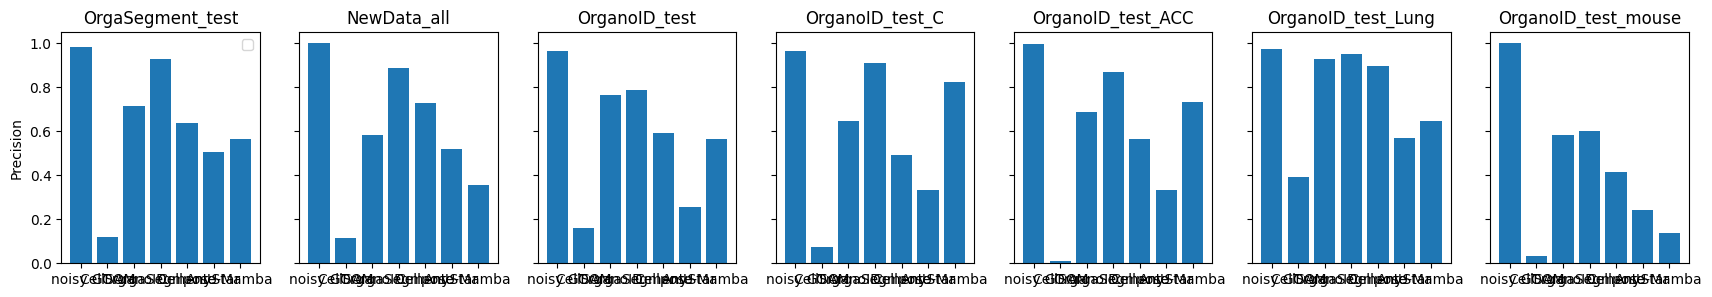

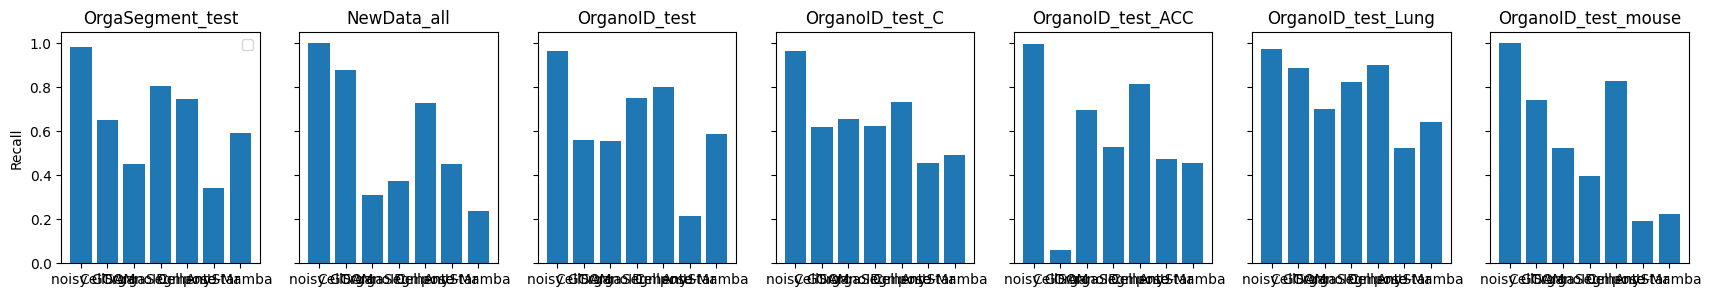

In [38]:
# Segmentation metrics: MASD, ASSD, hausdorff, hausdorff95, IoU, dice
iou_thres = 0.5

datasets = [
    "OrgaSegment_test", 
    "NewData_all", 
    "OrganoID_test", 
    "OrganoID_test_C", 
    "OrganoID_test_ACC", 
    "OrganoID_test_Lung", 
    "OrganoID_test_mouse"
]

ds2name = {
    "OrgaSegment_test": "OrgaSegment", 
    "NewData_all": "Ours", 
    "OrganoID_test": "PDAC", 
    "OrganoID_test_C": "Colon", 
    "OrganoID_test_ACC": "ACC", 
    "OrganoID_test_Lung": "Lung", 
    "OrganoID_test_mouse": "Mouse"
}

metrics = [
    'AP@50',
    'AP@55',
    'AP@60',
    'AP@65',
    'AP@70',
    'AP@75', 
    'AP@80',
    'AP@85', 
    'AP@90',
    'AP@95', 
]


results = []
columns = ['dataset', 'model'] + [name for name in metrics] + ['F1', 'Precision', 'Recall']
for j, dataset in enumerate(datasets):
    # ax[0, j].set_title(dataset)
    for model in ['gt_sam1_sd_2_bias_0',
                  # 'gt_sam2_sd_2_bias_0',
                  'AnyStar_20',
                  'AnyStar_10',
                  'AnyStar_5',
                  'AnyStar_all',
                  'cellsam',
                  'umamba_bot',
                  'umamba_enc',
                  'OrganoID',
                  'OrgaSegment',
                  'cellpose_diam_[None]',
                  'cellpose_diam_[30]',
                  'cellpose_diam_[100]',
                  'cellpose_diam_[300]',
                  'cellpose_diam_[100,300]',
                  ]:
        if (results_dir / model / f'mean_detection_AP_{dataset}.csv').exists():
            metrics_df = pd.read_csv(results_dir / model / f'mean_detection_AP_{dataset}.csv')
            print(model, len(metrics_df))

            data = [dataset, model.replace('gt_sam1_sd_2_bias_0', 'noisy GT').replace('cellsam', 'CellSAM').replace('_', ' ').replace('[', '').replace(']', '').replace(',', ' \& ')]
            for i, metric_name in enumerate(metrics):
                if len(metrics_df) < 10:
                    if i in [1, 3]:
                        data.append(np.nan)
                    elif i == 0:
                        v = metrics_df.iloc[0].item()
                        data.append(v)
                    elif i == 2:
                        v = metrics_df.iloc[1].item()
                        data.append(v)
                    elif i > 3:
                        v = metrics_df.iloc[i-2].item()
                        data.append(v)
                    else:
                        raise RuntimeError(i)
                else:
                    v = metrics_df.iloc[i].item()
                    data.append(v)
                # print(v)
                
            metrics_df = pd.read_csv(results_dir / model / f'mean_detection_metrics_{dataset}.csv')
            metrics_df = metrics_df.max()
            data.extend([metrics_df['f1'], metrics_df['precision'], metrics_df['recall']])
            results.append(data)

results = pd.DataFrame(data=results, columns=columns)


# Summarize best cellpose
cellpose_df = results[results.model.apply(lambda x: x.startswith('cellpose'))]
not_cellpose_df = results[results.model.apply(lambda x: not x.startswith('cellpose'))]
# print(type(cellpose_df))

cellpose_best = cellpose_df.groupby('dataset', as_index=False).aggregate(
    AP_50 = pd.NamedAgg('AP@50', 'max'),
    AP_60 = pd.NamedAgg('AP@60', 'max'),
    AP_70 = pd.NamedAgg('AP@70', 'max'),
    AP_75 = pd.NamedAgg('AP@75', 'max'),
    AP_80 = pd.NamedAgg('AP@80', 'max'),
    AP_85 = pd.NamedAgg('AP@85', 'max'),
    AP_90 = pd.NamedAgg('AP@90', 'max'),
    AP_95 = pd.NamedAgg('AP@95', 'max'),
    F1 = pd.NamedAgg('F1', 'max'),
    Precision = pd.NamedAgg('Precision', 'max'),
    Recall = pd.NamedAgg('Recall', 'max'),
).rename(columns={
    'AP_50': 'AP@50',
    'AP_60': 'AP@60',
    'AP_70': 'AP@70',
    'AP_75': 'AP@75',
    'AP_80': 'AP@80',
    'AP_85': 'AP@85',
    'AP_90': 'AP@90',
    'AP_95': 'AP@95',
})
cellpose_best['model'] = 'Cellpose'  #  (best)'

results = pd.concat([
    not_cellpose_df,
    cellpose_best,
], axis=0, ignore_index=True)







# Summarize best Anystar
cellpose_df = results[results.model.apply(lambda x: x.startswith('AnyStar'))]
not_cellpose_df = results[results.model.apply(lambda x: not x.startswith('AnyStar'))]
# print(type(cellpose_df))

cellpose_best = cellpose_df.groupby('dataset', as_index=False).aggregate(
    AP_50 = pd.NamedAgg('AP@50', 'max'),
    AP_60 = pd.NamedAgg('AP@60', 'max'),
    AP_70 = pd.NamedAgg('AP@70', 'max'),
    AP_75 = pd.NamedAgg('AP@75', 'max'),
    AP_80 = pd.NamedAgg('AP@80', 'max'),
    AP_85 = pd.NamedAgg('AP@85', 'max'),
    AP_90 = pd.NamedAgg('AP@90', 'max'),
    AP_95 = pd.NamedAgg('AP@95', 'max'),
    F1 = pd.NamedAgg('F1', 'max'),
    Precision = pd.NamedAgg('Precision', 'max'),
    Recall = pd.NamedAgg('Recall', 'max'),
).rename(columns={
    'AP_50': 'AP@50',
    'AP_60': 'AP@60',
    'AP_70': 'AP@70',
    'AP_75': 'AP@75',
    'AP_80': 'AP@80',
    'AP_85': 'AP@85',
    'AP_90': 'AP@90',
    'AP_95': 'AP@95',
})
cellpose_best['model'] = 'AnyStar'  #  (best)'

results = pd.concat([
    not_cellpose_df,
    cellpose_best,
], axis=0, ignore_index=True)




# Summarize best Umamba
cellpose_df = results[results.model.apply(lambda x: x.startswith('umamba'))]
not_cellpose_df = results[results.model.apply(lambda x: not x.startswith('umamba'))]
# print(type(cellpose_df))

cellpose_best = cellpose_df.groupby('dataset', as_index=False).aggregate(
    AP_50 = pd.NamedAgg('AP@50', 'max'),
    AP_60 = pd.NamedAgg('AP@60', 'max'),
    AP_70 = pd.NamedAgg('AP@70', 'max'),
    AP_75 = pd.NamedAgg('AP@75', 'max'),
    AP_80 = pd.NamedAgg('AP@80', 'max'),
    AP_85 = pd.NamedAgg('AP@85', 'max'),
    AP_90 = pd.NamedAgg('AP@90', 'max'),
    AP_95 = pd.NamedAgg('AP@95', 'max'),
    F1 = pd.NamedAgg('F1', 'max'),
    Precision = pd.NamedAgg('Precision', 'max'),
    Recall = pd.NamedAgg('Recall', 'max'),
).rename(columns={
    'AP_50': 'AP@50',
    'AP_60': 'AP@60',
    'AP_70': 'AP@70',
    'AP_75': 'AP@75',
    'AP_80': 'AP@80',
    'AP_85': 'AP@85',
    'AP_90': 'AP@90',
    'AP_95': 'AP@95',
})
cellpose_best['model'] = 'U-Mamba'  #  (best)'

results = pd.concat([
    not_cellpose_df,
    cellpose_best,
], axis=0, ignore_index=True)







for metric_name in metrics + ['F1', 'Precision', 'Recall']:
    fig, ax = plt.subplots(1, len(datasets), 
                           sharey=True,
                           figsize=(3*len(datasets), 3), 
                           dpi=100)
    ax[0].set_ylabel(metric_name)

    for i, dataset in enumerate(datasets):
        df = results[results.dataset==dataset]
        # df = df[df.model.apply(lambda x: x.startswith('cellpose'))]
        ax[i].set_title(dataset)
        ax[i].bar(df['model'].values.flatten(), 
                      df[metric_name].values.flatten())
        
        if metric_name in ['iou']:
            ax[i].set_ylim(0.7, 1)
        if metric_name in ['dice']:
            ax[i].set_ylim(0.75, 1)
        if i==0:
            ax[i].legend()


In [39]:
results.replace(ds2name).pivot(
    index='model', columns='dataset', values='AP@50'
).loc[:, ['Ours', 'OrgaSegment', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', ]].round(2)

dataset,Ours,OrgaSegment,Mouse,ACC,Colon,Lung,PDAC
model,,,,,,,
AnyStar,0.24,0.18,0.07,0.19,0.16,0.30,0.07
CellSAM,0.12,0.11,0.04,0.01,0.06,0.47,0.15
Cellpose,0.50,0.53,0.51,0.42,0.51,0.85,0.51
OrgaSegment,0.34,0.75,0.30,0.49,0.58,0.79,0.60
OrganoID,0.23,0.35,0.39,0.50,0.45,0.66,0.43
U-Mamba,0.13,0.36,0.12,0.41,0.40,0.47,0.38
noisy GT,1.00,0.97,1.00,0.99,0.94,0.96,0.95


In [40]:
print(results.replace(ds2name).pivot(
    index='model', columns='dataset', values='AP@50'
).loc[:, ['Ours', 'OrgaSegment', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', ]].round(2).to_latex(float_format="%.2f"))

\begin{tabular}{lrrrrrrr}
\toprule
dataset & Ours & OrgaSegment & Mouse & ACC & Colon & Lung & PDAC \\
model &  &  &  &  &  &  &  \\
\midrule
AnyStar & 0.24 & 0.18 & 0.07 & 0.19 & 0.16 & 0.30 & 0.07 \\
CellSAM & 0.12 & 0.11 & 0.04 & 0.01 & 0.06 & 0.47 & 0.15 \\
Cellpose & 0.50 & 0.53 & 0.51 & 0.42 & 0.51 & 0.85 & 0.51 \\
OrgaSegment & 0.34 & 0.75 & 0.30 & 0.49 & 0.58 & 0.79 & 0.60 \\
OrganoID & 0.23 & 0.35 & 0.39 & 0.50 & 0.45 & 0.66 & 0.43 \\
U-Mamba & 0.13 & 0.36 & 0.12 & 0.41 & 0.40 & 0.47 & 0.38 \\
noisy GT & 1.00 & 0.97 & 1.00 & 0.99 & 0.94 & 0.96 & 0.95 \\
\bottomrule
\end{tabular}



In [41]:
print(results.replace(ds2name).pivot(
    index='model', columns='dataset', values='AP@75'
).loc[:, ['Ours', 'OrgaSegment', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', ]].round(2).to_latex(float_format="%.2f"))

\begin{tabular}{lrrrrrrr}
\toprule
dataset & Ours & OrgaSegment & Mouse & ACC & Colon & Lung & PDAC \\
model &  &  &  &  &  &  &  \\
\midrule
AnyStar & 0.03 & 0.01 & 0.00 & 0.02 & 0.01 & 0.01 & 0.01 \\
CellSAM & 0.06 & 0.05 & 0.02 & 0.00 & 0.01 & 0.36 & 0.07 \\
Cellpose & 0.38 & 0.33 & 0.29 & 0.24 & 0.31 & 0.70 & 0.23 \\
OrgaSegment & 0.26 & 0.52 & 0.28 & 0.46 & 0.51 & 0.74 & 0.33 \\
OrganoID & 0.12 & 0.16 & 0.19 & 0.19 & 0.12 & 0.49 & 0.15 \\
U-Mamba & 0.08 & 0.19 & 0.06 & 0.31 & 0.32 & 0.36 & 0.20 \\
noisy GT & 0.93 & 0.71 & 1.00 & 0.72 & 0.71 & 0.92 & 0.67 \\
\bottomrule
\end{tabular}



In [42]:
print(results.replace(ds2name).pivot(
    index='model', columns='dataset', values='F1'
).loc[:, ['Ours', 'OrgaSegment', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', ]].round(2).to_latex(float_format="%.2f"))

\begin{tabular}{lrrrrrrr}
\toprule
dataset & Ours & OrgaSegment & Mouse & ACC & Colon & Lung & PDAC \\
model &  &  &  &  &  &  &  \\
\midrule
AnyStar & 0.37 & 0.34 & 0.21 & 0.34 & 0.33 & 0.45 & 0.20 \\
CellSAM & 0.19 & 0.20 & 0.07 & 0.02 & 0.13 & 0.52 & 0.24 \\
Cellpose & 0.64 & 0.68 & 0.51 & 0.55 & 0.57 & 0.90 & 0.65 \\
OrgaSegment & 0.49 & 0.85 & 0.47 & 0.60 & 0.74 & 0.88 & 0.75 \\
OrganoID & 0.37 & 0.54 & 0.55 & 0.68 & 0.65 & 0.79 & 0.62 \\
U-Mamba & 0.26 & 0.55 & 0.14 & 0.52 & 0.58 & 0.63 & 0.55 \\
noisy GT & 1.00 & 0.98 & 1.00 & 1.00 & 0.96 & 0.98 & 0.97 \\
\bottomrule
\end{tabular}



In [43]:
print(results.replace(ds2name).pivot(
    index='model', columns='dataset', values='Precision'
).loc[:, ['Ours', 'OrgaSegment', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', ]].round(2).to_latex(float_format="%.2f"))

\begin{tabular}{lrrrrrrr}
\toprule
dataset & Ours & OrgaSegment & Mouse & ACC & Colon & Lung & PDAC \\
model &  &  &  &  &  &  &  \\
\midrule
AnyStar & 0.52 & 0.51 & 0.24 & 0.33 & 0.33 & 0.57 & 0.26 \\
CellSAM & 0.11 & 0.12 & 0.03 & 0.01 & 0.08 & 0.39 & 0.16 \\
Cellpose & 0.73 & 0.64 & 0.41 & 0.57 & 0.49 & 0.89 & 0.59 \\
OrgaSegment & 0.89 & 0.93 & 0.60 & 0.87 & 0.91 & 0.95 & 0.79 \\
OrganoID & 0.58 & 0.72 & 0.58 & 0.69 & 0.65 & 0.93 & 0.76 \\
U-Mamba & 0.36 & 0.57 & 0.14 & 0.73 & 0.82 & 0.65 & 0.57 \\
noisy GT & 1.00 & 0.98 & 1.00 & 1.00 & 0.96 & 0.98 & 0.97 \\
\bottomrule
\end{tabular}



In [44]:
print(results.replace(ds2name).pivot(
    index='model', columns='dataset', values='Recall'
).loc[:, ['Ours', 'OrgaSegment', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', ]].round(2).to_latex(float_format="%.2f"))

\begin{tabular}{lrrrrrrr}
\toprule
dataset & Ours & OrgaSegment & Mouse & ACC & Colon & Lung & PDAC \\
model &  &  &  &  &  &  &  \\
\midrule
AnyStar & 0.45 & 0.34 & 0.19 & 0.47 & 0.46 & 0.52 & 0.22 \\
CellSAM & 0.88 & 0.65 & 0.74 & 0.06 & 0.62 & 0.89 & 0.56 \\
Cellpose & 0.73 & 0.75 & 0.83 & 0.82 & 0.73 & 0.90 & 0.80 \\
OrgaSegment & 0.37 & 0.80 & 0.39 & 0.53 & 0.63 & 0.82 & 0.75 \\
OrganoID & 0.31 & 0.45 & 0.53 & 0.70 & 0.66 & 0.70 & 0.55 \\
U-Mamba & 0.24 & 0.59 & 0.22 & 0.45 & 0.49 & 0.64 & 0.59 \\
noisy GT & 1.00 & 0.98 & 1.00 & 1.00 & 0.96 & 0.98 & 0.97 \\
\bottomrule
\end{tabular}



## Evaluation of trained detection methods

In [ ]:
results_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results')

# Segmentation metrics: MASD, ASSD, hausdorff, hausdorff95, IoU, dice
iou_thres = 0.5

datasets = [
    "OrgaExtractor_all", 
    "NewData_all", 
    "OrganoID_test", 
    "OrganoID_test_C", 
    "OrganoID_test_ACC", 
    "OrganoID_test_Lung", 
    "OrganoID_test_mouse",
    "OrgaSegment_test",
    "MultiOrg_test_normal",
    "MultiOrg_test_macros",
    "Tellu_test",
    "OrgaQuant_test",
]

ds2name = {
    "MultiOrg_test_normal": "MultiOrg (normal)", 
    "MultiOrg_test_macros": "MultiOrg (macros)", 
    "Tellu_test": "Tellu", 
    "OrgaQuant_test": "OrgaQuant", 
    "OrgaExtractor_all": "OrgaExtractor", 
    "OrgaSegment_test": "OrgaSegment", 
    "NewData_all": "Ours", 
    "OrganoID_test": "PDAC", 
    "OrganoID_test_C": "Colon", 
    "OrganoID_test_ACC": "ACC", 
    "OrganoID_test_Lung": "Lung", 
    "OrganoID_test_mouse": "Mouse"
}

# metrics = [
#     'AP@50',
#     'AP@55',
#     'AP@60',
#     'AP@65',
#     'AP@70',
#     'AP@75', 
#     'AP@80',
#     'AP@85', 
#     'AP@90',
#     'AP@95', 
# ]


results_det = []
results_seg = []

det_metrics = ['AP', 'best_F1', 'prec_at_best_F1', 'recall_at_best_F1']
seg_metrics = ['AP', 'best_F1', 'prec_at_best_F1', 'recall_at_best_F1', 
               'hausdorff_scores', 'hausdorff_95_scores', 
               'masd_scores', 'assd_scores', 
               'iou_scores_no_thres', 'dice_scores_no_thres']

# columns_det = ['dataset', 'model']
# columns_seg = ['dataset', 'model']
# columns = ['dataset', 'model'] + [name for name in metrics] + ['mAP', 'F1', 'Precision', 'Recall']
for j, dataset in enumerate(datasets):
    for model, model_name in [
        ('impr_thres_segmentation_frcnnv2_strong_aug_2024_sam1', 'FRCNN (last)'),
        ('impr_thres_segmentation_anchor_detr_2024_sam1', 'AnchorDETR (last)'),
        ('impr_thres_segmentation_anchor_detr_sam_base_2024_sam1', 'AnchorDETR SAM (last)'),
        ('impr_thres_segmentation_frcnn_v2_1200_best_sam1', 'FRCNN (best)'),
        ('impr_thres_segmentation_anchor_detr_1200_best_sam1', 'AnchorDETR (best)'),
        ('impr_thres_segmentation_anchor_detr_sam_base_1200_best_sam1', 'AnchorDETR SAM (best)'),
        ]:
        if (results_dir / model / f'detection_AP_greedy_matching_{dataset}_std.csv').exists():
            metrics_df = pd.read_csv(results_dir / model / f'detection_AP_greedy_matching_{dataset}.csv')
            map_df = []
            for i in range(0, len(metrics_df), 10):
                map_df.append(metrics_df.iloc[i:i+10, :].mean(axis=0))
            map_df = pd.DataFrame(map_df)
            map_df['iou_thres'] = map_df['iou_thres'].map(lambda x: f'{int(x*100)}')
            map_df['iou_thres'] = 'mean'
            metrics_df['iou_thres'] = metrics_df['iou_thres'].map(lambda x: f'{int(x*100)}')
            metrics_df = pd.concat([metrics_df, map_df], axis=0, ignore_index=True)

            
            metrics_df_mean = metrics_df.groupby('iou_thres', as_index=False).mean()
            metrics_df_std = metrics_df.groupby('iou_thres', as_index=False).std()


            # metrics_df_mean = pd.read_csv(results_dir / model / f'detection_AP_greedy_matching_{dataset}_mean.csv')
            # metrics_df_std = pd.read_csv(results_dir / model / f'detection_AP_greedy_matching_{dataset}_std.csv')
            # print(model, len(metrics_df))

            df = metrics_df_mean.merge(metrics_df_std, how='left', on='iou_thres', suffixes=['_mean', '_std'])
            # df = df.loc[:, ['iou_thres'] + det_metrics]
            df['model'] = model_name
            df['dataset'] = dataset
            results_det.append(df)
        if (results_dir / model / f'segmentation_AP_greedy_matching_{dataset}_std.csv').exists():
            metrics_df = pd.read_csv(results_dir / model / f'segmentation_AP_greedy_matching_{dataset}.csv')
            map_df = []
            for i in range(0, len(metrics_df), 10):
                map_df.append(metrics_df.iloc[i:i+10, :].mean(axis=0))
            map_df = pd.DataFrame(map_df)
            map_df['iou_thres'] = map_df['iou_thres'].map(lambda x: f'{int(x*100)}')
            map_df['iou_thres'] = 'mean'
            metrics_df['iou_thres'] = metrics_df['iou_thres'].map(lambda x: f'{int(x*100)}')
            metrics_df = pd.concat([metrics_df, map_df], axis=0, ignore_index=True)

            
            metrics_df_mean = metrics_df.groupby('iou_thres', as_index=False).mean()
            metrics_df_std = metrics_df.groupby('iou_thres', as_index=False).std()


            # metrics_df_mean = pd.read_csv(results_dir / model / f'segmentation_AP_greedy_matching_{dataset}_mean.csv')
            # metrics_df_std = pd.read_csv(results_dir / model / f'segmentation_AP_greedy_matching_{dataset}_std.csv')

            df = metrics_df_mean.merge(metrics_df_std, how='left', on='iou_thres', suffixes=['_mean', '_std'])
            df['model'] = model_name
            df['dataset'] = dataset
            results_seg.append(df)

results_det = pd.concat(results_det, axis=0, ignore_index=True)
results_seg = pd.concat(results_seg, axis=0, ignore_index=True)

# # Add mean over all IoU thresholds
# results_det_mean = results_det.groupby(['model', 'dataset'], as_index=False).mean()
# results_det_mean['iou_thres'] = -1
# for col in results_det_mean.columns:
#     if col.endswith('_std'):  # Aggregated std is not the actual std. Set to -1
#         results_det_mean[col] = np.nan
# results_det = pd.concat([results_det, results_det_mean], axis=0, ignore_index=True,)

# results_seg_mean = results_seg.groupby(['model', 'dataset'], as_index=False).mean()
# results_seg_mean['iou_thres'] = -1
# for col in results_seg_mean.columns:
#     if col.endswith('_std'):  # Aggregated std is not the actual std. Set to -1
#         results_seg_mean[col] = np.nan
# results_seg = pd.concat([results_seg, results_seg_mean], axis=0, ignore_index=True,)

# Format with
for metric in det_metrics:
    results_det[metric] = results_det.apply(lambda x: "{:4.2f}±{:4.2f}".format(x[f'{metric}_mean'], 
                                                                               2 * x[f'{metric}_std']),
                                            axis=1)
results_det = results_det.loc[:, ['model', 'dataset', 'iou_thres'] + det_metrics]

for metric in seg_metrics:
    results_seg[metric] = results_seg.apply(lambda x: "{:4.2f}±{:4.2f}".format(x[f'{metric}_mean'], 
                                                                               2 * x[f'{metric}_std']),
                                            axis=1)
results_seg = results_seg.loc[:, ['model', 'dataset', 'iou_thres'] + seg_metrics]

In [38]:
pd.DataFrame(metrics_df.iloc[i:i+10, :].mean(axis=0))

,0
iou_thres,0.725000
AP,0.520841
best_F1,0.574341
prec_at_best_F1,0.469050
recall_at_best_F1,0.755556


In [40]:
results_det

,model,dataset,iou_thres,AP,best_F1,prec_at_best_F1,recall_at_best_F1
0,FRCNN (last),OrgaExtractor_all,50,0.66±0.11,0.71±0.09,0.60±0.11,0.88±0.16
1,FRCNN (last),OrgaExtractor_all,55,0.66±0.11,0.71±0.09,0.60±0.11,0.88±0.15
2,FRCNN (last),OrgaExtractor_all,60,0.65±0.11,0.71±0.09,0.60±0.12,0.88±0.15
3,FRCNN (last),OrgaExtractor_all,65,0.65±0.12,0.70±0.09,0.59±0.12,0.87±0.16
4,FRCNN (last),OrgaExtractor_all,70,0.63±0.16,0.69±0.11,0.59±0.11,0.85±0.21
...,...,...,...,...,...,...,...
787,AnchorDETR SAM (best),OrgaQuant_test,80,0.83±0.35,0.85±0.27,0.88±0.29,0.84±0.32
788,AnchorDETR SAM (best),OrgaQuant_test,85,0.65±0.44,0.74±0.36,0.81±0.38,0.69±0.38
789,AnchorDETR SAM (best),OrgaQuant_test,90,0.30±0.43,0.46±0.40,0.59±0.50,0.40±0.40
790,AnchorDETR SAM (best),OrgaQuant_test,95,0.03±0.11,0.07±0.22,0.16±0.54,0.05±0.17


In [41]:
results_seg

,model,dataset,iou_thres,AP,best_F1,prec_at_best_F1,recall_at_best_F1,hausdorff_scores,hausdorff_95_scores,masd_scores,assd_scores,iou_scores_no_thres,dice_scores_no_thres
0,FRCNN (last),OrgaExtractor_all,50,0.66±0.11,0.71±0.09,0.60±0.11,0.88±0.16,4.56±1.74,3.72±1.63,1.58±1.15,1.59±1.15,0.87±0.08,0.93±0.05
1,FRCNN (last),OrgaExtractor_all,55,0.66±0.11,0.71±0.09,0.60±0.11,0.88±0.15,4.56±1.75,3.72±1.63,1.58±1.15,1.58±1.15,0.87±0.08,0.93±0.05
2,FRCNN (last),OrgaExtractor_all,60,0.65±0.12,0.70±0.09,0.60±0.11,0.87±0.17,4.52±1.75,3.68±1.62,1.57±1.12,1.57±1.13,0.87±0.07,0.93±0.04
3,FRCNN (last),OrgaExtractor_all,65,0.65±0.15,0.70±0.11,0.60±0.12,0.86±0.20,4.46±1.79,3.62±1.66,1.56±1.13,1.56±1.13,0.87±0.06,0.93±0.04
4,FRCNN (last),OrgaExtractor_all,70,0.63±0.21,0.69±0.15,0.58±0.14,0.86±0.25,4.41±1.87,3.56±1.70,1.54±1.09,1.54±1.10,0.88±0.05,0.93±0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
523,AnchorDETR SAM (best),OrgaSegment_test,80,0.59±0.48,0.68±0.36,0.73±0.34,0.64±0.38,4.64±4.60,3.44±3.44,1.17±1.21,1.17±1.22,0.88±0.05,0.93±0.03
524,AnchorDETR SAM (best),OrgaSegment_test,85,0.40±0.54,0.51±0.49,0.58±0.52,0.46±0.48,4.22±4.60,3.01±3.22,1.03±1.09,1.03±1.10,0.90±0.03,0.95±0.02
525,AnchorDETR SAM (best),OrgaSegment_test,90,0.22±0.46,0.31±0.50,0.41±0.52,0.27±0.47,3.86±3.97,2.57±2.84,0.87±0.95,0.87±0.95,0.92±0.01,0.96±0.01
526,AnchorDETR SAM (best),OrgaSegment_test,95,0.01±0.02,0.04±0.10,0.07±0.14,0.03±0.09,2.67±2.20,1.66±1.27,0.57±0.45,0.57±0.45,0.96±0.01,0.98±0.00


In [43]:
results_det[results_det['dataset'].apply(lambda x: x.startswith('MultiOrg')) & (results_det['iou_thres']=='mean')]

,model,dataset,iou_thres,AP,best_F1,prec_at_best_F1,recall_at_best_F1
538,FRCNN (last),MultiOrg_test_normal,mean,0.33±0.18,0.39±0.16,0.47±0.19,0.36±0.15
549,AnchorDETR (last),MultiOrg_test_normal,mean,0.34±0.19,0.40±0.17,0.48±0.17,0.36±0.18
560,AnchorDETR SAM (last),MultiOrg_test_normal,mean,0.34±0.17,0.39±0.15,0.48±0.18,0.35±0.16
571,FRCNN (best),MultiOrg_test_normal,mean,0.32±0.14,0.38±0.13,0.47±0.17,0.35±0.14
582,AnchorDETR (best),MultiOrg_test_normal,mean,0.34±0.18,0.40±0.16,0.48±0.16,0.37±0.18
593,AnchorDETR SAM (best),MultiOrg_test_normal,mean,0.34±0.17,0.39±0.15,0.48±0.18,0.35±0.16
604,FRCNN (last),MultiOrg_test_macros,mean,0.26±0.13,0.33±0.12,0.37±0.14,0.32±0.12
615,AnchorDETR (last),MultiOrg_test_macros,mean,0.29±0.17,0.34±0.15,0.40±0.16,0.32±0.14
626,AnchorDETR SAM (last),MultiOrg_test_macros,mean,0.28±0.16,0.33±0.14,0.40±0.16,0.31±0.13
637,FRCNN (best),MultiOrg_test_macros,mean,0.25±0.14,0.32±0.13,0.38±0.19,0.30±0.11


In [47]:
results_det

,model,dataset,iou_thres,AP,best_F1,prec_at_best_F1,recall_at_best_F1
0,FRCNN (last),OrgaExtractor_all,50,0.66±0.11,0.71±0.09,0.60±0.11,0.88±0.16
1,FRCNN (last),OrgaExtractor_all,55,0.66±0.11,0.71±0.09,0.60±0.11,0.88±0.15
2,FRCNN (last),OrgaExtractor_all,60,0.65±0.11,0.71±0.09,0.60±0.12,0.88±0.15
3,FRCNN (last),OrgaExtractor_all,65,0.65±0.12,0.70±0.09,0.59±0.12,0.87±0.16
4,FRCNN (last),OrgaExtractor_all,70,0.63±0.16,0.69±0.11,0.59±0.11,0.85±0.21
...,...,...,...,...,...,...,...
787,AnchorDETR SAM (best),OrgaQuant_test,80,0.83±0.35,0.85±0.27,0.88±0.29,0.84±0.32
788,AnchorDETR SAM (best),OrgaQuant_test,85,0.65±0.44,0.74±0.36,0.81±0.38,0.69±0.38
789,AnchorDETR SAM (best),OrgaQuant_test,90,0.30±0.43,0.46±0.40,0.59±0.50,0.40±0.40
790,AnchorDETR SAM (best),OrgaQuant_test,95,0.03±0.11,0.07±0.22,0.16±0.54,0.05±0.17


In [51]:
results_det[
    (results_det['iou_thres']=='50') &  # Select IoU threshold
    results_det['model'].apply(lambda x: x.endswith('(best)'))  # Select best or last model checkpoints to compare
].replace(ds2name).pivot(
    index='model', columns='dataset', values='AP'
).loc[:, ['Ours', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', 'OrgaExtractor', 'OrgaSegment', 'OrgaQuant', 'Tellu', 
          "MultiOrg (normal)", "MultiOrg (macros)"
      ]]  #.round(2)

dataset,Ours,Mouse,ACC,Colon,Lung,PDAC,OrgaExtractor,OrgaSegment,OrgaQuant,Tellu,MultiOrg (normal),MultiOrg (macros)
model,,,,,,,,,,,,
AnchorDETR (best),0.90±0.18,0.67±0.26,0.75±0.41,0.76±0.27,0.91±0.07,0.66±0.43,0.85±0.10,0.93±0.11,0.96±0.14,0.95±0.14,0.72±0.30,0.68±0.23
AnchorDETR SAM (best),0.87±0.22,0.67±0.26,0.82±0.33,0.76±0.26,0.93±0.09,0.77±0.38,0.89±0.08,0.92±0.15,0.95±0.15,0.95±0.15,0.71±0.29,0.67±0.24
FRCNN (best),0.84±0.29,0.58±0.14,0.70±0.52,0.70±0.21,0.85±0.16,0.68±0.36,0.77±0.12,0.90±0.18,0.93±0.15,0.95±0.12,0.68±0.26,0.60±0.24


In [52]:
results_det[
    (results_det['iou_thres']=='50') &  # Select IoU threshold
    results_det['model'].apply(lambda x: x.endswith('(best)'))  # Select best or last model checkpoints to compare
].replace(ds2name).pivot(
    index='model', columns='dataset', values='best_F1'
).loc[:, ['Ours', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', 'OrgaExtractor', 'OrgaSegment', 'OrgaQuant', 'Tellu', 
          "MultiOrg (normal)", "MultiOrg (macros)"
      ]]  #.round(2)

dataset,Ours,Mouse,ACC,Colon,Lung,PDAC,OrgaExtractor,OrgaSegment,OrgaQuant,Tellu,MultiOrg (normal),MultiOrg (macros)
model,,,,,,,,,,,,
AnchorDETR (best),0.86±0.16,0.69±0.20,0.76±0.37,0.77±0.21,0.88±0.03,0.69±0.31,0.83±0.09,0.91±0.11,0.93±0.13,0.93±0.13,0.69±0.23,0.65±0.17
AnchorDETR SAM (best),0.83±0.19,0.65±0.18,0.82±0.32,0.76±0.20,0.89±0.05,0.78±0.27,0.86±0.05,0.91±0.13,0.93±0.15,0.93±0.14,0.68±0.23,0.66±0.19
FRCNN (best),0.81±0.23,0.62±0.13,0.73±0.40,0.72±0.15,0.81±0.08,0.72±0.25,0.78±0.07,0.88±0.12,0.91±0.15,0.92±0.13,0.66±0.20,0.60±0.18


In [ ]:
results_det[
    (results_det['iou_thres']=='mean') &  # Select IoU threshold
    results_det['model'].apply(lambda x: x.endswith('(best)'))  # Select best or last model checkpoints to compare
].replace(ds2name).pivot(
    index='model', columns='dataset', values='AP'
).loc[:, ['Ours', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', 'OrgaExtractor', 'OrgaSegment', 'OrgaQuant', 'Tellu', 
          "MultiOrg (normal)", "MultiOrg (macros)"
      ]]  #.round(2)

dataset,Ours,Mouse,ACC,Colon,Lung,PDAC,OrgaExtractor,OrgaSegment,OrgaQuant,Tellu,MultiOrg (normal),MultiOrg (macros)
model,,,,,,,,,,,,
AnchorDETR (best),0.62±0.23,0.41±0.17,0.33±0.28,0.32±0.10,0.54±0.22,0.31±0.37,0.63±0.11,0.64±0.19,0.78±0.19,0.64±0.18,0.34±0.18,0.29±0.16
AnchorDETR SAM (best),0.58±0.20,0.43±0.23,0.37±0.31,0.34±0.14,0.52±0.11,0.36±0.29,0.64±0.11,0.58±0.19,0.74±0.19,0.61±0.16,0.34±0.17,0.28±0.16
FRCNN (best),0.55±0.26,0.40±0.21,0.32±0.34,0.29±0.11,0.47±0.17,0.33±0.28,0.61±0.16,0.61±0.22,0.76±0.22,0.62±0.18,0.32±0.14,0.25±0.14


#### Segmentation-based results

In [56]:
results_seg[
    (results_seg['iou_thres']=='50') &  # Select IoU threshold
    results_seg['model'].apply(lambda x: x.endswith('(best)'))  # Select best or last model checkpoints to compare
].replace(ds2name).pivot(
    index='model', columns='dataset', values='AP'
).loc[:, ['Ours', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', 'OrgaExtractor', 'OrgaSegment']]

dataset,Ours,Mouse,ACC,Colon,Lung,PDAC,OrgaExtractor,OrgaSegment
model,,,,,,,,
AnchorDETR (best),0.91±0.18,0.66±0.26,0.85±0.32,0.80±0.24,0.91±0.12,0.77±0.31,0.85±0.10,0.94±0.11
AnchorDETR SAM (best),0.88±0.22,0.70±0.27,0.87±0.26,0.79±0.22,0.94±0.09,0.83±0.28,0.89±0.08,0.93±0.12
FRCNN (best),0.84±0.29,0.60±0.15,0.84±0.36,0.73±0.20,0.87±0.15,0.76±0.30,0.77±0.12,0.91±0.16


In [57]:
results_seg[
    (results_seg['iou_thres']=='50') &  # Select IoU threshold
    results_seg['model'].apply(lambda x: x.endswith('(best)'))  # Select best or last model checkpoints to compare
].replace(ds2name).pivot(
    index='model', columns='dataset', values='best_F1'
).loc[:, ['Ours', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', 'OrgaExtractor', 'OrgaSegment']]

dataset,Ours,Mouse,ACC,Colon,Lung,PDAC,OrgaExtractor,OrgaSegment
model,,,,,,,,
AnchorDETR (best),0.87±0.16,0.68±0.20,0.80±0.32,0.79±0.22,0.87±0.07,0.76±0.22,0.83±0.09,0.91±0.11
AnchorDETR SAM (best),0.84±0.18,0.67±0.21,0.85±0.27,0.77±0.20,0.88±0.04,0.81±0.20,0.86±0.05,0.91±0.12
FRCNN (best),0.81±0.24,0.63±0.11,0.83±0.29,0.72±0.15,0.83±0.10,0.77±0.19,0.78±0.07,0.88±0.11


In [58]:
results_seg[
    (results_seg['iou_thres']=='mean') &  # Select IoU threshold
    results_seg['model'].apply(lambda x: x.endswith('(best)'))  # Select best or last model checkpoints to compare
].replace(ds2name).pivot(
    index='model', columns='dataset', values='AP'
).loc[:, ['Ours', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', 'OrgaExtractor', 'OrgaSegment']]

dataset,Ours,Mouse,ACC,Colon,Lung,PDAC,OrgaExtractor,OrgaSegment
model,,,,,,,,
AnchorDETR (best),0.77±0.21,0.48±0.23,0.58±0.40,0.45±0.18,0.66±0.23,0.44±0.32,0.66±0.17,0.65±0.20
AnchorDETR SAM (best),0.74±0.24,0.51±0.29,0.62±0.40,0.48±0.22,0.68±0.21,0.48±0.29,0.68±0.15,0.64±0.23
FRCNN (best),0.71±0.28,0.42±0.21,0.61±0.39,0.45±0.11,0.61±0.24,0.44±0.30,0.58±0.17,0.62±0.25


##### Segmentation-specific metrics

In [62]:
results_seg[
    (results_seg['iou_thres']=='50') &  # Select IoU threshold
    results_seg['model'].apply(lambda x: x.endswith('(best)'))  # Select best or last model checkpoints to compare
].replace(ds2name).pivot(
    index='model', columns='dataset', values='iou_scores_no_thres'
).loc[:, ['Ours', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', 'OrgaExtractor', 'OrgaSegment']]

dataset,Ours,Mouse,ACC,Colon,Lung,PDAC,OrgaExtractor,OrgaSegment
model,,,,,,,,
AnchorDETR (best),0.91±0.05,0.84±0.10,0.83±0.13,0.78±0.05,0.87±0.08,0.78±0.11,0.88±0.08,0.84±0.08
AnchorDETR SAM (best),0.90±0.05,0.83±0.08,0.84±0.11,0.79±0.08,0.87±0.08,0.78±0.10,0.87±0.07,0.83±0.09
FRCNN (best),0.90±0.05,0.82±0.08,0.84±0.08,0.79±0.03,0.86±0.07,0.79±0.10,0.87±0.08,0.83±0.08


In [66]:
results_seg[
    (results_seg['iou_thres']=='50') &  # Select IoU threshold
    results_seg['model'].apply(lambda x: x.endswith('(best)'))  # Select best or last model checkpoints to compare
].replace(ds2name).pivot(
    index='model', columns='dataset', values='masd_scores'
).loc[:, ['Ours', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', 'OrgaExtractor', 'OrgaSegment']]

dataset,Ours,Mouse,ACC,Colon,Lung,PDAC,OrgaExtractor,OrgaSegment
model,,,,,,,,
AnchorDETR (best),1.56±3.57,4.47±3.61,1.86±1.54,2.63±1.53,2.08±1.18,2.37±1.17,1.52±1.16,1.47±1.39
AnchorDETR SAM (best),1.77±4.00,4.48±1.58,1.82±1.43,2.33±1.39,2.15±1.20,2.36±1.26,1.58±1.10,1.52±1.53
FRCNN (best),1.79±4.30,5.36±3.69,1.74±1.12,2.51±1.61,2.35±1.14,2.44±1.61,1.62±1.14,1.51±1.57


In [67]:
results_seg[
    (results_seg['iou_thres']=='50') &  # Select IoU threshold
    results_seg['model'].apply(lambda x: x.endswith('(best)'))  # Select best or last model checkpoints to compare
].replace(ds2name).pivot(
    index='model', columns='dataset', values='hausdorff_95_scores'
).loc[:, ['Ours', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', 'OrgaExtractor', 'OrgaSegment']]

dataset,Ours,Mouse,ACC,Colon,Lung,PDAC,OrgaExtractor,OrgaSegment
model,,,,,,,,
AnchorDETR (best),7.41±20.11,18.32±15.48,6.16±5.08,5.66±3.60,5.13±2.24,6.27±4.43,3.79±1.64,4.78±4.69
AnchorDETR SAM (best),8.48±22.05,17.84±4.36,5.97±5.20,5.55±3.68,5.04±1.18,6.39±4.94,3.89±1.56,5.03±5.31
FRCNN (best),8.15±23.66,24.00±16.99,6.11±5.93,5.81±3.44,5.48±2.06,6.62±6.26,3.78±1.62,4.98±5.52


In [68]:
results_seg[
    (results_seg['iou_thres']=='50') &  # Select IoU threshold
    results_seg['model'].apply(lambda x: x.endswith('(best)'))  # Select best or last model checkpoints to compare
].replace(ds2name).pivot(
    index='model', columns='dataset', values='hausdorff_scores'
).loc[:, ['Ours', 'Mouse', 'ACC', 'Colon', 'Lung', 'PDAC', 'OrgaExtractor', 'OrgaSegment']]

dataset,Ours,Mouse,ACC,Colon,Lung,PDAC,OrgaExtractor,OrgaSegment
model,,,,,,,,
AnchorDETR (best),9.64±24.50,22.71±17.64,7.31±5.73,6.67±3.87,6.62±2.68,7.52±5.55,4.64±1.72,5.95±5.77
AnchorDETR SAM (best),10.86±27.05,22.32±6.99,7.18±6.01,6.54±4.02,6.57±1.85,7.53±5.70,4.76±1.64,6.24±6.44
FRCNN (best),10.41±28.51,28.28±17.56,7.22±6.60,6.84±3.95,6.92±1.81,7.79±7.17,4.64±1.73,6.14±6.59


In [77]:
model = 'impr_thres_segmentation_anchor_detr_sam_base_1200_best_sam1'
dataset = 'NewData_all'
metrics_df = pd.read_csv(results_dir / model / f'segmentation_AP_greedy_matching_{dataset}.csv')
df_ours = metrics_df[metrics_df['iou_thres'] == 0.5]
df_ours.sort_values('AP')

,iou_thres,AP,best_F1,prec_at_best_F1,recall_at_best_F1,hausdorff_scores,hausdorff_95_scores,masd_scores,assd_scores,iou_scores_no_thres,dice_scores_no_thres
210,0.5,0.506083,0.526316,0.833333,0.384615,32.596369,26.320933,4.298225,4.589845,0.852372,0.913346
190,0.5,0.662696,0.688525,0.807692,0.600000,17.464131,13.755693,2.777612,2.914788,0.911509,0.950584
40,0.5,0.740294,0.713043,0.640625,0.803922,4.609818,3.876279,0.967475,1.006271,0.893009,0.939824
260,0.5,0.771743,0.754717,0.833333,0.689655,70.463272,57.147259,11.012925,12.038792,0.863135,0.916744
100,0.5,0.797543,0.709677,0.628571,0.814815,8.395516,5.182869,1.340092,1.439692,0.906518,0.947901
220,0.5,0.823723,0.793103,0.793103,0.793103,12.767132,8.715499,1.789458,2.007603,0.921830,0.954917
20,0.5,0.831235,0.792793,0.743961,0.848485,5.529380,4.290207,1.066148,1.079152,0.906081,0.948966
200,0.5,0.838561,0.805556,0.707317,0.935484,16.437023,14.194325,3.043293,3.193941,0.858871,0.917303
10,0.5,0.844601,0.829327,0.841463,0.817536,3.268159,2.596000,0.742436,0.750822,0.904025,0.948076
60,0.5,0.860052,0.850917,0.811816,0.893976,4.400495,3.548008,1.008456,1.020734,0.885119,0.937330


In [78]:
model = 'impr_thres_segmentation_anchor_detr_1200_best_sam1'
dataset = 'NewData_all'
metrics_df = pd.read_csv(results_dir / model / f'segmentation_AP_greedy_matching_{dataset}.csv')
df_ref = metrics_df[metrics_df['iou_thres'] == 0.5]
df_ref.sort_values('AP')

,iou_thres,AP,best_F1,prec_at_best_F1,recall_at_best_F1,hausdorff_scores,hausdorff_95_scores,masd_scores,assd_scores,iou_scores_no_thres,dice_scores_no_thres
210,0.5,0.665712,0.631579,1.000000,0.461538,19.362685,11.350642,2.218013,2.239394,0.917392,0.954448
190,0.5,0.695729,0.736842,0.954545,0.600000,17.199545,12.759615,2.623837,2.671061,0.897845,0.943333
260,0.5,0.697651,0.692308,0.782609,0.620690,67.199257,55.596473,10.238981,11.388230,0.863899,0.918764
100,0.5,0.834447,0.793103,0.741935,0.851852,5.885636,3.808713,0.968780,0.977811,0.930154,0.962053
220,0.5,0.841617,0.763636,0.807692,0.724138,10.146561,6.478948,1.377691,1.423283,0.938517,0.965505
60,0.5,0.850300,0.844749,0.802603,0.891566,4.483085,3.605331,1.027768,1.041013,0.883680,0.936416
130,0.5,0.858948,0.837209,0.857143,0.818182,7.113204,5.693998,1.284202,1.313247,0.889899,0.939325
40,0.5,0.883853,0.830189,0.800000,0.862745,3.146464,2.448652,0.704629,0.709475,0.918803,0.956613
270,0.5,0.903001,0.878788,0.852941,0.906250,17.570798,14.459069,2.450935,2.619139,0.921409,0.955300
20,0.5,0.911874,0.863753,0.809639,0.925620,5.592736,4.336332,1.100084,1.114454,0.902244,0.946892


In [ ]:
import seaborn as sns
sns.scatterplot(df_ref.AP, df_ours.AP, c=df_ref.index)
plt.legend()
plt.plot([0.5, 1.0], [0.5, 1.0])

AttributeError: module 'seaborn' has no attribute 'scatter'

## Visual examples (paper)

In [ ]:
anchordetr = PredictionSAM(sam_version='sam1', logging_name="AnchorDETR_resnet50_MultiOrg_train_normal_MultiOrg_train_macros_OrgaSegment_train_Tellu_train_OrgaQuant_train_anchor_detr_strong_aug_finetuning_long_True_12_100_2024")
samos = PredictionSAM(sam_version='sam1', logging_name="AnchorDETR_SAM_base_images_MultiOrg_train_normal_MultiOrg_train_macros_OrgaSegment_train_Tellu_train_OrgaQuant_train_anchor_detr_sam_base_strong_aug_finetuning_long_True_12_100_2024")
frcnnv2 = PredictionSAM(sam_version='sam1', logging_name="FRCNNv2_default_MultiOrg_train_normal_MultiOrg_train_macros_OrgaSegment_train_Tellu_train_OrgaQuant_train_frcnn_v2_strong_aug_finetuning_long_True_12_100_2024")

# orgasegment = PredictorFromMasks('OrgaSegment')

/home/icb/lion.gleiter/projects/organoid_sam/segment-anything/segment-anything/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = 

In [54]:
model = 'impr_thres_anchor_detr_2024_sam1'
# model = 'impr_thres_anchor_detr_sam_base_2024_sam1'
# model = 'impr_thres_frcnnv2_strong_aug_2024_sam1'

In [61]:
# dataset = 'OrganoID_test_mouse'
dataset = 'Tellu_test'

metrics_df = pd.read_csv(results_dir / model / f'detection_metrics_{dataset}.csv')
metrics_df = metrics_df[metrics_df['thres']==0.5]
# metrics_df
metrics_df[metrics_df['f1'] <= np.min(metrics_df['f1'])+0.4]

,thres,pq,iou,dice,f1,precision,recall
4,0.5,0.0,0.801111,0.885822,0.800000,0.666667,1.000000
20,0.5,0.0,0.830328,0.906933,0.750000,0.600000,1.000000
36,0.5,0.0,0.801544,0.887577,0.666667,0.500000,1.000000
52,0.5,0.0,0.846465,0.912569,0.687500,0.523810,1.000000
84,0.5,0.0,0.835977,0.907990,0.684211,0.590909,0.812500
100,0.5,0.0,0.896574,0.944675,0.800000,0.666667,1.000000
196,0.5,0.0,0.851372,0.918374,0.600000,0.500000,0.750000
292,0.5,0.0,0.843821,0.914304,0.727273,0.571429,1.000000
340,0.5,0.0,0.892729,0.942945,0.777778,0.636364,1.000000
356,0.5,0.0,0.840454,0.912178,0.720000,0.562500,1.000000


In [58]:
metrics_df = pd.read_csv(results_dir / model / f'detection_metrics_{dataset}.csv')
metrics_df.iloc[4, :]

thres        0.500000
pq           0.000000
iou          0.838134
dice         0.911607
f1           0.333333
precision    0.208333
recall       0.833333
Name: 4, dtype: float64

In [59]:
# idx = int((171 - 11) / 16)
idx = 0
idx

0

In [ ]:
dataset = 'NewData_all'

metrics_df = pd.read_csv(results_dir / model / f'mean_detection_metrics_{dataset}.csv')
metrics_df

,thres,pq,iou,dice,f1,precision,recall
0,0.100,0.0,0.810514,0.892155,0.395026,0.260355,0.969230
1,0.200,0.0,0.810996,0.892427,0.456223,0.313722,0.961748
2,0.300,0.0,0.811708,0.892908,0.497423,0.351889,0.955825
3,0.400,0.0,0.811704,0.892920,0.529988,0.385118,0.947474
4,0.500,0.0,0.812557,0.893496,0.560442,0.417342,0.939930
5,0.600,0.0,0.814247,0.894619,0.591183,0.452605,0.927920
6,0.700,0.0,0.815177,0.895219,0.626747,0.496260,0.918162
7,0.800,0.0,0.816042,0.895755,0.670749,0.554103,0.904415
8,0.850,0.0,0.817071,0.896396,0.693060,0.589535,0.891603
9,0.900,0.0,0.817861,0.896901,0.724888,0.640795,0.879800


In [303]:
thres_samos = 0.975
thres_frcnnv2 = 0.9
thres_ssd = 0.85

In [ ]:
# ds = dl.OrgaExtractor(split='test')
# ds = dl.Tellu(split='test')
# ds = dl.OrgaQuant(split='test')
# ds = dl.OrgaSegment(split='test')
# ds = dl.OrganoID(split='test')
# ds = dl.OrganoID(split='test_only_mouse')
# ds = dl.OrganoID(split='test_C')
# ds = dl.OrganoID(split='test_ACC')
# ds = dl.OrganoID(split='test_Lung')
ds = dl.NewData(split='all')
# ds = dl.MultiOrg(split='test_normal')
# ds = dl.MultiOrg(split='test_macros')

idx = 2
im, gt_mask, gt_boxes, im_path, im_ID = ds[idx]
im, flatfield = dl.normalize(im, correct_bg=False)
print(im.shape)

(2027, 1949, 3)


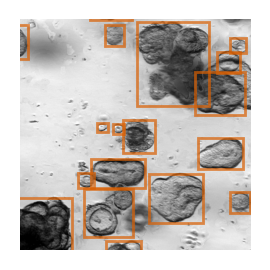

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(width/5.2, width/5.2))

plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='#d95f02', linewidth=1)

ax.set_xlim(3500, 5500)
ax.set_ylim(500, 2500)

ax.axis('off')
ax.set_position((0, 0, 1, 1))
fig.savefig(results_dir.parent / 'results_paper' / f'{dataset}_GT_large.png')


In [305]:
dataset

'NewData_all'

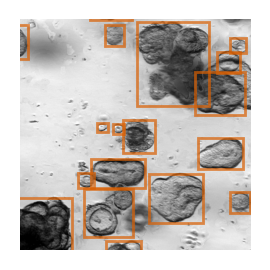

In [307]:
fig, ax = plt.subplots(1, 1, figsize=(width/5.2, width/5.2))

plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='#d95f02', linewidth=1)

# MultiOrg noral idx 11
# ax.set_xlim(500, 1200)
# ax.set_ylim(0, 700)

# MultiOrg noral idx 10
ax.set_xlim(3500, 5500)
ax.set_ylim(500, 2500)


# Tellu
# ax.set_xlim(500, 1200)
# ax.set_ylim(0, 700)

# OrganoID_test_mouse idx 1
# ax.set_xlim(1200, 2500)
# ax.set_ylim(200, 1500)

# OrganoID_test_mouse idx 0
# ax.set_xlim(1000, 1800)
# ax.set_ylim(0, 800)

# # Newdata idx 27
ax.set_xlim(950, 1950)
ax.set_ylim(950, 1950)

ax.axis('off')
ax.set_position((0, 0, 1, 1))
fig.savefig(results_dir.parent / 'results_paper' / f'{dataset}_GT_large.png')

# plot_boxes(im, boxes_samos[scores_samos > 0.9], format='yxyx_px', ax=ax, show_image=False, color='red')

# Plot mask predictions
# gt_masks = pp.convert_mask_to_binary(gt_mask)
# for i in range(gt_boxes.shape[0]):
#     contour = pp.mask_to_contour(gt_masks[i])
#     show_mask(contour, ax, random_color=True)

# show_mask(contours_cellpose[i], ax, random_color=True)

# Define custom line handles
# line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
# line_c = mlines.Line2D([], [], color='red', label='Model', linewidth=2)

# Add legend with custom handles
# plt.legend(handles=[line_a, line_c])

In [308]:
contours_samos, boxes_samos, scores_samos = samos.forward(f'{str(ds)}_{ds.split}', im_ID, predict_masks=False, min_diameter=10)
contours_samos, boxes_samos, scores_samos = samos.set_threshold(thres_samos)

59it [00:04, 13.10it/s]


before filter_diameter 1740716978.3629806
len(self.pred_scores) 17697
after filter_diameter 1740716978.4195976
after nms 1740716978.5280588
after predict masks 1740716978.5281641
after set_threshold 1740716978.5345604


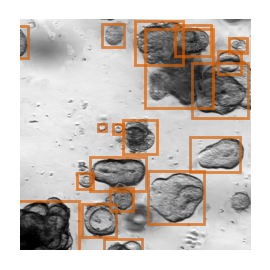

In [309]:
# fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)

# plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
# plot_boxes(im, boxes_samos[scores_samos > 0.9], format='yxyx_px', ax=ax, show_image=False, color='red')

fig, ax = plt.subplots(1, 1, figsize=(width/5.2, width/5.2))

plot_boxes(im, boxes_samos, format='yxyx_px', ax=ax, color='#d95f02', linewidth=1)

ax.set_xlim(950, 1950)
ax.set_ylim(950, 1950)
ax.axis('off')
ax.set_position((0, 0, 1, 1))
fig.savefig(results_dir.parent / 'results_paper' / f'{dataset}_SAMOS_large.png')

# Plot mask predictions
# gt_masks = pp.convert_mask_to_binary(gt_mask)
# for i in range(gt_boxes.shape[0]):
#     contour = pp.mask_to_contour(gt_masks[i])
#     show_mask(contour, ax, random_color=True)

# show_mask(contours_cellpose[i], ax, random_color=True)

# # Define custom line handles
# line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
# line_c = mlines.Line2D([], [], color='red', label='Model', linewidth=2)

# # Add legend with custom handles
# plt.legend(handles=[line_a, line_c])

In [310]:
contours, boxes, scores = frcnnv2.forward(f'{str(ds)}_{ds.split}', im_ID, predict_masks=False, min_diameter=10)
contours, boxes, scores = frcnnv2.set_threshold(thres_frcnnv2)

59it [00:04, 12.18it/s]

before filter_diameter 1740716987.5720556
len(self.pred_scores) 607
after filter_diameter 1740716987.5733294
after nms 1740716987.5891218
after predict masks 1740716987.5891788
after set_threshold 1740716987.5892134


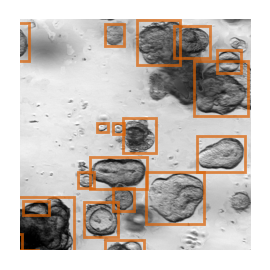

In [311]:
# fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)

# plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
# plot_boxes(im, boxes[scores > 0.5], format='yxyx_px', ax=ax, show_image=False, color='red')



fig, ax = plt.subplots(1, 1, figsize=(width/5.2, width/5.2))

plot_boxes(im, boxes, format='yxyx_px', ax=ax, color='#d95f02', linewidth=1)

ax.set_xlim(950, 1950)
ax.set_ylim(950, 1950)
ax.axis('off')
ax.set_position((0, 0, 1, 1))
fig.savefig(results_dir.parent / 'results_paper' / f'{dataset}_frcnnv2_large.png')


# Plot mask predictions
# gt_masks = pp.convert_mask_to_binary(gt_mask)
# for i in range(gt_boxes.shape[0]):
#     contour = pp.mask_to_contour(gt_masks[i])
#     show_mask(contour, ax, random_color=True)

# show_mask(contours_cellpose[i], ax, random_color=True)

# # Define custom line handles
# line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
# line_c = mlines.Line2D([], [], color='red', label='Model', linewidth=2)

# # Add legend with custom handles
# plt.legend(handles=[line_a, line_c])

In [312]:
contours_ssd, boxes_ssd, scores_ssd = ssd.forward(f'{str(ds)}_{ds.split}', im_ID, predict_masks=False, min_diameter=10)
contours_ssd, boxes_ssd, scores_ssd = ssd.set_threshold(thres_ssd)

59it [00:05, 10.65it/s]

before filter_diameter 1740716994.7647703
len(self.pred_scores) 2766
after filter_diameter 1740716994.767353
after nms 1740716994.8956249
after predict masks 1740716994.8957345
after set_threshold 1740716994.895778


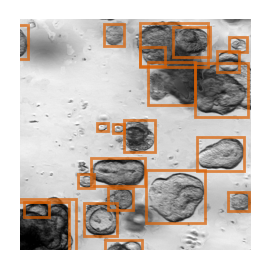

In [313]:
# fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)

# plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
# plot_boxes(im, boxes_ssd[scores_ssd > 0.5], format='yxyx_px', ax=ax, show_image=False, color='red')


fig, ax = plt.subplots(1, 1, figsize=(width/5.2, width/5.2))

plot_boxes(im, boxes_ssd, format='yxyx_px', ax=ax, color='#d95f02', linewidth=1)

ax.set_xlim(950, 1950)
ax.set_ylim(950, 1950)
ax.axis('off')
ax.set_position((0, 0, 1, 1))
fig.savefig(results_dir.parent / 'results_paper' / f'{dataset}_ssd_large.png')

# Plot mask predictions
# gt_masks = pp.convert_mask_to_binary(gt_mask)
# for i in range(gt_boxes.shape[0]):
#     contour = pp.mask_to_contour(gt_masks[i])
#     show_mask(contour, ax, random_color=True)

# show_mask(contours_cellpose[i], ax, random_color=True)

# # Define custom line handles
# line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
# line_c = mlines.Line2D([], [], color='red', label='Model', linewidth=2)

# # Add legend with custom handles
# plt.legend(handles=[line_a, line_c])

In [314]:
contours_orgasegment, boxes_orgasegment, scores_orgasegment = orgasegment.forward(f'{str(ds)}_{ds.split}', im_ID, predict_masks=False, min_diameter=10)
contours_orgasegment, boxes_orgasegment, scores_orgasegment = orgasegment.set_threshold(0.0)

In [315]:
boxes_orgasegment

array([[1220, 1206, 1283, 1267],
       [1948, 1257, 2025, 1432],
       [1375, 1387, 1509, 1533],
       [1709, 1479, 1928, 1765],
       [1072, 1512, 1281, 1746],
       [1838, 1318, 1921, 1398],
       [ 855,  186,  975,  303],
       [1834,   71, 1870,  100],
       [1586,    0, 1737,   49],
       [ 421,  173,  648,  404],
       [ 339, 1378,  459, 1517],
       [1085,  236, 1133,  280],
       [1624,   35, 1849,  286],
       [1605,  718, 1639,  755],
       [ 764,  796, 1169, 1155],
       [1268,  501, 1353,  584],
       [1783,  851, 1921,  978],
       [ 522,  690,  696,  857],
       [ 611, 1744,  883, 1944],
       [1542, 1724, 1810, 1943],
       [1302, 1723, 1436, 1915],
       [1142,  136, 1293,  284],
       [1464, 1287, 1498, 1328],
       [1012, 1233, 1147, 1368],
       [ 861, 1327,  986, 1474],
       [1456, 1354, 1497, 1397],
       [1216, 1263, 1345, 1491],
       [ 798, 1072,  914, 1175],
       [ 869,    1,  981,   62],
       [1805, 1861, 1868, 1928],
       [17

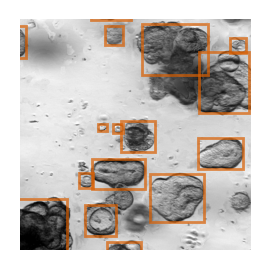

In [316]:
# fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)

# plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
# plot_boxes(im, boxes_ssd[scores_ssd > 0.5], format='yxyx_px', ax=ax, show_image=False, color='red')


fig, ax = plt.subplots(1, 1, figsize=(width/5.2, width/5.2))

plot_boxes(im, boxes_orgasegment, format='yxyx_px', ax=ax, color='#d95f02', linewidth=1)

ax.set_xlim(950, 1950)
ax.set_ylim(950, 1950)
ax.axis('off')
ax.set_position((0, 0, 1, 1))
fig.savefig(results_dir.parent / 'results_paper' / f'{dataset}_orgasegment.png')

# Plot mask predictions
# gt_masks = pp.convert_mask_to_binary(gt_mask)
# for i in range(gt_boxes.shape[0]):
#     contour = pp.mask_to_contour(gt_masks[i])
#     show_mask(contour, ax, random_color=True)

# show_mask(contours_cellpose[i], ax, random_color=True)

# # Define custom line handles
# line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
# line_c = mlines.Line2D([], [], color='red', label='Model', linewidth=2)

# # Add legend with custom handles
# plt.legend(handles=[line_a, line_c])

## Number of parameters per model

In [4]:
model = models.detr_own_impl_model.DetectionTransformer(backbone_name='SAM_large',)

n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Num trainable params (total):", n_parameters)

Num trainable params (total): 4929542


In [5]:
model = models.detr_own_impl_model.DetectionTransformer(backbone_name='SAM2_large',)

n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Num trainable params (total):", n_parameters)

Num trainable params (total): 4929542


In [6]:
model = models.detr_own_impl_model.DetectionTransformer(backbone_name='FM_concat',)

n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Num trainable params (total):", n_parameters)

Num trainable params (total): 5060870


In [7]:
model = models.detr_own_impl_model.DetectionTransformer(backbone_name='SAM_large', num_layers_low_res=12)

n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Num trainable params (total):", n_parameters)

Num trainable params (total): 9674246


In [8]:
model = models.detr_own_impl_model.DetectionTransformer(backbone_name='SAM2_large', 
                                                        num_layers_low_res=11, 
                                                        num_layers_medium_res=6, 
                                                        num_layers_high_res=4)

n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Num trainable params (total):", n_parameters)

Num trainable params (total): 9610854


In [9]:
model = models.detr_own_impl_model.DetectionTransformer(backbone_name='FM_concat', 
                                                        num_layers_low_res=11, 
                                                        num_layers_medium_res=6, 
                                                        num_layers_high_res=4)

n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Num trainable params (total):", n_parameters)

Num trainable params (total): 9742182


In [38]:
import models.embeddings_datamodule

backbone_name = 'SAM2_large'

datamodule = models.embeddings_datamodule.EmbeddingDataModule(train_dirs=["open_images_v4_5/original_data","NeurIPSCellSeg_train"], val_dirs=['NeurIPSCellSeg_val'], batch_size=2, batches_per_epoch=5,use_sampler=True,sampling_groups=['n_objects'], backbone_name=backbone_name, decoder='DETR_own_implementation', num_queries=200)

TypeError: EmbeddingDataModule.__init__() missing 3 required positional arguments: 'test_dirs', 'max_oversampling', and 'n_validation_samples'

## Visual examples full image

In [ ]:
# image_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/orgasegment_test')

# for ds_idx, ds in enumerate([dl.MultiOrg(split='test_macros'),
#                              dl.OrganoID(split='test'),
#                              dl.OrganoID(split='test_C'),
#                              dl.OrganoID(split='test_Lung'),
#                              dl.OrganoID(split='test_ACC'),
#                              dl.OrganoID(split='test_only_mouse'),
#                              dl.OrgaExtractor(split='all'),
#                              dl.NewData(split='all'),
#                              dl.OrgaSegment(split='test'),
#                              dl.OrgaQuant(split='test'),
#                              dl.Tellu(split='test'),
#                              dl.MultiOrg(split='test_normal'),]):
#     for i, (im, gt_mask, gt_boxes, im_path, im_ID) in enumerate(ds):
#         im, flatfield = dl.normalize(im, correct_bg=False if str(ds).startswith('MultiOrg') else True)
#         outfile = image_dir / f"{str(ds)}_{ds.split}__{im_ID}.png"
#         assert not outfile.exists(), outfile
#         cv2.imwrite(str(outfile), im)

In [ ]:
# image_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/umamba_test/test_images')

# for ds_idx, ds in enumerate([dl.MultiOrg(split='test_macros'),
#                              dl.OrganoID(split='test'),
#                              dl.OrganoID(split='test_C'),
#                              dl.OrganoID(split='test_Lung'),
#                              dl.OrganoID(split='test_ACC'),
#                              dl.OrganoID(split='test_only_mouse'),
#                              dl.OrgaExtractor(split='all'),
#                              dl.NewData(split='all'),
#                              dl.OrgaSegment(split='test'),
#                              dl.OrgaQuant(split='test'),
#                              dl.Tellu(split='test'),
#                              dl.MultiOrg(split='test_normal'),]):
#     for i, (im, gt_mask, gt_boxes, im_path, im_ID) in enumerate(ds):
#         im, flatfield = dl.normalize(im, correct_bg=False if str(ds).startswith('MultiOrg') else True)
#         outfile1 = image_dir / f"Dataset{ds_idx:03d}_{str(ds)}{ds.split}" / 'imagesTr' / f"image_{i:03d}_0000.png"
#         outfile2 = image_dir / f"Dataset{ds_idx:03d}_{str(ds)}{ds.split}" / 'imagesTs' / f"image_{i:03d}_0000.png"
#         outfile1.parent.mkdir(exist_ok=True, parents=True)
#         outfile2.parent.mkdir(exist_ok=True, parents=True)
#         cv2.imwrite(str(outfile1), im)
#         cv2.imwrite(str(outfile2), im)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
base_datadir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/original_data/')
results_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results')


def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   
    
def show_box(box, ax, color='red'):
    y_min, x_min, y_max, x_max = box
    
    # Calculate width and height of the box
    width = x_max - x_min
    height = y_max - y_min

    ax.add_patch(plt.Rectangle((x_min, y_min), width, height, edgecolor=color, facecolor=(0,0,0,0), lw=2))

def show_mask(contour, ax, random_color=False):
    if random_color:
        color = np.random.random(3)
    else:
        color = np.array([30/255, 184/255, 255/255])
    edgecolor = np.concatenate([color, np.array([1.0])], axis=0)
    facecolor = np.concatenate([color, np.array([0.1])], axis=0)

    contour = gpd.GeoSeries(contour)
    contour.plot(edgecolor=edgecolor, facecolor=facecolor, ax=ax)

def visualize(im, contours, boxes, random_color=True, box_color='red', format='yxyx_px', ax=None, **fig_kwargs):
    # Format boxes
    H, W = im.shape[:2]

    if format=='cycxhw_01':
        # boxes are in cycxhw format normalized by the longest image side. Converts to min/max coordinates in pixels.
        original_boxes = cxcywh_to_xyxy(boxes) * max(H, W)
    elif format=='cycxhw_px':
        # boxes are in cycxhw format in pixels. Converts to min/max coordinates in pixels.
        original_boxes = cxcywh_to_xyxy(boxes)
    elif format=='yxyx_01':
        # boxes are in min/max coordinates normalized by the longest image side. Converts to min/max coordinates in pixels.
        original_boxes = boxes * max(H, W)
    elif format=='yxyx_px':
        # boxes are in min/max coordinates in pixels. No conversion necessary.
        original_boxes = boxes
    else:
        raise ValueError(format)

    if ax is None:
        fig, ax = plt.subplots(1, 1, **fig_kwargs)
    
    ax.imshow(im)
    ax.axis(False)
    for i in range(original_boxes.shape[0]):
        show_mask(contours[i], ax, random_color=random_color)
        show_box(original_boxes[i], ax, color=box_color)

### Test mAP metric

In [3]:
# anchordetr = PredictionSAM(sam_version='sam1', logging_name="AnchorDETR_resnet50_MultiOrg_train_normal_MultiOrg_train_macros_OrgaSegment_train_Tellu_train_OrgaQuant_train_anchor_detr_strong_aug_finetuning_long_True_12_100_2024")
# samos = PredictionSAM(sam_version='sam1', logging_name="AnchorDETR_SAM_base_images_MultiOrg_train_normal_MultiOrg_train_macros_OrgaSegment_train_Tellu_train_OrgaQuant_train_anchor_detr_sam_base_strong_aug_finetuning_long_True_12_100_2024")
# frcnnv2 = PredictionSAM(sam_version='sam1', logging_name="FRCNNv2_default_MultiOrg_train_normal_MultiOrg_train_macros_OrgaSegment_train_Tellu_train_OrgaQuant_train_frcnn_v2_strong_aug_finetuning_long_True_12_100_2024")

anchordetr = PredictionSAM(sam_version='sam1', logging_name="anchor_detr_1200_best")
frcnnv2 = PredictionSAM(sam_version='sam1', logging_name="frcnn_v2_1200_best")
samos = PredictionSAM(sam_version='sam1', logging_name="anchor_detr_sam_base_1200_best")
# orgasegment = PredictorFromMasks('OrgaSegment')

/ictstr01/groups/peng/datasets/lion/data/venvs/cellsam_evaluation/lib/python3.11/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

In [72]:
model = 'impr_thres_anchor_detr_2024_sam1'
# model = 'impr_thres_anchor_detr_sam_base_2024_sam1'
# model = 'impr_thres_frcnnv2_strong_aug_2024_sam1'

In [4]:
# ds = dl.OrgaExtractor(split='test')
# ds = dl.Tellu(split='test')
# ds = dl.OrgaQuant(split='test')
# ds = dl.OrgaSegment(split='test')
# ds = dl.OrganoID(split='test')
# ds = dl.OrganoID(split='test_only_mouse')
# ds = dl.OrganoID(split='test_C')
# ds = dl.OrganoID(split='test_ACC')
# ds = dl.OrganoID(split='test_Lung')
ds = dl.NewData(split='all')
# ds = dl.MultiOrg(split='test_normal')
# ds = dl.MultiOrg(split='test_macros')

idx = 21
im, gt_mask, gt_boxes, im_path, im_ID = ds[idx]
# im2, gt_mask2, gt_boxes2, im_path2, im_ID2 = ds[idx]
im, flatfield = dl.normalize(im, correct_bg=True)
# im2, flatfield2 = dl.normalize(im2, correct_bg=False)
print(im.shape)

(2048, 2048, 3)


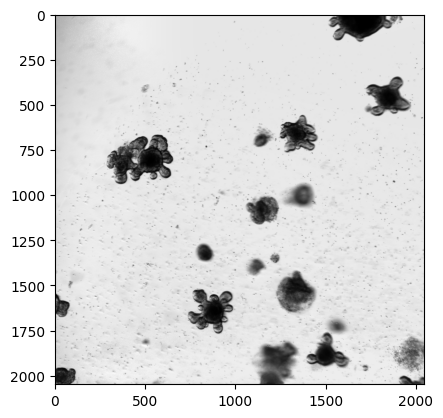

In [5]:
plt.imshow(im)

In [23]:
# curr_model = frcnnv2
# curr_model = anchordetr
curr_model = samos

In [16]:
contours_pred, boxes_pred, scores_pred = curr_model.forward(f'{str(ds)}_{ds.split}', im_ID, predict_masks=True, min_diameter=10)

60it [00:04, 12.59it/s]
/ictstr01/home/icb/lion.gleiter/projects/organoid_sam/SAM_with_Detection_Head/src/samos/util/pred_with_sam.py:175: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

before filter_diameter 1757092963.0204916
len(self.pred_scores) 18000
after filter_diameter 1757092963.0238125
after nms 1757092963.1825998


/ictstr01/home/icb/lion.gleiter/projects/organoid_sam/SAM_with_Detection_Head/src/samos/util/pred_with_sam.py:175: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  image_embedd

after predict masks 1757092990.8348238
after set_threshold 1757092990.8351803


In [24]:
contours_pred, boxes_pred, scores_pred = curr_model.set_threshold(0.0)

In [25]:
boxes_pred.shape

(400, 4)

In [26]:
len(scores_pred), len(gt_boxes)

(400, 13)

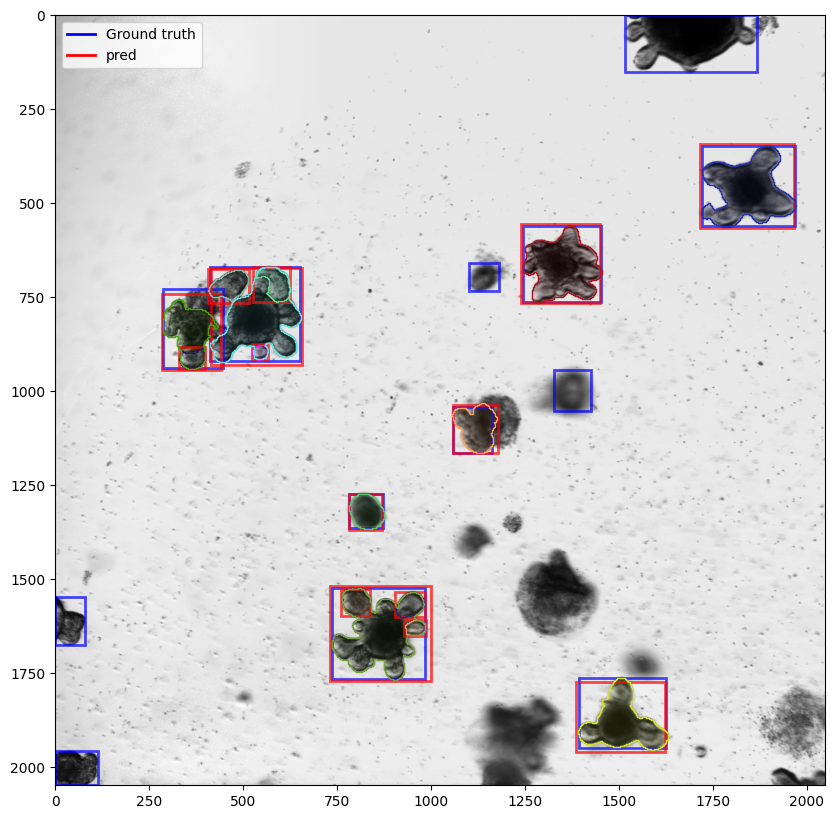

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)

thres = 0.8

curr_boxes_pred = boxes_pred[scores_pred >= thres]
curr_contours_pred = [c for c, s in zip(contours_pred, scores_pred) if s >= thres]
curr_scores_pred = scores_pred[scores_pred >= thres]

# i = 10
# plot_boxes(im, gt_boxes[i:i+1], format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, curr_boxes_pred, format='yxyx_px', ax=ax, show_image=False, color='red')

# Plot mask predictions
for i in range(curr_boxes_pred.shape[0]):
    show_mask(curr_contours_pred[i], ax, random_color=True)

# show_mask(contours_cellpose[i], ax, random_color=True)

# Define custom line handles
line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
line_c = mlines.Line2D([], [], color='red', label='pred', linewidth=2)

# Add legend with custom handles
plt.legend(handles=[line_a, line_c])

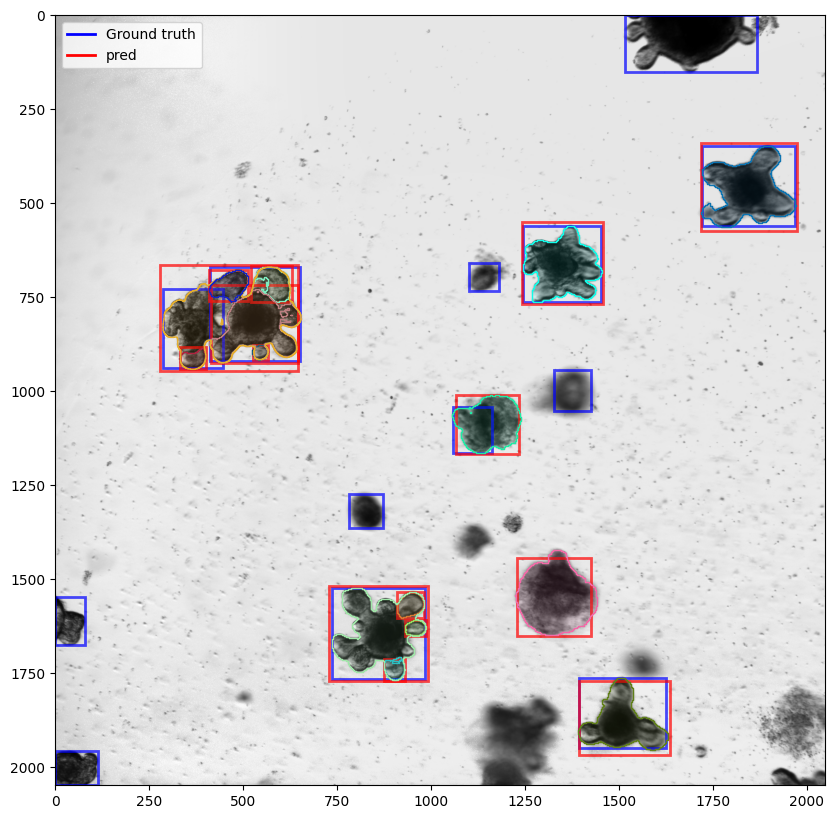

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)

thres = 0.8

curr_boxes_pred = boxes_pred[scores_pred >= thres]
curr_contours_pred = [c for c, s in zip(contours_pred, scores_pred) if s >= thres]
curr_scores_pred = scores_pred[scores_pred >= thres]

# i = 10
# plot_boxes(im, gt_boxes[i:i+1], format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, curr_boxes_pred, format='yxyx_px', ax=ax, show_image=False, color='red')

# Plot mask predictions
for i in range(curr_boxes_pred.shape[0]):
    show_mask(curr_contours_pred[i], ax, random_color=True)

# show_mask(contours_cellpose[i], ax, random_color=True)

# Define custom line handles
line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
line_c = mlines.Line2D([], [], color='red', label='pred', linewidth=2)

# Add legend with custom handles
plt.legend(handles=[line_a, line_c])

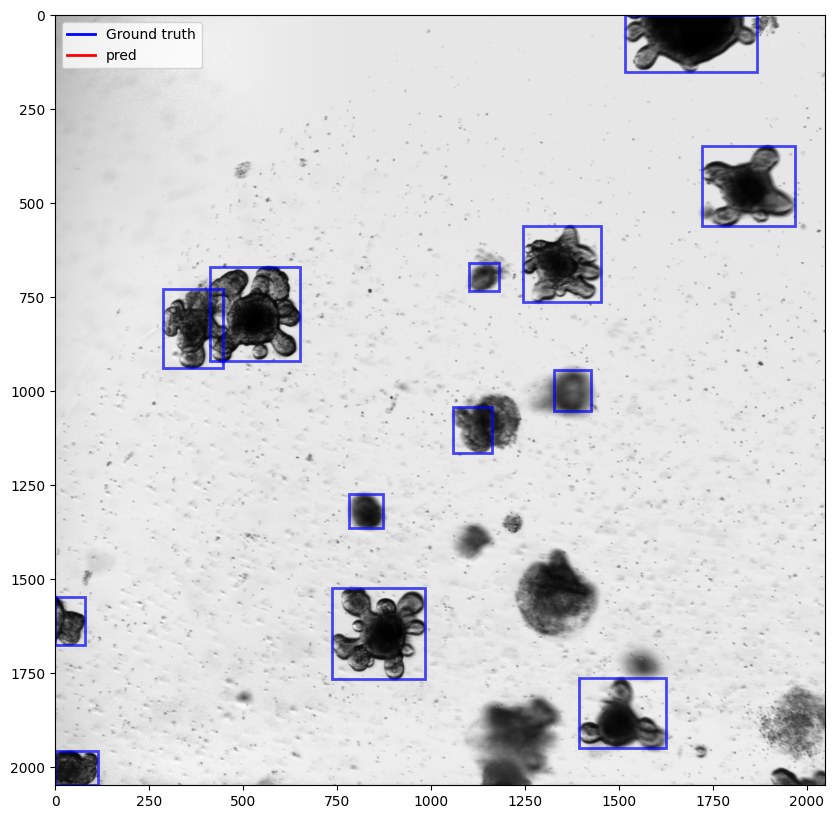

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)

thres = 0.99

curr_boxes_pred = boxes_pred[scores_pred >= thres]
curr_contours_pred = [c for c, s in zip(contours_pred, scores_pred) if s >= thres]
curr_scores_pred = scores_pred[scores_pred >= thres]

# i = 10
# plot_boxes(im, gt_boxes[i:i+1], format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, curr_boxes_pred, format='yxyx_px', ax=ax, show_image=False, color='red')

# Plot mask predictions
for i in range(curr_boxes_pred.shape[0]):
    show_mask(curr_contours_pred[i], ax, random_color=True)

# show_mask(contours_cellpose[i], ax, random_color=True)

# Define custom line handles
line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
line_c = mlines.Line2D([], [], color='red', label='pred', linewidth=2)

# Add legend with custom handles
plt.legend(handles=[line_a, line_c])

In [ ]:
iou_thres = [0.5, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
# thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.975]
thresholds = [0.0]
iou_matrix = pp.compute_iou_matrix_detection(boxes_pred, gt_boxes)
mAP_scores, pq_scores, iou_scores, dice_scores, f1_scores, prec_scores, recall_scores = pp.compute_metrics_detection_all(
    iou_matrix, iou_thres, scores_pred, thresholds
)
mAP_scores, pq_scores, iou_scores, dice_scores, f1_scores, prec_scores, recall_scores

iou_matrix[:10, :10] [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
cost_matrix.shape (228, 363)
cost_matrix.shape (228, 363)
cost_matrix[:10, :10] [[-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]]
row_ind, col_ind [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  2

([0.5980428418502148,
  0.5830628175531234,
  0.539949801911429,
  0.4872004273533451,
  0.3553369082591981,
  0.2060884166015704,
  0.052875642559272754,
  0.000931282522191613],
 [0.0, 0.0],
 [0.8370776129144657, 0.8370776129144657],
 [0.9089629633861215, 0.9089629633861215],
 [0.7411167512690355, 0.7411167512690355],
 [0.9605263157894737, 0.9605263157894737],
 [0.6033057851239669, 0.6033057851239669])

In [59]:
iou_thres = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.975]
# thresholds = [0.95, 0.975]
iou_matrix = pp.compute_iou_matrix_detection(boxes_cellpose, gt_boxes)
mAP_scores, pq_scores, iou_scores, dice_scores, f1_scores, prec_scores, recall_scores = pp.compute_metrics_detection_all(
    iou_matrix, iou_thres, scores_cellpose, thresholds
)
mAP_scores, pq_scores, iou_scores, dice_scores, f1_scores, prec_scores, recall_scores

([0.8988737603074881,
  0.8700531931282185,
  0.7492780019972695,
  0.6312155004797192,
  0.437563627038787,
  0.24103952224217537,
  0.05431799216106645,
  0.000931282522191613],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.8127924307799258,
  0.8140593448376187,
  0.8137166112760973,
  0.8151871315935983,
  0.8152220726607609,
  0.8159061910950245,
  0.8181208429079629,
  0.8191993227105802,
  0.8207673265870226,
  0.8219701203756414,
  0.8295728523235139,
  0.8370776129144657],
 [0.8938612238358746,
  0.8946111618623602,
  0.8943720405640683,
  0.895285540091962,
  0.8952887071713503,
  0.8957603541655978,
  0.8971857128148022,
  0.8978319788873353,
  0.8987702933677536,
  0.8994357628683936,
  0.9043777105865567,
  0.9089629633861215],
 [0.6932270916334662,
  0.7409836065573769,
  0.7608200455580866,
  0.7705112960760998,
  0.7826086956521738,
  0.8015463917525772,
  0.8073878627968337,
  0.8122392211404728,
  0.8114285714285714,
  0.8017751479289942,
  0.7918

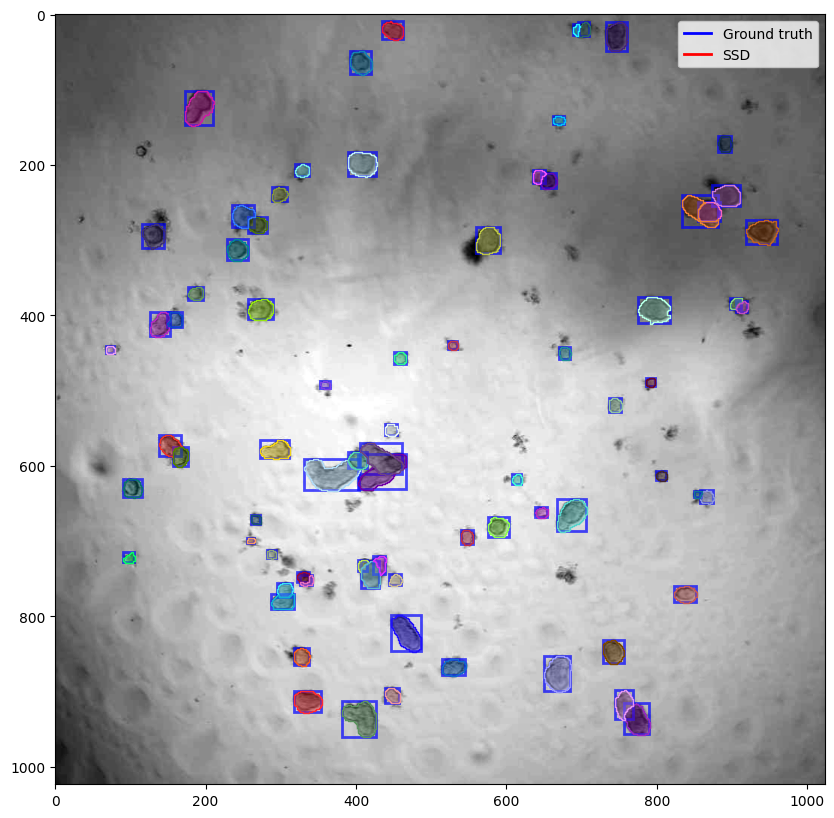

In [86]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
# i = 10
# plot_boxes(im, gt_boxes[i:i+1], format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
# plot_boxes(im, boxes_cellpose, format='yxyx_px', ax=ax, show_image=False, color='red')

# Plot mask predictions
gt_masks = pp.convert_mask_to_binary(gt_mask)
for i in range(gt_boxes.shape[0]):
    contour = pp.mask_to_contour(gt_masks[i])
    show_mask(contour, ax, random_color=True)

# show_mask(contours_cellpose[i], ax, random_color=True)

# Define custom line handles
line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
line_c = mlines.Line2D([], [], color='red', label='SSD', linewidth=2)

# Add legend with custom handles
plt.legend(handles=[line_a, line_c])

In [93]:
# ds = dl.OrgaExtractor(split='test')
# ds = dl.Tellu(split='test')
# ds = dl.OrgaQuant(split='test')
# ds = dl.OrgaSegment(split='test')
# ds = dl.OrganoID(split='test')
# ds = dl.OrganoID(split='test_only_mouse')
# ds = dl.OrganoID(split='test_C')
# ds = dl.OrganoID(split='test_ACC')
# ds = dl.OrganoID(split='test_Lung')
ds = dl.NewData(split='all')
# ds = dl.MultiOrg(split='test_normal')
# ds = dl.MultiOrg(split='test_macros')

mAP_metric = torchmetrics.detection.MeanAveragePrecision(class_metrics=True, extended_summary=False, backend='faster_coco_eval', )
mAP_metric.warn_on_many_detections = False

mAP_metric.reset()

for im, gt_mask, gt_boxes, im_path, im_ID in ds:
#     im, flatfield = dl.normalize(im, correct_bg=False)
    contours_cellpose, boxes_cellpose, scores_cellpose = gtsam_model.forward(im, gt_boxes, patch_size=(512, 1024), predict_masks=False, min_diameter=10)
    contours_cellpose, boxes_cellpose, scores_cellpose = gtsam_model.set_threshold(0.0, predict_masks=True)
    mAP_metric.update(preds=[{'boxes': torch.from_numpy(boxes_cellpose), 
                        'scores': torch.from_numpy(scores_cellpose), 
                        'labels': torch.zeros(scores_cellpose.shape, dtype=torch.int)}], 
                target=[{'boxes': torch.from_numpy(gt_boxes), 
                        'labels': torch.zeros((gt_boxes.shape[0],), dtype=torch.int)}])
    print(mAP_metric.compute())

Error: The following operation failed in the TorchScript interpreter.
Traceback of TorchScript (most recent call last):
  File "/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/torchvision/transforms/_functional_tensor.py", line 909, in forward

    if not tensor.is_floating_point():
        raise TypeError(f"Input tensor should be a float tensor. Got {tensor.dtype}.")
        ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ <--- HERE

    if tensor.ndim < 3:
builtins.TypeError: Input tensor should be a float tensor. Got 27.


In [87]:
contours_cellpose, boxes_cellpose, scores_cellpose = gtsam_model.set_threshold(0.0, predict_masks=True)

In [55]:
contours_cellpose2, boxes_cellpose2, scores_cellpose2 = gtsam_model.set_threshold(0.0, predict_masks=True)

In [88]:
mAP_metric = torchmetrics.detection.MeanAveragePrecision(class_metrics=True, extended_summary=False, backend='faster_coco_eval', )
mAP_metric.warn_on_many_detections = False

In [89]:
mAP_metric.reset()

In [90]:
mAP_metric.update(preds=[{'boxes': torch.from_numpy(boxes_cellpose), 
                        'scores': torch.from_numpy(scores_cellpose), 
                        'labels': torch.zeros(scores_cellpose.shape, dtype=torch.int)}], 
                target=[{'boxes': torch.from_numpy(gt_boxes), 
                        'labels': torch.zeros((gt_boxes.shape[0],), dtype=torch.int)}])

In [91]:
res = mAP_metric.compute()
# res['map'], res['ious'].keys()
res

{'map': tensor(1.),
 'map_50': tensor(1.),
 'map_75': tensor(1.),
 'map_small': tensor(1.),
 'map_medium': tensor(1.),
 'map_large': tensor(-1.),
 'mar_1': tensor(0.0132),
 'mar_10': tensor(0.1316),
 'mar_100': tensor(1.),
 'mar_small': tensor(1.),
 'mar_medium': tensor(1.),
 'mar_large': tensor(-1.),
 'map_per_class': tensor(1.),
 'mar_100_per_class': tensor(1.),
 'classes': tensor(0, dtype=torch.int32)}

In [ ]:
mAP_metric.update(preds=[{'boxes': torch.from_numpy(boxes_cellpose2), 
                        'scores': torch.from_numpy(scores_cellpose2), 
                        'labels': torch.zeros(scores_cellpose2.shape, dtype=torch.int)}], 
                target=[{'boxes': torch.from_numpy(gt_boxes2), 
                        'labels': torch.zeros((gt_boxes2.shape[0],), dtype=torch.int)}])

In [55]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.975]
iou_thres = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

iou_matrix_seg = pp.compute_iou_matrix_segmentation_contours(contours_cellpose, gt_masks=gt_masks)
mAP_scores, hausdorff_scores, hausdorff_95_scores, masd_scores, assd_scores, iou_scores_no_thres, dice_scores_no_thres, pq_scores, iou_scores, dice_scores, f1_scores, prec_scores, recall_scores = pp.compute_metrics_segmentation_all(
    iou_matrix_seg, iou_thres, scores_cellpose, thresholds, gt_masks, contours_cellpose
)
pd.DataFrame({
    'iou_thres': map(lambda x: f'{x:.3f}', iou_thres), 
    'AP': mAP_scores, 
    'hausdorff_scores': hausdorff_scores, 
    'hausdorff_95_scores': hausdorff_95_scores, 
    'masd_scores': masd_scores, 
    'assd_scores': assd_scores,
    'iou_scores_no_thres': iou_scores_no_thres,
    'dice_scores_no_thres': dice_scores_no_thres,
})

,iou_thres,AP,hausdorff_scores,hausdorff_95_scores,masd_scores,assd_scores,iou_scores_no_thres,dice_scores_no_thres
0,0.500,0.669883,4.090619,3.344045,1.129162,1.138988,0.829142,0.899623
1,0.600,0.478901,3.328291,2.607159,0.856275,0.859807,0.880095,0.934001
2,0.700,0.442547,3.128285,2.389700,0.786893,0.789081,0.892015,0.941769
3,0.750,0.350405,3.026963,2.277063,0.712285,0.714141,0.908287,0.951634
4,0.800,0.350405,3.026963,2.277063,0.712285,0.714141,0.908287,0.951634
5,0.850,0.303890,2.844881,2.119397,0.680073,0.681767,0.913370,0.954499
6,0.900,0.133824,2.182637,1.556366,0.570575,0.570796,0.931082,0.964238
7,0.950,0.004976,1.662570,1.103553,0.406625,0.406714,0.955863,0.977429


In [56]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.975]
iou_thres = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

iou_matrix_seg = pp.compute_iou_matrix_segmentation_contours(contours_cellpose, gt_masks=gt_masks)
mAP_scores, hausdorff_scores, hausdorff_95_scores, masd_scores, assd_scores, iou_scores_no_thres, dice_scores_no_thres, pq_scores, iou_scores, dice_scores, f1_scores, prec_scores, recall_scores = pp.compute_metrics_segmentation_all(
    iou_matrix_seg, iou_thres, scores_cellpose, thresholds, gt_masks, contours_cellpose
)
pd.DataFrame({
    'iou_thres': map(lambda x: f'{x:.3f}', iou_thres), 
    'AP': mAP_scores, 
    'hausdorff_scores': hausdorff_scores, 
    'hausdorff_95_scores': hausdorff_95_scores, 
    'masd_scores': masd_scores, 
    'assd_scores': assd_scores,
    'iou_scores_no_thres': iou_scores_no_thres,
    'dice_scores_no_thres': dice_scores_no_thres,
})

,iou_thres,AP,hausdorff_scores,hausdorff_95_scores,masd_scores,assd_scores,iou_scores_no_thres,dice_scores_no_thres
0,0.500,0.669883,4.090619,3.344045,1.129162,1.138988,0.829142,0.899623
1,0.600,0.478901,3.328291,2.607159,0.856275,0.859807,0.880095,0.934001
2,0.700,0.442547,3.128285,2.389700,0.786893,0.789081,0.892015,0.941769
3,0.750,0.350405,3.026963,2.277063,0.712285,0.714141,0.908287,0.951634
4,0.800,0.350405,3.026963,2.277063,0.712285,0.714141,0.908287,0.951634
5,0.850,0.303890,2.844881,2.119397,0.680073,0.681767,0.913370,0.954499
6,0.900,0.133824,2.182637,1.556366,0.570575,0.570796,0.931082,0.964238
7,0.950,0.004976,1.662570,1.103553,0.406625,0.406714,0.955863,0.977429


In [31]:
scores_cellpose

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1.])

In [29]:
iou_matrix_seg

array([[0.94815275, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.7173913 , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.77578475, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.89081225, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.75287356,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.96330275]])

In [37]:
len(ds)

12

In [38]:
boxes_cellpose.shape

(41, 4)

In [41]:
pred_sam_model.pred_boxes.shape

(59150, 4)

In [2]:
import sys
sys.path.append('/home/icb/lion.gleiter/projects/organoid_sam/sam2')

In [ ]:

# from sam2.build_sam import build_sam2
# from sam2.sam2_image_predictor import SAM2ImagePredictor


# device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device = torch.device('cpu')
checkpoint_name = "/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints/sam2.1_hiera_large.pt"
config_name = "configs/sam2.1/sam2.1_hiera_l.yaml"
sam2 = build_sam2(config_name, checkpoint=checkpoint_name, device=device)
# sam2.eval()
sam_predictor = SAM2ImagePredictor(sam2)
# sam_predictor.reset_state()

cfg {'model': {'_target_': 'sam2.modeling.sam2_base.SAM2Base', 'image_encoder': {'_target_': 'sam2.modeling.backbones.image_encoder.ImageEncoder', 'scalp': 1, 'trunk': {'_target_': 'sam2.modeling.backbones.hieradet.Hiera', 'embed_dim': 144, 'num_heads': 2, 'stages': [2, 6, 36, 4], 'global_att_blocks': [23, 33, 43], 'window_pos_embed_bkg_spatial_size': [7, 7], 'window_spec': [8, 4, 16, 8]}, 'neck': {'_target_': 'sam2.modeling.backbones.image_encoder.FpnNeck', 'position_encoding': {'_target_': 'sam2.modeling.position_encoding.PositionEmbeddingSine', 'num_pos_feats': 256, 'normalize': True, 'scale': None, 'temperature': 10000}, 'd_model': 256, 'backbone_channel_list': [1152, 576, 288, 144], 'fpn_top_down_levels': [2, 3], 'fpn_interp_model': 'nearest'}}, 'memory_attention': {'_target_': 'sam2.modeling.memory_attention.MemoryAttention', 'd_model': 256, 'pos_enc_at_input': True, 'layer': {'_target_': 'sam2.modeling.memory_attention.MemoryAttentionLayer', 'activation': 'relu', 'dim_feedforwar

In [10]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

sam2_checkpoint = "/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)

sam_predictor = SAM2ImagePredictor(sam2_model)

cfg {'model': {'_target_': 'sam2.modeling.sam2_base.SAM2Base', 'image_encoder': {'_target_': 'sam2.modeling.backbones.image_encoder.ImageEncoder', 'scalp': 1, 'trunk': {'_target_': 'sam2.modeling.backbones.hieradet.Hiera', 'embed_dim': 144, 'num_heads': 2, 'stages': [2, 6, 36, 4], 'global_att_blocks': [23, 33, 43], 'window_pos_embed_bkg_spatial_size': [7, 7], 'window_spec': [8, 4, 16, 8]}, 'neck': {'_target_': 'sam2.modeling.backbones.image_encoder.FpnNeck', 'position_encoding': {'_target_': 'sam2.modeling.position_encoding.PositionEmbeddingSine', 'num_pos_feats': 256, 'normalize': True, 'scale': None, 'temperature': 10000}, 'd_model': 256, 'backbone_channel_list': [1152, 576, 288, 144], 'fpn_top_down_levels': [2, 3], 'fpn_interp_model': 'nearest'}}, 'memory_attention': {'_target_': 'sam2.modeling.memory_attention.MemoryAttention', 'd_model': 256, 'pos_enc_at_input': True, 'layer': {'_target_': 'sam2.modeling.memory_attention.MemoryAttentionLayer', 'activation': 'relu', 'dim_feedforwar

In [31]:
cfg_test = "cfg {'model': {'_target_': 'sam2.modeling.sam2_base.SAM2Base', 'image_encoder': {'_target_': 'sam2.modeling.backbones.image_encoder.ImageEncoder', 'scalp': 1, 'trunk': {'_target_': 'sam2.modeling.backbones.hieradet.Hiera', 'embed_dim': 144, 'num_heads': 2, 'stages': [2, 6, 36, 4], 'global_att_blocks': [23, 33, 43], 'window_pos_embed_bkg_spatial_size': [7, 7], 'window_spec': [8, 4, 16, 8]}, 'neck': {'_target_': 'sam2.modeling.backbones.image_encoder.FpnNeck', 'position_encoding': {'_target_': 'sam2.modeling.position_encoding.PositionEmbeddingSine', 'num_pos_feats': 256, 'normalize': True, 'scale': None, 'temperature': 10000}, 'd_model': 256, 'backbone_channel_list': [1152, 576, 288, 144], 'fpn_top_down_levels': [2, 3], 'fpn_interp_model': 'nearest'}}, 'memory_attention': {'_target_': 'sam2.modeling.memory_attention.MemoryAttention', 'd_model': 256, 'pos_enc_at_input': True, 'layer': {'_target_': 'sam2.modeling.memory_attention.MemoryAttentionLayer', 'activation': 'relu', 'dim_feedforward': 2048, 'dropout': 0.1, 'pos_enc_at_attn': False, 'self_attention': {'_target_': 'sam2.modeling.sam.transformer.RoPEAttention', 'rope_theta': 10000.0, 'feat_sizes': [64, 64], 'embedding_dim': 256, 'num_heads': 1, 'downsample_rate': 1, 'dropout': 0.1}, 'd_model': 256, 'pos_enc_at_cross_attn_keys': True, 'pos_enc_at_cross_attn_queries': False, 'cross_attention': {'_target_': 'sam2.modeling.sam.transformer.RoPEAttention', 'rope_theta': 10000.0, 'feat_sizes': [64, 64], 'rope_k_repeat': True, 'embedding_dim': 256, 'num_heads': 1, 'downsample_rate': 1, 'dropout': 0.1, 'kv_in_dim': 64}}, 'num_layers': 4}, 'memory_encoder': {'_target_': 'sam2.modeling.memory_encoder.MemoryEncoder', 'out_dim': 64, 'position_encoding': {'_target_': 'sam2.modeling.position_encoding.PositionEmbeddingSine', 'num_pos_feats': 64, 'normalize': True, 'scale': None, 'temperature': 10000}, 'mask_downsampler': {'_target_': 'sam2.modeling.memory_encoder.MaskDownSampler', 'kernel_size': 3, 'stride': 2, 'padding': 1}, 'fuser': {'_target_': 'sam2.modeling.memory_encoder.Fuser', 'layer': {'_target_': 'sam2.modeling.memory_encoder.CXBlock', 'dim': 256, 'kernel_size': 7, 'padding': 3, 'layer_scale_init_value': 1e-06, 'use_dwconv': True}, 'num_layers': 2}}, 'num_maskmem': 7, 'image_size': 1024, 'sigmoid_scale_for_mem_enc': 20.0, 'sigmoid_bias_for_mem_enc': -10.0, 'use_mask_input_as_output_without_sam': True, 'directly_add_no_mem_embed': True, 'no_obj_embed_spatial': True, 'use_high_res_features_in_sam': True, 'multimask_output_in_sam': True, 'iou_prediction_use_sigmoid': True, 'use_obj_ptrs_in_encoder': True, 'add_tpos_enc_to_obj_ptrs': True, 'proj_tpos_enc_in_obj_ptrs': True, 'use_signed_tpos_enc_to_obj_ptrs': True, 'only_obj_ptrs_in_the_past_for_eval': True, 'pred_obj_scores': True, 'pred_obj_scores_mlp': True, 'fixed_no_obj_ptr': True, 'multimask_output_for_tracking': True, 'use_multimask_token_for_obj_ptr': True, 'multimask_min_pt_num': 0, 'multimask_max_pt_num': 1, 'use_mlp_for_obj_ptr_proj': True, 'compile_image_encoder': False, 'sam_mask_decoder_extra_args': {'dynamic_multimask_via_stability': True, 'dynamic_multimask_stability_delta': 0.05, 'dynamic_multimask_stability_thresh': 0.98}}}"
cfg_working = "cfg {'model': {'_target_': 'sam2.modeling.sam2_base.SAM2Base', 'image_encoder': {'_target_': 'sam2.modeling.backbones.image_encoder.ImageEncoder', 'scalp': 1, 'trunk': {'_target_': 'sam2.modeling.backbones.hieradet.Hiera', 'embed_dim': 144, 'num_heads': 2, 'stages': [2, 6, 36, 4], 'global_att_blocks': [23, 33, 43], 'window_pos_embed_bkg_spatial_size': [7, 7], 'window_spec': [8, 4, 16, 8]}, 'neck': {'_target_': 'sam2.modeling.backbones.image_encoder.FpnNeck', 'position_encoding': {'_target_': 'sam2.modeling.position_encoding.PositionEmbeddingSine', 'num_pos_feats': 256, 'normalize': True, 'scale': None, 'temperature': 10000}, 'd_model': 256, 'backbone_channel_list': [1152, 576, 288, 144], 'fpn_top_down_levels': [2, 3], 'fpn_interp_model': 'nearest'}}, 'memory_attention': {'_target_': 'sam2.modeling.memory_attention.MemoryAttention', 'd_model': 256, 'pos_enc_at_input': True, 'layer': {'_target_': 'sam2.modeling.memory_attention.MemoryAttentionLayer', 'activation': 'relu', 'dim_feedforward': 2048, 'dropout': 0.1, 'pos_enc_at_attn': False, 'self_attention': {'_target_': 'sam2.modeling.sam.transformer.RoPEAttention', 'rope_theta': 10000.0, 'feat_sizes': [64, 64], 'embedding_dim': 256, 'num_heads': 1, 'downsample_rate': 1, 'dropout': 0.1}, 'd_model': 256, 'pos_enc_at_cross_attn_keys': True, 'pos_enc_at_cross_attn_queries': False, 'cross_attention': {'_target_': 'sam2.modeling.sam.transformer.RoPEAttention', 'rope_theta': 10000.0, 'feat_sizes': [64, 64], 'rope_k_repeat': True, 'embedding_dim': 256, 'num_heads': 1, 'downsample_rate': 1, 'dropout': 0.1, 'kv_in_dim': 64}}, 'num_layers': 4}, 'memory_encoder': {'_target_': 'sam2.modeling.memory_encoder.MemoryEncoder', 'out_dim': 64, 'position_encoding': {'_target_': 'sam2.modeling.position_encoding.PositionEmbeddingSine', 'num_pos_feats': 64, 'normalize': True, 'scale': None, 'temperature': 10000}, 'mask_downsampler': {'_target_': 'sam2.modeling.memory_encoder.MaskDownSampler', 'kernel_size': 3, 'stride': 2, 'padding': 1}, 'fuser': {'_target_': 'sam2.modeling.memory_encoder.Fuser', 'layer': {'_target_': 'sam2.modeling.memory_encoder.CXBlock', 'dim': 256, 'kernel_size': 7, 'padding': 3, 'layer_scale_init_value': 1e-06, 'use_dwconv': True}, 'num_layers': 2}}, 'num_maskmem': 7, 'image_size': 1024, 'sigmoid_scale_for_mem_enc': 20.0, 'sigmoid_bias_for_mem_enc': -10.0, 'use_mask_input_as_output_without_sam': True, 'directly_add_no_mem_embed': True, 'no_obj_embed_spatial': True, 'use_high_res_features_in_sam': True, 'multimask_output_in_sam': True, 'iou_prediction_use_sigmoid': True, 'use_obj_ptrs_in_encoder': True, 'add_tpos_enc_to_obj_ptrs': True, 'proj_tpos_enc_in_obj_ptrs': True, 'use_signed_tpos_enc_to_obj_ptrs': True, 'only_obj_ptrs_in_the_past_for_eval': True, 'pred_obj_scores': True, 'pred_obj_scores_mlp': True, 'fixed_no_obj_ptr': True, 'multimask_output_for_tracking': True, 'use_multimask_token_for_obj_ptr': True, 'multimask_min_pt_num': 0, 'multimask_max_pt_num': 1, 'use_mlp_for_obj_ptr_proj': True, 'compile_image_encoder': False, 'sam_mask_decoder_extra_args': {'dynamic_multimask_via_stability': True, 'dynamic_multimask_stability_delta': 0.05, 'dynamic_multimask_stability_thresh': 0.98}}}"

In [32]:
cfg_test == cfg_working

True

In [82]:
im.shape

(1024, 1024, 3)

In [ ]:
sam_predictor.set_image(im)

In [102]:
!wget -P images https://raw.githubusercontent.com/facebookresearch/sam2/main/notebooks/images/truck.jpg

--2025-02-17 12:50:13--  https://raw.githubusercontent.com/facebookresearch/sam2/main/notebooks/images/truck.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 271475 (265K) [image/jpeg]
Saving to: ‘images/truck.jpg’

truck.jpg           100%[===================>] 265.11K  1.14MB/s    in 0.2s    

2025-02-17 12:50:16 (1.14 MB/s) - ‘images/truck.jpg’ saved [271475/271475]



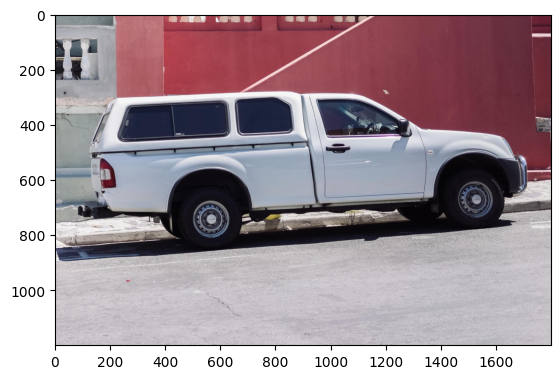

In [4]:
im2 = cv2.imread('images/truck.jpg')
im2 = cv2.cvtColor(im2, cv2.COLOR_RGB2BGR)
plt.imshow(im2)

In [11]:
im2.shape, im2.min(), im2.max(), im2.dtype

((1200, 1800, 3), 0, 255, dtype('uint8'))

In [11]:
sam_predictor.set_image(im2[:512, :512])

In [5]:
gtsam_model.sam_predictor.set_image(im2[:512, :512])

In [7]:
input_point = np.array([[510, 220]])
input_label = np.array([1])

In [16]:
input_point = np.array([[500, 375]])
input_label = np.array([1])

In [8]:
input_box = gt_boxes[0]
# # transformed_boxes = input_box[None, :]
transformed_boxes = np.array([[input_box[1], input_box[0], input_box[3], input_box[2]]])
# with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
masks, scs, _ = gtsam_model.sam_predictor.predict(
    point_coords=None,
    point_labels=None,
    box=transformed_boxes,
    multimask_output=False,
)
# masks, scs, _ = sam_predictor.predict(
#     point_coords=input_point,
#     point_labels=input_label,
#     multimask_output=False,
# )

In [16]:
masks.shape

(1, 512, 512)

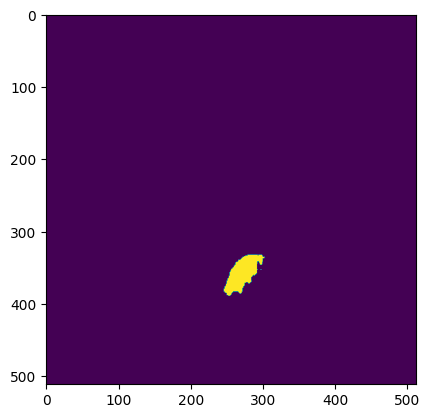

In [9]:
plt.imshow(masks[0])

In [48]:
contours_samos, boxes_samos, scores_samos = samos_model.set_threshold(0.7, predict_masks=True)

In [11]:
print(gt_boxes.shape, boxes_cellpose.shape, boxes_cellpose.shape, scores_cellpose, scores_cellpose, len(ds), type(boxes_cellpose))

(36, 4) (1, 4) (1, 4) [1.] [1.] 12 <class 'numpy.ndarray'>


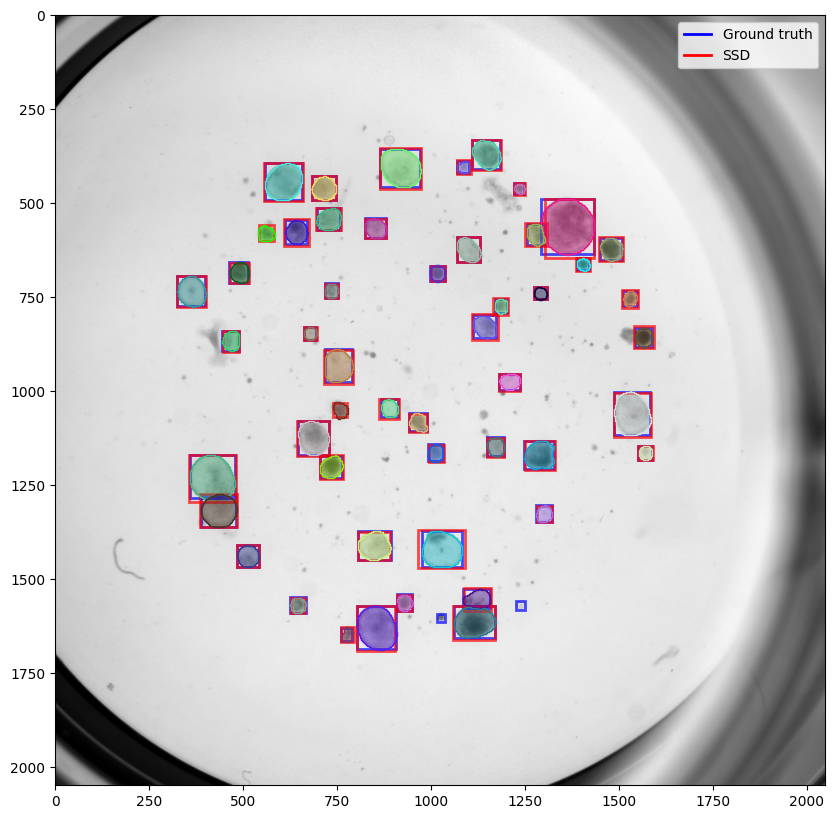

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes_cellpose, format='yxyx_px', ax=ax, show_image=False, color='red')

# Plot mask predictions
for i in range(boxes_cellpose.shape[0]):
    show_mask(contours_cellpose[i], ax, random_color=True)

# Define custom line handles
line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
line_c = mlines.Line2D([], [], color='red', label='SSD', linewidth=2)

# Add legend with custom handles
plt.legend(handles=[line_a, line_c])

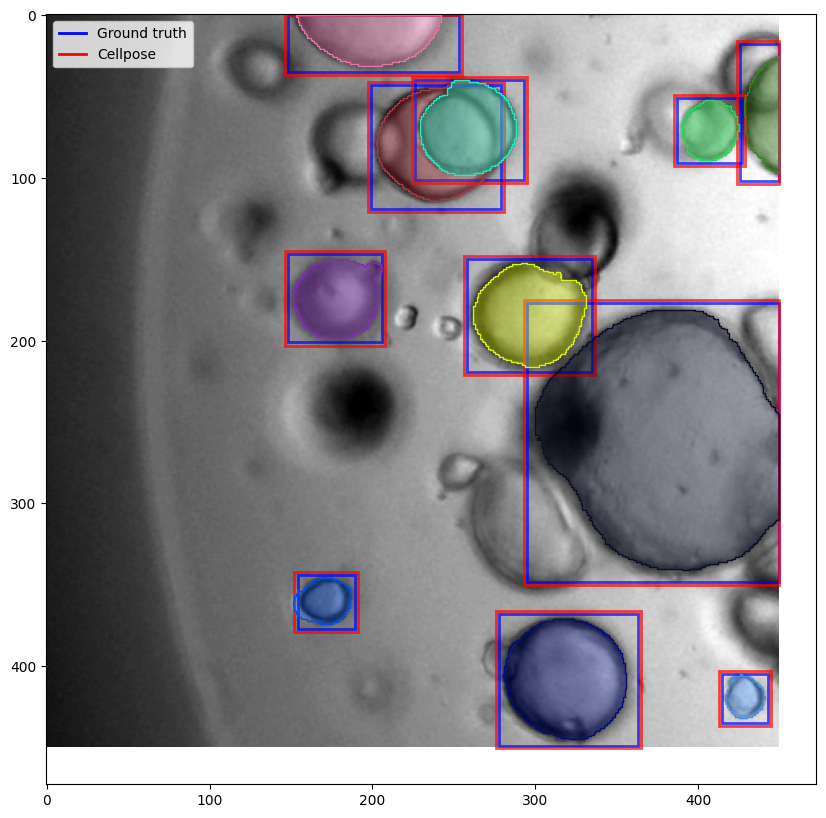

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes_cellpose, format='yxyx_px', ax=ax, show_image=False, color='red')

# Plot mask predictions
for i in range(boxes_cellpose.shape[0]):
    show_mask(contours_cellpose[i], ax, random_color=True)

# Define custom line handles
line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
line_c = mlines.Line2D([], [], color='red', label='Cellpose', linewidth=2)

# Add legend with custom handles
plt.legend(handles=[line_a, line_c])

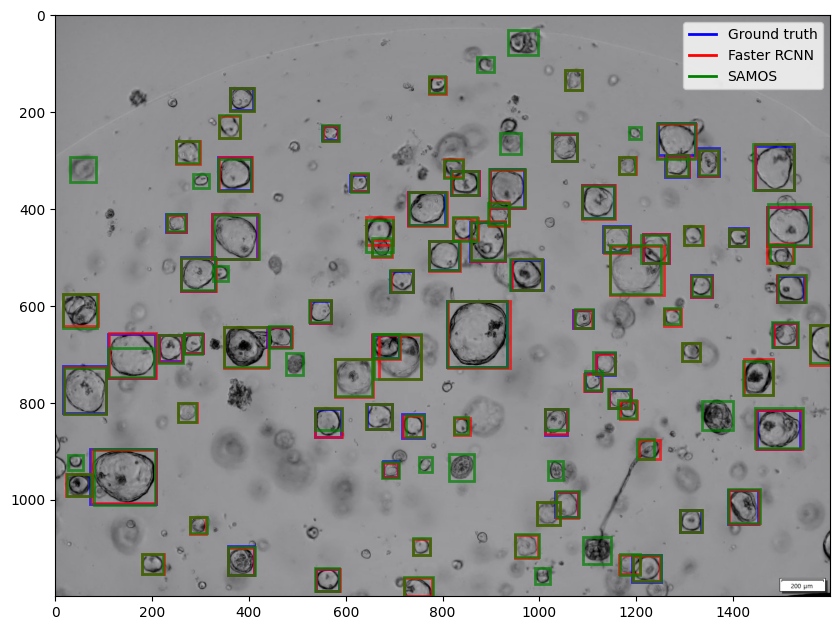

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes_rcnn, format='yxyx_px', ax=ax, show_image=False, color='red')
plot_boxes(im, boxes_samos, format='yxyx_px', ax=ax, show_image=False, color='green')

# Define custom line handles
line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
line_b = mlines.Line2D([], [], color='red', label='Faster RCNN', linewidth=2)
line_c = mlines.Line2D([], [], color='green', label='SAMOS', linewidth=2)

# Add legend with custom handles
plt.legend(handles=[line_a, line_b, line_c])

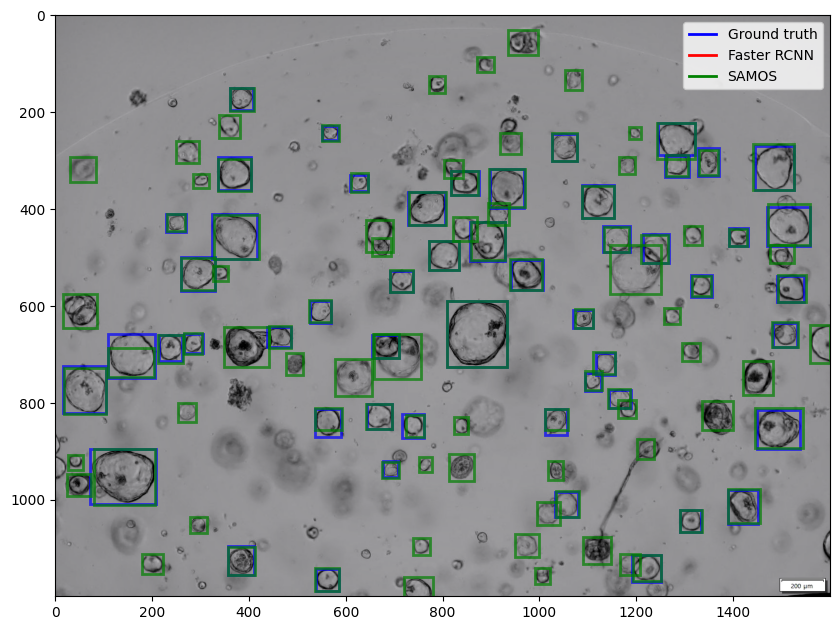

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
# plot_boxes(im, boxes_rcnn, format='yxyx_px', ax=ax, show_image=False, color='red')
plot_boxes(im, boxes_samos, format='yxyx_px', ax=ax, show_image=False, color='green')

# Define custom line handles
line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
line_b = mlines.Line2D([], [], color='red', label='Faster RCNN', linewidth=2)
line_c = mlines.Line2D([], [], color='green', label='SAMOS', linewidth=2)

# Add legend with custom handles
plt.legend(handles=[line_a, line_b, line_c])

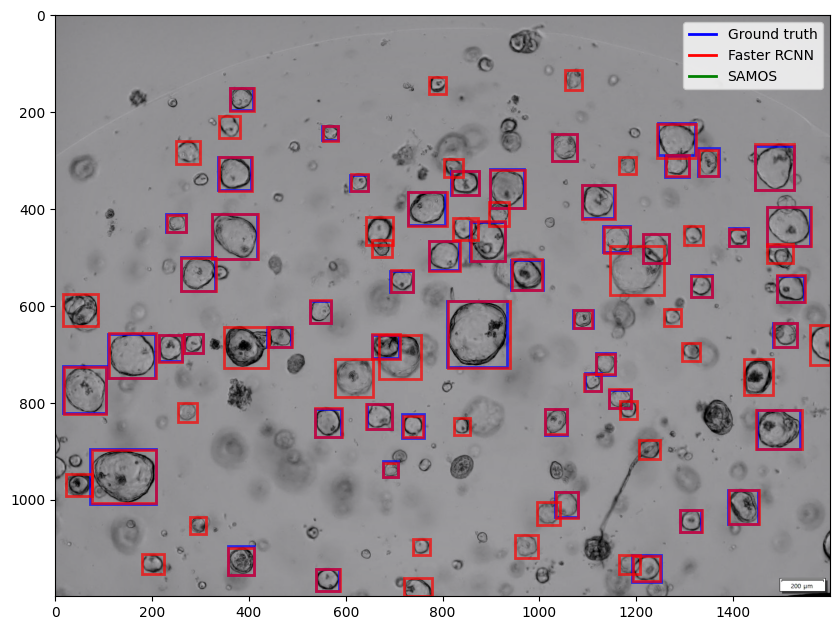

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes_rcnn, format='yxyx_px', ax=ax, show_image=False, color='red')
# plot_boxes(im, boxes_samos, format='yxyx_px', ax=ax, show_image=False, color='green')

# Define custom line handles
line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
line_b = mlines.Line2D([], [], color='red', label='Faster RCNN', linewidth=2)
line_c = mlines.Line2D([], [], color='green', label='SAMOS', linewidth=2)

# Add legend with custom handles
plt.legend(handles=[line_a, line_b, line_c])

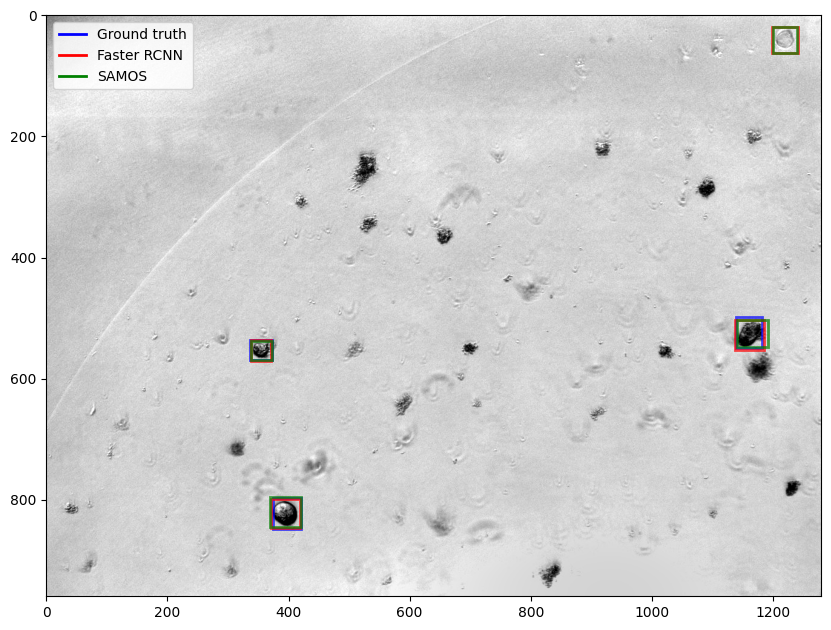

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes_rcnn, format='yxyx_px', ax=ax, show_image=False, color='red')
plot_boxes(im, boxes_samos, format='yxyx_px', ax=ax, show_image=False, color='green')

# Define custom line handles
line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
line_b = mlines.Line2D([], [], color='red', label='Faster RCNN', linewidth=2)
line_c = mlines.Line2D([], [], color='green', label='SAMOS', linewidth=2)

# Add legend with custom handles
plt.legend(handles=[line_a, line_b, line_c])

In [12]:
gt_masks = pp.convert_mask_to_binary(gt_mask)

In [17]:
# Segmentation metric implementation
iou_matrix = pp.compute_iou_matrix_segmentation_contours(contours_rcnn, gt_masks=gt_masks)
mAP_scores, haussdorf_scores, haussdorf_95_scores, masd_scores, assd_scores, pq_scores, iou_scores, dice_scores, f1_scores, prec_scores, recall_scores = pp.compute_metrics_segmentation_all(
    iou_matrix, [0.5, 0.75, 0.9], scores_rcnn, [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], gt_masks, contours_rcnn
)
mAP_scores, haussdorf_scores, haussdorf_95_scores

([0.9249772311573218, 0.8980636201770418, 0.14630684655199735],
 [4.087731369788056, 4.048613111738837, 3.9425111914758237],
 [3.3441004220818646, 3.304079551786715, 3.0675109268819343])

In [18]:
# Segmentation metric implementation
iou_matrix = pp.compute_iou_matrix_segmentation_contours(contours_samos, gt_masks=gt_masks)
mAP_scores, haussdorf_scores, haussdorf_95_scores, masd_scores, assd_scores, pq_scores, iou_scores, dice_scores, f1_scores, prec_scores, recall_scores = pp.compute_metrics_segmentation_all(
    iou_matrix, [0.5, 0.75, 0.9], scores_samos, [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], gt_masks, contours_samos
)
mAP_scores, haussdorf_scores, haussdorf_95_scores

([0.8243159170088088, 0.7488047301293386, 0.08847399758194362],
 [5.071001134159821, 4.4738411795262145, 3.9531785995137834],
 [4.261208691015424, 3.6906570386560418, 3.0142537208554363])

In [ ]:
# Own mAP implementation
iou_matrix = pp.compute_iou_matrix_detection(boxes_rcnn, gt_boxes)
mAP_scores, pq_scores, iou_scores, dice_scores, f1_scores, prec_scores, recall_scores = pp.compute_metrics_detection_all(
    iou_matrix, [0.5, 0.75, 0.9], scores_rcnn, [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
)
mAP_scores, f1_scores

([0.9170796485840113, 0.691717680388123, 0.06077839991920227],
 [0.8864864864864865,
  0.8864864864864865,
  0.8864864864864865,
  0.8864864864864865,
  0.8864864864864865,
  0.8756756756756756,
  0.8648648648648649,
  0.8540540540540539,
  0.8216216216216217])

In [52]:
# Own mAP implementation
iou_matrix = pp.compute_iou_matrix_detection(boxes_samos, gt_boxes)
mAP_scores, pq_scores, iou_scores, dice_scores, f1_scores, prec_scores, recall_scores = pp.compute_metrics_detection_all(
    iou_matrix, [0.5, 0.75, 0.9], scores_samos, [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
)
mAP_scores, f1_scores

([0.8832957466886817, 0.6040942830834048, 0.02039117769454848],
 [0.8307692307692307,
  0.8307692307692307,
  0.8307692307692307,
  0.8307692307692307,
  0.8307692307692307,
  0.8307692307692307,
  0.8307692307692307,
  0.8205128205128206,
  0.7794871794871795,
  0.7282051282051282])

In [40]:
import torchmetrics.detection

mAP_metric = torchmetrics.detection.MeanAveragePrecision(class_metrics=True, extended_summary=False, backend='faster_coco_eval',)

In [41]:
mAP_metric.update(preds=[{'boxes': torch.from_numpy(boxes_rcnn), 
                          'scores': torch.from_numpy(scores_rcnn), 
                          'labels': torch.zeros(scores_rcnn.shape, dtype=torch.int)}], 
                  target=[{'boxes': torch.from_numpy(gt_boxes), 
                           'labels': torch.zeros((gt_boxes.shape[0],), dtype=torch.int)}])
res = mAP_metric.compute()
mAP_metric.reset()
res

{'map': tensor(0.5954),
 'map_50': tensor(0.9159),
 'map_75': tensor(0.6911),
 'map_small': tensor(0.1576),
 'map_medium': tensor(0.6360),
 'map_large': tensor(-1.),
 'mar_1': tensor(0.0079),
 'mar_10': tensor(0.0865),
 'mar_100': tensor(0.6427),
 'mar_small': tensor(0.2125),
 'mar_medium': tensor(0.6852),
 'mar_large': tensor(-1.),
 'map_per_class': tensor(0.5954),
 'mar_100_per_class': tensor(0.6427),
 'classes': tensor(0, dtype=torch.int32)}

In [42]:
mAP_metric.update(preds=[{'boxes': torch.from_numpy(boxes_samos), 
                          'scores': torch.from_numpy(scores_samos), 
                          'labels': torch.zeros(scores_samos.shape, dtype=torch.int)}], 
                  target=[{'boxes': torch.from_numpy(gt_boxes), 
                           'labels': torch.zeros((gt_boxes.shape[0],), dtype=torch.int)}])
res = mAP_metric.compute()
mAP_metric.reset()
res

{'map': tensor(0.5183),
 'map_50': tensor(0.8333),
 'map_75': tensor(0.5852),
 'map_small': tensor(0.1545),
 'map_medium': tensor(0.5566),
 'map_large': tensor(-1.),
 'mar_1': tensor(0.0090),
 'mar_10': tensor(0.0843),
 'mar_100': tensor(0.5640),
 'mar_small': tensor(0.1500),
 'mar_medium': tensor(0.6049),
 'mar_large': tensor(-1.),
 'map_per_class': tensor(0.5183),
 'mar_100_per_class': tensor(0.5640),
 'classes': tensor(0, dtype=torch.int32)}

In [38]:
iou_matrix = np.array([
    [0.3, 0.5, 0.1, 0.74, 0.0, 0.0],
    [0.3, 0.5, 0.1, 0.04, 0.0, 0.0],
    [0.9, 0.5, 0.6, 0.04, 0.2, 0.0],
    [0.9, 0.5, 0.1, 0.04, 0.0, 0.02],
    [0.95, 0.6, 0.0, 0.04, 0.0, 0.1],
])
scores = np.array([0.08, 0.61, 0.33, 0.59, 0.97])

In [39]:
compute_metrics_detection_all(iou_matrix, [0.5, 0.75, 0.9], scores, thresholds=[0.1, 0.5, 0.9])

is_true_match [ True  True False  True  True]
ap 0.6
is_true_match [ True False False False False]
ap 0.16666666666666666
is_true_match [ True False False False False]
ap 0.16666666666666666
cost_matrix [[-0.95 -0.6  -0.   -0.04 -0.   -0.1 ]
 [-0.3  -0.5  -0.1  -0.04 -0.   -0.  ]
 [-0.9  -0.5  -0.1  -0.04 -0.   -0.02]
 [-0.9  -0.5  -0.6  -0.04 -0.2  -0.  ]]
row_ind, col_ind [0 1 2 3] [1 3 0 2]
matched_ious [0.6  0.04 0.9  0.6 ]
tp_ious [0.6 0.9 0.6]
tp 3
fp 2
fn 3
cost_matrix [[-0.95 -0.6  -0.   -0.04 -0.   -0.1 ]
 [-0.3  -0.5  -0.1  -0.04 -0.   -0.  ]
 [-0.9  -0.5  -0.1  -0.04 -0.   -0.02]]
row_ind, col_ind [0 1 2] [1 2 0]
matched_ious [0.6 0.1 0.9]
tp_ious [0.6 0.9]
tp 2
fp 3
fn 4
cost_matrix [[-0.95 -0.6  -0.   -0.04 -0.   -0.1 ]]
row_ind, col_ind [0] [0]
matched_ious [0.95]
tp_ious [0.95]
tp 1
fp 4
fn 5


([0.6, 0.16666666666666666, 0.16666666666666666],
 [0.0, 0.0, 0.0],
 [0.7000000000000001, 0.75, 0.95],
 [0.8157894736842105, 0.8486842105263157, 0.9743589743589743],
 [0.5454545454545454, 0.3636363636363636, 0.1818181818181818],
 [0.6, 0.4, 0.2],
 [0.5, 0.3333333333333333, 0.16666666666666666])

In [54]:
ds = dl.OrgaExtractor(split='test')

idx = 7
im, gt_mask, gt_boxes, im_path, im_ID = ds[idx]
# im, flatfield = dl.normalize(im)
print(im.shape)
im = (im / im.max() * 255).astype(np.uint8)
# im = np.stack((im, im, im), axis=2)
im = Image.fromarray(im).convert('RGB')
im = transforms(im)

(1200, 1600, 3)


In [18]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model_last = SSD.load_from_checkpoint('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_MultiOrg_train_macros_MultiOrg_train_normal_full_data_True_32_200/SSD_MultiOrg_train_macros_MultiOrg_train_normal_full_data_True_32_200-last_epoch=799-val_loss=17.95.ckpt')
model_best = SSD.load_from_checkpoint('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_MultiOrg_train_macros_MultiOrg_train_normal_full_data_True_32_200/SSD_MultiOrg_train_macros_MultiOrg_train_normal_full_data_True_32_200-best_epoch=49-val_loss=3.79.ckpt')

model_last.to(device)
model_best.to(device)

SSD(
  (model): SSD(
    (backbone): SSDFeatureExtractorVGG(
      (features): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
        (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (6): ReLU(inplace=True)
        (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (8): ReLU(inplace=True)
        (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (11): ReLU(inplace=True)
        (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (13): ReLU(inplace=True)
        (14): Conv2d(256, 256, kernel_size=(3, 3), stride

In [35]:
model_last.eval()
model_best.eval()
image = image.to(device)

with torch.inference_mode():
    output = model_last([image])
    # output = model_best([image])
output

{'pred_scores': tensor([1.0000, 0.9228, 0.6150, 0.2914], device='cuda:0'),
 'pred_boxes': tensor([[ 11.6078, 352.3887,  52.4829, 389.7431],
         [340.7168, 230.9342, 374.5117, 266.2815],
         [225.4310,  54.4283, 268.1337,  97.1424],
         [290.3765, 304.6036, 326.0614, 343.8856]], device='cuda:0')}

In [36]:
boxes = output['pred_boxes'].cpu().numpy()
# xyxy to yxyx
boxes = np.stack((boxes[:, 1], boxes[:, 0], boxes[:, 3], boxes[:, 2]), axis=1)
scores = output['pred_scores'].cpu().numpy()
boxes

array([[352.3887  ,  11.607782, 389.7431  ,  52.482933],
       [230.93425 , 340.71677 , 266.28152 , 374.51175 ],
       [ 54.42835 , 225.431   ,  97.14239 , 268.13367 ],
       [304.60358 , 290.3765  , 343.8856  , 326.0614  ]], dtype=float32)

In [37]:
filtered_boxes = boxes[scores > 0.5]

In [ ]:
im = image.cpu().numpy().transpose((1, 2, 0))

fig, ax = plt.subplots(1, 1, figsize=(12*4, 12*4), dpi=200)
# plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, filtered_boxes, format='yxyx_px', ax=ax, show_image=True, color='red')

## Full image patched predictions

In [3]:
# ssd_last = SSDPredictor('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_MultiOrg_train_macros_MultiOrg_train_normal_full_data_True_32_200/SSD_MultiOrg_train_macros_MultiOrg_train_normal_full_data_True_32_200-last_epoch=799-val_loss=17.95.ckpt')
# ssd_best = SSDPredictor('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_MultiOrg_train_macros_MultiOrg_train_normal_full_data_True_32_200/SSD_MultiOrg_train_macros_MultiOrg_train_normal_full_data_True_32_200-best_epoch=49-val_loss=3.79.ckpt')

/home/icb/lion.gleiter/projects/organoid_sam/segment-anything/segment-anything/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = 

In [3]:
ssd_full_best = SSDPredictor('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_full_data_09012025_True_32_200/SSD_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_full_data_09012025_True_32_200-best_epoch=274-val_loss=2.81.ckpt')
ssd_multiorg_best = SSDPredictor('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_MultiOrg_train_macros_MultiOrg_train_normal_multiorg_data_09012025_True_32_200/SSD_MultiOrg_train_macros_MultiOrg_train_normal_multiorg_data_09012025_True_32_200-best_epoch=174-val_loss=3.30.ckpt')

/home/icb/lion.gleiter/projects/organoid_sam/segment-anything/segment-anything/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = 

In [3]:
ssd_full_last = SSDPredictor('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_full_data_09012025_True_32_200/SSD_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_full_data_09012025_True_32_200-last_epoch=799-val_loss=2.85.ckpt')
# ssd_multiorg_last = SSDPredictor('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_MultiOrg_train_macros_MultiOrg_train_normal_multiorg_data_09012025_True_32_200/SSD_MultiOrg_train_macros_MultiOrg_train_normal_multiorg_data_09012025_True_32_200-last_epoch=799-val_loss=3.44.ckpt')

ssd_multiorg_last_multiscale = SSDPredictor('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_MultiOrg_train_macros_MultiOrg_train_normal_multiorg_with_090_overlap_True_32_200/SSD_MultiOrg_train_macros_MultiOrg_train_normal_multiorg_with_090_overlap_True_32_200-last_epoch=799-val_loss=3.13.ckpt')


/home/icb/lion.gleiter/projects/organoid_sam/segment-anything/segment-anything/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = 

In [4]:
ds = dl.MultiOrg(split='test_normal')

idx = 0
im, gt_mask, gt_boxes, im_path, im_ID = ds[idx]
# im, flatfield = dl.normalize(im)
im = (im / im.max() * 255).astype(np.uint8)
im = np.stack((im, im, im), axis=2)

In [5]:
im.shape

(6240, 6940, 3)

In [ ]:
# contours, boxes, scores = ssd_full_best.forward(im, patch_size=(350, 1024), predict_masks=True, min_diameter=30/1.29)
contours, boxes, scores = ssd_full_best.forward(im, patch_size=3000, predict_masks=True, min_diameter=30/1.29)

predict_boxes image.shape (3000, 3000, 3)
transformed_boxes.shape torch.Size([167, 4])
patch 0
predict_boxes image.shape (3000, 3000, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 1
predict_boxes image.shape (3000, 3000, 3)
transformed_boxes.shape torch.Size([169, 4])
patch 2
predict_boxes image.shape (3000, 3000, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 3
predict_boxes image.shape (3000, 3000, 3)
transformed_boxes.shape torch.Size([166, 4])
patch 4
predict_boxes image.shape (3000, 3000, 3)
transformed_boxes.shape torch.Size([162, 4])
patch 5
predict_boxes image.shape (3000, 3000, 3)
transformed_boxes.shape torch.Size([169, 4])
patch 6
predict_boxes image.shape (3000, 3000, 3)
transformed_boxes.shape torch.Size([164, 4])
patch 7
predict_boxes image.shape (3000, 3000, 3)
transformed_boxes.shape torch.Size([162, 4])


In [15]:
contours, boxes, scores = ssd_full_best.set_threshold(0.3, predict_masks=True)
print(scores)

[1.         0.99999988 0.99999988 0.99999976 0.99999797 0.99999607
 0.99999487 0.99999428 0.99999225 0.99997783 0.99996412 0.99996042
 0.99994969 0.99985611 0.99985099 0.99980336 0.99969494 0.99932122
 0.99926668 0.99855667 0.99846625 0.99811172 0.99751353 0.99720436
 0.99601609 0.99551219 0.99523783 0.99205011 0.98083329 0.97840607
 0.97013342 0.9689396  0.95700544 0.9349826  0.93196398 0.9223243
 0.91390014 0.86110312 0.84573722 0.83187973 0.82218403 0.81311071
 0.81228423 0.79938006 0.7842108  0.77655768 0.74996358 0.74563563
 0.72631687 0.63502741 0.6205768  0.61465025 0.57966256 0.579436
 0.54960358 0.54600894 0.53404206 0.50812072 0.49403211 0.49240822
 0.48420301 0.47576657 0.46808451 0.46325746 0.44200799 0.43589824
 0.43154091 0.38332582 0.38126099 0.3779268  0.37292609 0.3593221
 0.35728246 0.35703686 0.35399228 0.35344833 0.31938463 0.30854324
 0.30770457 0.30015725]


In [ ]:
boxes.shape, gt_boxes.shape

((80, 4), (176, 4))

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12*2, 12*2), dpi=200)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes, format='yxyx_px', ax=ax, show_image=False, color='red')

In [16]:
contours, boxes, scores = ssd_multiorg_best.forward(im, patch_size=(350, 1024), predict_masks=True, min_diameter=30/1.29)

predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])


patch 0
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 1
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 2
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 3
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 4
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 5
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 6
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 7
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 8
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 9
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 10
predict_boxes image.shape (350, 350, 3)
transformed_boxes.sha

In [23]:
contours, boxes, scores = ssd_multiorg_best.set_threshold(0.2, predict_masks=True)

In [24]:
boxes.shape, gt_boxes.shape

((230, 4), (176, 4))

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12*2, 12*2), dpi=200)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes, format='yxyx_px', ax=ax, show_image=False, color='red')

### last

In [6]:
contours, boxes, scores = ssd_full_last.forward(im, patch_size=(350, 1024, 2048, 4096), predict_masks=True, min_diameter=30/1.29)

predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 0
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 1
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 2
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 3
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 4
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 5
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 6
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 7
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 8
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 9
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.

In [7]:
contours, boxes, scores = ssd_full_last.set_threshold(0.3, predict_masks=True)
print(scores)

[1.         1.         1.         1.         1.         1.
 1.         1.         1.         0.99999988 0.99999988 0.99999964
 0.9999994  0.99999917 0.99999917 0.99999857 0.99999487 0.99999321
 0.99999261 0.99999201 0.99998224 0.9999609  0.99995029 0.99994707
 0.99994671 0.99994195 0.99994135 0.99992633 0.99990666 0.99990499
 0.99977595 0.9996525  0.99951732 0.99941826 0.99895334 0.99878985
 0.99859864 0.99763405 0.99684542 0.99591941 0.99358046 0.99348676
 0.99337924 0.99295747 0.99272352 0.99021405 0.98803467 0.9864369
 0.98623788 0.98292589 0.97742772 0.97482163 0.9736163  0.97074878
 0.96758491 0.96671093 0.96151733 0.95411026 0.94062769 0.93814886
 0.92760217 0.92262584 0.91377598 0.90502715 0.88616854 0.86707819
 0.85889691 0.82371336 0.81339896 0.80852675 0.79257989 0.77879989
 0.77093238 0.76466757 0.7629419  0.73777378 0.72944111 0.71849954
 0.70655751 0.69590759 0.68435884 0.6667307  0.64917505 0.6428057
 0.64250422 0.64229578 0.63909179 0.63600987 0.61843455 0.6003738
 0.589

In [8]:
boxes.shape, gt_boxes.shape

((138, 4), (176, 4))

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12*2, 12*2), dpi=200)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes, format='yxyx_px', ax=ax, show_image=False, color='red')

In [11]:
contours, boxes, scores = ssd_multiorg_last.forward(im, patch_size=(350, 1024), predict_masks=True, min_diameter=30/1.29)

predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 0
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])


patch 1
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 2
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 3
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 4
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 5
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 6
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 7
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 8
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 9
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 10
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 11
predict_boxes image.shape (350, 350, 3)
transformed_boxes.sh

In [21]:
contours, boxes, scores = ssd_multiorg_last.set_threshold(0.5, predict_masks=True)

In [22]:
boxes.shape, gt_boxes.shape

((85, 4), (176, 4))

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12*2, 12*2), dpi=200)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes, format='yxyx_px', ax=ax, show_image=False, color='red')

Multiscale training with > 0.9 overlap

In [20]:
# contours, boxes, scores = ssd_full_best.forward(im, patch_size=(350, 1024), predict_masks=True, min_diameter=30/1.29)
contours, boxes, scores = ssd_multiorg_last_multiscale.forward(im, patch_size=(512, 2048), predict_masks=True, min_diameter=30/1.29)

predict_boxes image.shape (512, 512, 3)


transformed_boxes.shape torch.Size([102, 4])
patch 0
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 1
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 2
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 3
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 4
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 5
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 6
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 7
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 8
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 9
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 10
predict_boxes im

In [21]:
contours, boxes, scores = ssd_multiorg_last_multiscale.set_threshold(0.2, predict_masks=True)
print(scores)

[0.99993074 0.99975067 0.9996599  0.99962449 0.99954283 0.99952006
 0.99948055 0.99926883 0.99920779 0.99900407 0.99876714 0.99819404
 0.99698323 0.99663842 0.99622846 0.99473298 0.99427718 0.99025434
 0.98884064 0.98818249 0.98783827 0.98548156 0.98415947 0.9800337
 0.97540534 0.97466362 0.97440058 0.97069442 0.96738005 0.96686065
 0.96209109 0.95618409 0.94792861 0.94407165 0.94340944 0.93130118
 0.9235636  0.91748995 0.91351187 0.90499991 0.90070653 0.89924455
 0.89075124 0.86891329 0.86695921 0.84105492 0.83506143 0.82969105
 0.82334405 0.82194817 0.80887204 0.74606252 0.74224138 0.72918588
 0.72456622 0.72400069 0.71979022 0.71829969 0.70477057 0.69807905
 0.69752133 0.69025379 0.67531663 0.6719588  0.64987749 0.63869476
 0.62774575 0.59901369 0.57982659 0.57726473 0.55560368 0.54559636
 0.5354588  0.51658624 0.51557213 0.51289439 0.5089218  0.49978268
 0.49553049 0.47711989 0.46545178 0.43933541 0.42228264 0.41938457
 0.40887669 0.40780407 0.39914876 0.39763007 0.38808149 0.38662

In [22]:
boxes.shape, gt_boxes.shape

((130, 4), (176, 4))

In [ ]:
# (512, 2048)
fig, ax = plt.subplots(1, 1, figsize=(12*2, 12*2), dpi=200)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes, format='yxyx_px', ax=ax, show_image=False, color='red')

In [ ]:
# (512, 1024, 2048, 4096)
fig, ax = plt.subplots(1, 1, figsize=(12*2, 12*2), dpi=200)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes, format='yxyx_px', ax=ax, show_image=False, color='red')

In [24]:
!python --version

Python 3.11.5


In [29]:
import sys
sys.version_info

sys.version_info(major=3, minor=11, micro=5, releaselevel='final', serial=0)